In [1]:
import tensorflow as tf
import tensorflow_probability as tfp 
import tensorflow_addons as tfa
from tensorflow import keras
from keras import mixed_precision
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
import numpy as np
import pandas as pd
import functions
import matplotlib.pyplot as plt

In [2]:
# 1. TensorFlow version
print("TF version:", tf.__version__)

# 2. Is this a GPU build?
print("Built with CUDA:", tf.test.is_built_with_cuda())

# 3. Any GPUs visible?
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))

# 4. Full build_info dict
info = tf.sysconfig.get_build_info()
print("Build info keys:", info.keys())
print(info)
mixed_precision.set_global_policy("mixed_float16")
tf.config.list_physical_devices()

TF version: 2.10.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Build info keys: odict_keys(['cpu_compiler', 'cuda_compute_capabilities', 'cuda_version', 'cudart_dll_name', 'cudnn_dll_name', 'cudnn_version', 'is_cuda_build', 'is_rocm_build', 'is_tensorrt_build', 'msvcp_dll_names', 'nvcuda_dll_name'])
OrderedDict([('cpu_compiler', 'C:/Program Files (x86)/Microsoft Visual Studio/2019/Community/VC/Tools/MSVC/14.29.30133/bin/HostX64/x64/cl.exe'), ('cuda_compute_capabilities', ['sm_35', 'sm_50', 'sm_60', 'sm_70', 'sm_75', 'compute_80']), ('cuda_version', '64_112'), ('cudart_dll_name', 'cudart64_112.dll'), ('cudnn_dll_name', 'cudnn64_8.dll'), ('cudnn_version', '64_8'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', False), ('msvcp_dll_names', 'msvcp140.dll,msvcp140_1.dll'), ('nvcuda_dll_name', 'nvcuda.dll')])
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run qui

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
class stacked_lstm_encoder(keras.layers.Layer):
    def __init__(self, vec_size = 10, nominals_embeddings={}, **kwargs):
        super().__init__(**kwargs)
        self.latent_output_shape = vec_size
        self.lstm1 = keras.layers.LSTM(64, return_sequences=True)
        self.lstm2 = keras.layers.LSTM(self.latent_output_shape, return_sequences=False)
        self.data_type = 'mixed' if nominals_embeddings else 'basic'
        self.embeddings = {}
        for col, (orig_dimension, embed_dimension) in nominals_embeddings.items():
            self.embeddings[col] = keras.layers.Embedding(input_dim=orig_dimension+1, output_dim=embed_dimension)

    def build(self, input_shape):
        self.n_features = input_shape[-1]
        return super().build(input_shape)
    
    def call(self, inputs, training=False):
        # (batch [number of windows], windows length, features_dim)
        if self.data_type != 'basic':
            blocks = []
            for col in range(self.n_features):
                if col in self.embeddings:
                    index = tf.cast(inputs[..., col], tf.int32)
                    emb = self.embeddings[col](index)
                    blocks.append(emb)
                else:
                    blocks.append(inputs[..., col:col+1])
            inputs = tf.concat(blocks, axis=2)

        hidden = self.lstm1(inputs, training=training)
        latent_reps = self.lstm2(hidden, training=training)
        return latent_reps

In [4]:
class lstm_decoder(keras.layers.Layer):
    def __init__(self, dimension, nominals_embeddings={}, **kwargs):
        super().__init__(**kwargs)
        self.window_length = dimension[0]
        self.feature_dim = dimension[1]
        
        self.outs = {}
        self.nominals_embeddings = nominals_embeddings
        
        if self.nominals_embeddings:
            self.data_type = 'mixed'
            for col in range(self.feature_dim):
                if col in nominals_embeddings:
                    orig_dim, _ = nominals_embeddings[col]
                    self.outs[col] = keras.layers.TimeDistributed(
                        keras.layers.Dense(orig_dim+1, activation='softmax')
                    )
                else:
                    self.outs[col] = keras.layers.TimeDistributed(
                        keras.layers.Dense(self.feature_dim, activation='relu')
                    )
        else:
            self.data_type = 'basic'
            #**************
            self.lstm_cell = keras.layers.LSTMCell(64)
            self.out = keras.layers.Dense(self.feature_dim, activation='relu')
            #**************
            
        self.initial_h = keras.layers.Dense(64, activation='tanh')
        self.initial_c = keras.layers.Dense(64, activation='tanh')

    
    def call(self, latent_reps, training=False):
        # initial states
        h = self.initial_h(latent_reps, training=training)
        c = self.initial_c(latent_reps, training=training)
        states = [h, c]

        # “start” input: zeros of shape (batch, feature_dim)
        prev_y = tf.zeros((tf.shape(latent_reps)[0], self.feature_dim), dtype=latent_reps.dtype)
        outputs = []

        for t in range(self.window_length):
            # run ONE step of the cell: input must be 2D, (batch, feature_dim)
            ts_out, states = self.lstm_cell(prev_y, states=states, training=training)
            y_t = self.out(ts_out, training=training)  # (batch, feature_dim)
            outputs.append(y_t)
            prev_y = y_t

        # stack all predictions → (batch, window_length, feature_dim)
        return tf.stack(outputs, axis=1)

In [5]:
class LSTMAE_CBCL:
    def __init__(self, dimensions, latent_vec_size=10, weights=[0.2, 2, 2], dataset_type='basic', nominals_embeddings={}, num_clusters=5):
        self.encoder = stacked_lstm_encoder(latent_vec_size, nominals_embeddings=nominals_embeddings)
        self.decoder = lstm_decoder(dimensions, nominals_embeddings=nominals_embeddings)
        self.num_clusters = num_clusters
        self.alpha, self.lmda, self.gamma = weights
        self.kmeans = MiniBatchKMeans(num_clusters, init='random')
        self.centroids = None
        self.mse = keras.losses.MeanSquaredError()
        self.optimizer = keras.optimizers.Adam(learning_rate=0.001)
    
    @tf.function    
    def pretrain(self, dataset, epochs = 10, batch_size=1024):
        dataset = dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
        for epoch in range(epochs):
            for step, batch in enumerate(dataset):
                with tf.GradientTape() as tape:
                    latent_repr = self.encoder(batch, training=True)
                    reconstructions = self.decoder(latent_repr, training=True)
                    loss_recons = self.mse(batch, reconstructions)
                lstm_weights = self.encoder.trainable_weights + self.decoder.trainable_weights
                ae_gradients = tape.gradient(loss_recons, lstm_weights)
                self.optimizer.apply_gradients(zip(ae_gradients, lstm_weights))
    
    @tf.function
    def train_step(self, batch, assignment_batch):
        N = tf.shape(batch)[0] // 2
        X, X_assignments = batch[:N], assignment_batch[:N]
        X_prime, X_prime_assignments = batch[N:2*N], assignment_batch[N:2*N]

        
        with tf.GradientTape() as tape:
            Z = self.encoder(X, training=True) 
            X_reconstructed = self.decoder(Z, training=True) 
            Z_prime = self.encoder(X_prime, training=True) 
            X_prime_reconstructed = self.decoder(Z_prime, training=True) 
            
            loss_X = tf.reduce_mean(self.mse(X, X_reconstructed))
            loss_X_prime = tf.reduce_mean(self.mse(X_prime, X_prime_reconstructed)) 
            loss_recons = tf.cast(0.5*(loss_X+loss_X_prime), dtype=tf.float32)
            
            # Pair within same cluster gets label 1
            y_pair_labels = tf.cast(tf.equal(X_assignments, X_prime_assignments), tf.float16)
            l2_dists = tf.norm(Z-Z_prime, axis=1)
            pos_pairs = y_pair_labels * tf.square(l2_dists)
            neg_pairs = (1-y_pair_labels)*tf.square(tf.maximum(self.lmda-l2_dists, 0.0))
            contrast_loss = tf.cast(tf.reduce_mean(pos_pairs + neg_pairs), dtype=tf.float32)
            
            # Recall L2-distance between 2 vectors = ||Ci-Cj||^2 = ||Ci||^2 + ||Cj||^2 - 2Ci.T * Cj (squared binomial expansion (a-b)^2 = a^2 - 2ab + b^2 )
            # Produces the ab component (a dot b)
            dot_products = tf.matmul(self.centroids, self.centroids, transpose_b=True)
            # Produces sum of squared centroids components, keepdims needed to broadcast later
            squared_sums = tf.reduce_sum(tf.square(self.centroids), axis=1, keepdims=True)
            # Compute l2-distances between centroids
            centroid_distances = tf.sqrt(tf.maximum(squared_sums + tf.transpose(squared_sums) - 2 * dot_products, 1e-12))
            mask = tf.logical_not(tf.eye(self.num_clusters, dtype=tf.bool))
            masked_centroid_diff = tf.boolean_mask(centroid_distances, mask)
            avg_centroid_diff = tf.reduce_mean(masked_centroid_diff)
            
            #avg_centroid_diff = tf.reduce_mean(tf.norm(self.centroids[0]-self.centroids[1]))
            centroid_loss = tf.cast(tf.square(tf.maximum(self.gamma-avg_centroid_diff, 0.0)), dtype=tf.float32)
            
            total_loss = (1-self.alpha)*loss_recons + self.alpha*(contrast_loss + centroid_loss)
        model_weights = self.encoder.trainable_weights + self.decoder.trainable_weights
        gradient = tape.gradient(total_loss, model_weights)
        self.optimizer.apply_gradients(zip(gradient, model_weights))
                
                
    def train(self, dataset:tf.data.Dataset, batch_size=1024):
        '''
        Consider doing a big kmeans clustering on full dataset, then run the train_step based on batch
        '''
            
        batches = dataset.shuffle(dataset.cardinality().numpy(), reshuffle_each_iteration=True).batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)        
        for batch in batches:
            latents = self.encode(batch).numpy().astype(np.float64)
            if self.centroids is None:
                clusters = self.kmeans.partial_fit(latents)
                self.centroids = clusters.cluster_centers_
            else:
                clusters = self.kmeans.partial_fit(latents)
                self.centroids = 0.5*(self.centroids + clusters.cluster_centers_)
                self.kmeans.cluster_centers_ = self.centroids
                
            assignments = tf.constant(self.kmeans.predict(latents), dtype=tf.int32)
            self.train_step(batch, assignments)
    
    def final_reclustering(self, dataset):
        batches = dataset.shuffle(dataset.cardinality()).batch(1024).cache().prefetch(tf.data.AUTOTUNE)      
        label_counts = np.zeros(self.num_clusters, dtype=int)
        for batch in batches:
            latents = self.encode(batch).numpy().astype(np.float64)
            cluster_labels = self.kmeans.predict(latents)     
            for label in cluster_labels:
                label_counts[label] += 1
        self.normal_cluster = int(label_counts.argmax())
    
    @tf.function
    def ae_reconstruct(self, batch):
        Z = self.encoder(batch, training=False)
        batch_reconstructed = self.decoder(Z)
        return batch_reconstructed
    
    @tf.function
    def encode(self, batch):
        return self.encoder(batch, training=False)
    
    @tf.function
    def decode(self, batch):
        return self.decoder(batch, training=False)
    
    def predict_proba(self, batch):
        """
        Assuming one cluster is normal, compute the distance of latent rep of data to the normal cluster 
        Higher distance denotes greater probability of being abnormal 
        """
        Z = self.encode(batch).numpy().astype(np.float64)
        distances = self.kmeans.transform(Z)
        anom_scores = distances[:, self.normal_cluster]
        return anom_scores
                

In [6]:
def visualize(mse, percentiles=[]):
    plt.figure(figsize=(20, 5))
    if mse.numpy().flatten().shape[0] > 50000:
        plt.plot(mse[::300], marker='o', label='Anomaly Score', markersize=1)
    else: 
        plt.plot(mse, marker='o', label='Anomaly Score', markersize=1)
    for p in percentiles:
        plt.axhline(y=np.percentile(mse, p), color='r', linestyle='--', label='Threshold')
    plt.title("Anomaly Score per Sample")
    plt.xlabel("Sample Index")
    plt.ylabel("Anomaly Score")
    plt.legend()
    plt.show()

In [7]:
class framework:
    def __init__(self, weights = [0.2, 2, 2]):
        self.weights = weights
    
    def build(self, X_train, frame_length=5, latent_vec_size=10, num_clusters=2):
        self.frame_length = frame_length
        self.timewindows = tf.signal.frame(tf.convert_to_tensor(X_train, dtype=tf.float32), frame_length=frame_length, frame_step=1, axis=0)
        self.dataset = tf.data.Dataset.from_tensor_slices(self.timewindows).batch(1024).cache().prefetch(tf.data.AUTOTUNE)
        self.latent_size = latent_vec_size
        self.model = LSTMAE_CBCL(dimensions=[frame_length, X_train.shape[1]], latent_vec_size=latent_vec_size, weights = self.weights, num_clusters=num_clusters)
    
    def run_only_ae(self, epochs, batch_size = 1024):
        training_set = tf.data.Dataset.from_tensor_slices(self.timewindows)
        ############################# TODO contrastive learning
        curr_best = float('inf')
        delta_error = 1e-4
        spike_threshold = 0.05
        wait, limit = 0, 3
        for epoch in range(epochs):
            print(f"Epoch {epoch+1}/{epochs}")
            self.model.pretrain(training_set, epochs=1, batch_size=batch_size)
            reconstructed = []
            for _, batch in enumerate(self.dataset):
                latents = self.model.encode(batch)
                reconstructed.append(self.model.decode(latents))
            X_reconstructed = tf.cast(tf.concat(reconstructed, axis=0), dtype=tf.float32)
            errors = tf.reduce_mean(tf.math.squared_difference(tf.cast(self.timewindows, dtype=tf.float32), X_reconstructed), axis=[1,2])
            mean_error = tf.reduce_mean(errors).numpy()
            print(f"\t\t Previous Loss {curr_best:.4f}, Epoch loss: {mean_error:.4f}, Delta loss: {(curr_best - mean_error):.4f}")
            
            #********* Early-stop if no significant improvements between epochs
            if (curr_best - mean_error > delta_error):
                curr_best = mean_error
                wait = 0
            else:
                wait +=1 
                if (mean_error-curr_best)/curr_best > spike_threshold:
                    break
                if wait > limit:
                    break
            #############################
        min_error = tf.reduce_min(errors)
        max_error = tf.reduce_max(errors)
        thres_50 = tfp.stats.percentile(errors, 50)
        self.anom_threshold = tfp.stats.percentile(errors, 99)
        print(f"\n max_err: {max_error}, min_err: {min_error}")
        visualize(errors, [95])
            
    def run(self, epochs=50, batch_size = 1024):
        training_set = tf.data.Dataset.from_tensor_slices(self.timewindows)
        training_set = training_set.shuffle(training_set.cardinality())
        ############################# TODO contrastive learning
        curr_best = float('inf')
        delta_error = 1e-4
        spike_threshold = 0.05
        wait, limit = 0, 3
        for epoch in range(epochs):
            print(f"Epoch {epoch+1}/{epochs}")
            self.model.train(training_set, batch_size=batch_size)
            reconstructed = []
            for _, batch in enumerate(self.dataset):
                latents = self.model.encode(batch)
                reconstructed.append(self.model.decode(latents))
            X_reconstructed = tf.cast(tf.concat(reconstructed, axis=0), dtype=tf.float32)
            #errors = tf.norm(tf.cast(self.timewindows, dtype=tf.float32) - X_reconstructed, ord='euclidean', axis=[1,2])
            errors = tf.reduce_mean(tf.math.squared_difference(tf.cast(self.timewindows, dtype=tf.float32), X_reconstructed), axis=[1,2])
            mean_error = tf.reduce_mean(errors).numpy()
            print(f"\t\t Previous Loss {curr_best:.4f}, Epoch loss: {mean_error:.4f}, Delta loss: {(curr_best - mean_error):.4f}")
            
            #********* Early-stop if no significant improvements between epochs
            if (curr_best - mean_error > delta_error):
                curr_best = mean_error
                wait = 0
            else:
                wait +=1 
                if (mean_error-curr_best)/curr_best > spike_threshold:
                    break
                if wait > limit:
                    break
            #############################
        min_error = tf.reduce_min(errors)
        max_error = tf.reduce_max(errors)
        thres_50 = tfp.stats.percentile(errors, 50)
        self.anom_threshold = tfp.stats.percentile(errors, 99)
        print(f"\n max_err: {max_error}, min_err: {min_error}")
        visualize(errors, [95])
        self.model.final_reclustering(training_set)
        
    
    def test_using_reconstruction(self, X_test, y_test, predict_proba=False, use_maxpooling=False):
        test_windows = tf.signal.frame(tf.convert_to_tensor(X_test, dtype=tf.float32), frame_length=self.frame_length, frame_step=1, axis=0)
        dataset = tf.data.Dataset.from_tensor_slices(test_windows).batch(2048).cache().prefetch(tf.data.AUTOTUNE)
        windows_mse = []
        for _, batch in enumerate(dataset):
            reconstructed = tf.cast(self.model.ae_reconstruct(batch), tf.float32)
            windows_mse.append(tf.reduce_mean(tf.math.squared_difference(batch, reconstructed), axis=[1,2]))
        windows_mse = tf.cast(tf.concat(windows_mse, axis=0),tf.float32)
        
        y_scores = tf.Variable(tf.zeros_like(y_test, dtype=tf.float32))
        y_counts = tf.Variable(tf.zeros_like(y_test, dtype=tf.float32))
        if use_maxpooling:
            for i, win_mse in enumerate(windows_mse):
                start_t = i
                end_t = i+self.frame_length
                y_scores[start_t: end_t].assign(tf.maximum(y_scores[start_t:end_t], win_mse))
        else:
            for i, win_mse in enumerate(windows_mse):
                idx_t = tf.range(i, i+self.frame_length, dtype=tf.int32)
                y_scores.scatter_add(tf.IndexedSlices(win_mse, idx_t))
                y_counts.scatter_add(tf.IndexedSlices(tf.ones_like(win_mse), idx_t))
            
            y_scores = y_scores / y_counts
        
        y_preds = tf.cast(y_scores > self.anom_threshold, tf.int32)
        functions.display_metrics(y_preds, y_test)
        functions.visualize_metrics(y_scores, y_test)
        
        if predict_proba: return y_scores
        
    def test_using_clustering(self, X_test, y_test, predict_proba=False, use_maxpooling=False):
        test_windows = tf.signal.frame(tf.convert_to_tensor(X_test, dtype=tf.float32), frame_length=self.frame_length, frame_step=1, axis=0)
        dataset = tf.data.Dataset.from_tensor_slices(test_windows).batch(2048).cache().prefetch(tf.data.AUTOTUNE)
        windows_dist = []
        for _, batch in enumerate(dataset):
            windows_dist.append(self.model.predict_proba(batch))
        windows_dist = tf.cast(tf.concat(windows_dist, axis=0),tf.float32)
        
        y_scores = tf.Variable(tf.zeros_like(y_test, dtype=tf.float32))
        y_counts = tf.Variable(tf.zeros_like(y_test, dtype=tf.float32))          
        if use_maxpooling:
            for i, wind_dist in enumerate(windows_dist):
                start_t = i
                end_t = i+self.frame_length
                y_scores[start_t: end_t].assign(tf.maximum(y_scores[start_t:end_t], wind_dist))
        else:
            for i, wind_dist in enumerate(windows_dist):
                idx_t = tf.range(i, i+self.frame_length, dtype=tf.int32)
                y_scores.scatter_add(tf.IndexedSlices(wind_dist, idx_t))
                y_counts.scatter_add(tf.IndexedSlices(tf.ones_like(wind_dist), idx_t))
            
            y_scores = y_scores / y_counts
        
        y_preds = tf.cast(y_scores > self.anom_threshold, tf.int32)
        functions.display_metrics(y_preds, y_test)
        functions.visualize_metrics(y_scores, y_test)
        
        if predict_proba: return y_scores

# TODO :
1. Visualize clustering results 
2. Compute grid-search for parameters (including gamma + batch sizing)
3. Frame length
4. Verify predictions framework 

Ideally: want 2 defined clusters for normal / abnormal

Test both (X, X') formation:
- Split batch into 2, map 1:1
- For each batch, form every pairing (exhaustive)
	Test: Train on all pair vs selected pair

~~Average pooling instead of max pooling~~:  
-   Trading higher precision for lower recalls

Inference: 
1. Threshold based on top anomaly percentile
2. Thresholding based on individual clustering reconstruction threshold.

In [8]:
model_weights = [0.2, 2, 1]
global_batch = 256
training_epochs = 30 

<span style='color:red; font-size:60px'> Machine-1-1 </span>

In [9]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(1,1)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0032, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0032, Epoch loss: 0.0018, Delta loss: 0.0014
Epoch 3/30
		 Previous Loss 0.0018, Epoch loss: 0.0016, Delta loss: 0.0002
Epoch 4/30
		 Previous Loss 0.0016, Epoch loss: 0.0015, Delta loss: 0.0001
Epoch 5/30
		 Previous Loss 0.0015, Epoch loss: 0.0014, Delta loss: 0.0000
Epoch 6/30
		 Previous Loss 0.0015, Epoch loss: 0.0014, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0015, Epoch loss: 0.0014, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0014, Epoch loss: 0.0014, Delta loss: -0.0000
Epoch 9/30
		 Previous Loss 0.0014, Epoch loss: 0.0013, Delta loss: 0.0000
Epoch 10/30
		 Previous Loss 0.0014, Epoch loss: 0.0013, Delta loss: 0.0000
Epoch 11/30
		 Previous Loss 0.0014, Epoch loss: 0.0013, Delta loss: 0.0000

 max_err: 0.02670970931649208, min_err: 0.0004329353105276823


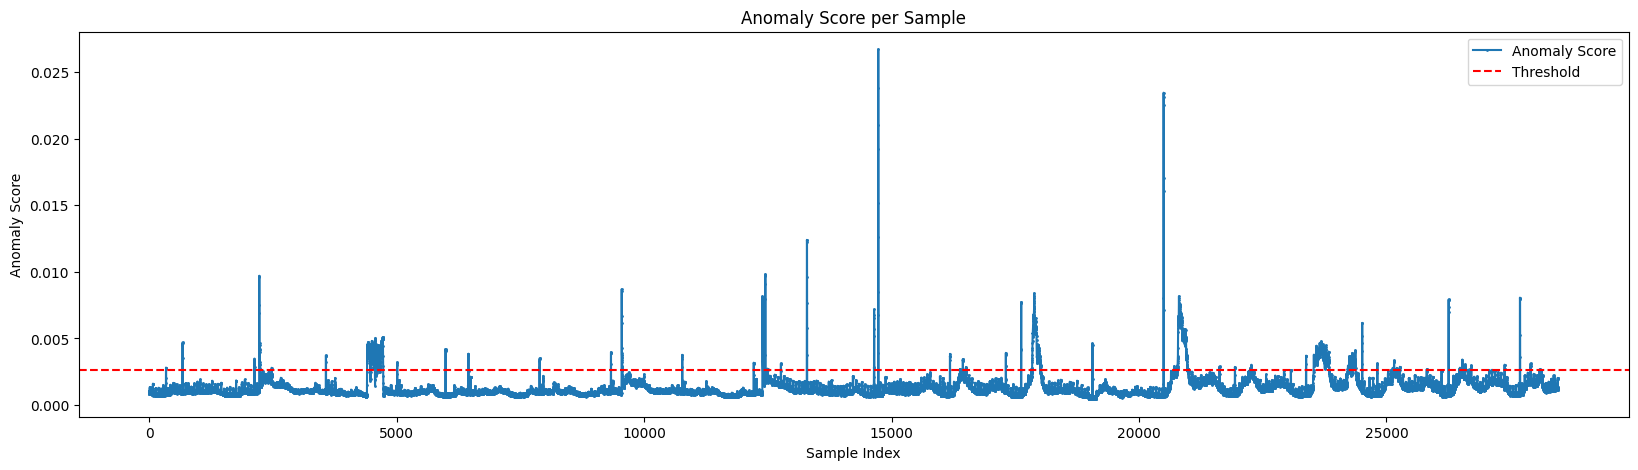

In [10]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.6236, Precision: 0.4958, Recall: 0.8400


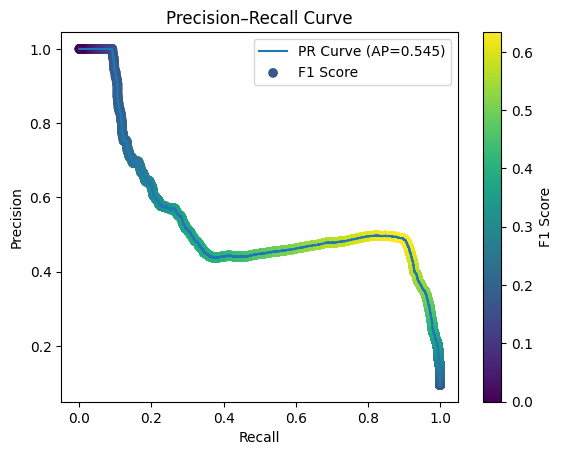

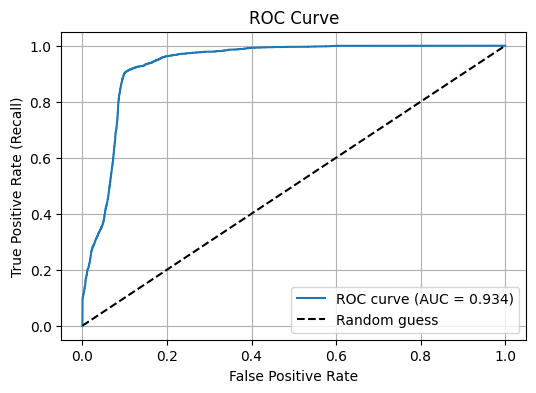

In [11]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.6191, Precision: 0.4783, Recall: 0.8771


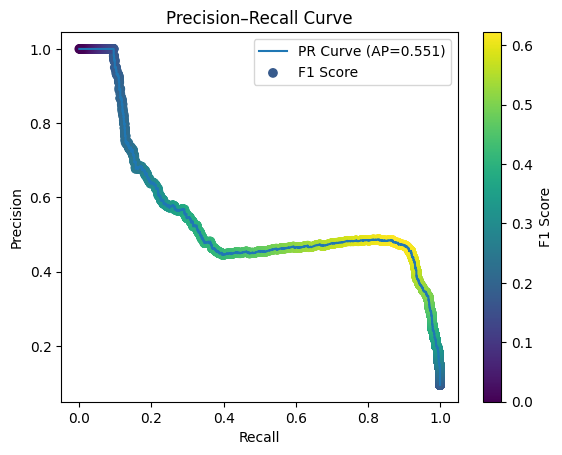

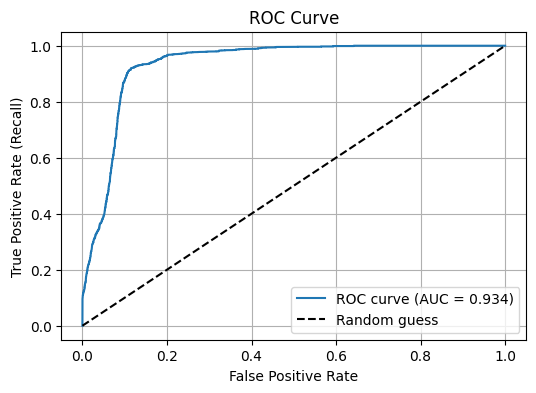

In [12]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [13]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 90.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4408, Precision: 0.4399, Recall: 0.4417


In [14]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 90.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4523, Precision: 0.4514, Recall: 0.4532


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0039, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0039, Epoch loss: 0.0038, Delta loss: 0.0001
Epoch 3/30
		 Previous Loss 0.0038, Epoch loss: 0.0027, Delta loss: 0.0011
Epoch 4/30
		 Previous Loss 0.0027, Epoch loss: 0.0016, Delta loss: 0.0011
Epoch 5/30
		 Previous Loss 0.0016, Epoch loss: 0.0012, Delta loss: 0.0004
Epoch 6/30
		 Previous Loss 0.0012, Epoch loss: 0.0011, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0012, Epoch loss: 0.0011, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0011, Epoch loss: 0.0010, Delta loss: 0.0000
Epoch 9/30
		 Previous Loss 0.0011, Epoch loss: 0.0010, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0011, Epoch loss: 0.0010, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0011, Epoch loss: 0.0010, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0010, Epoch loss: 0.0009, Delta loss: 0.0000
Epoch 13/30
		 Previous Loss 0.0010, Epoch loss: 0.0009, Delta loss: 0.0000
Epoch 14/30
		 Previous Los

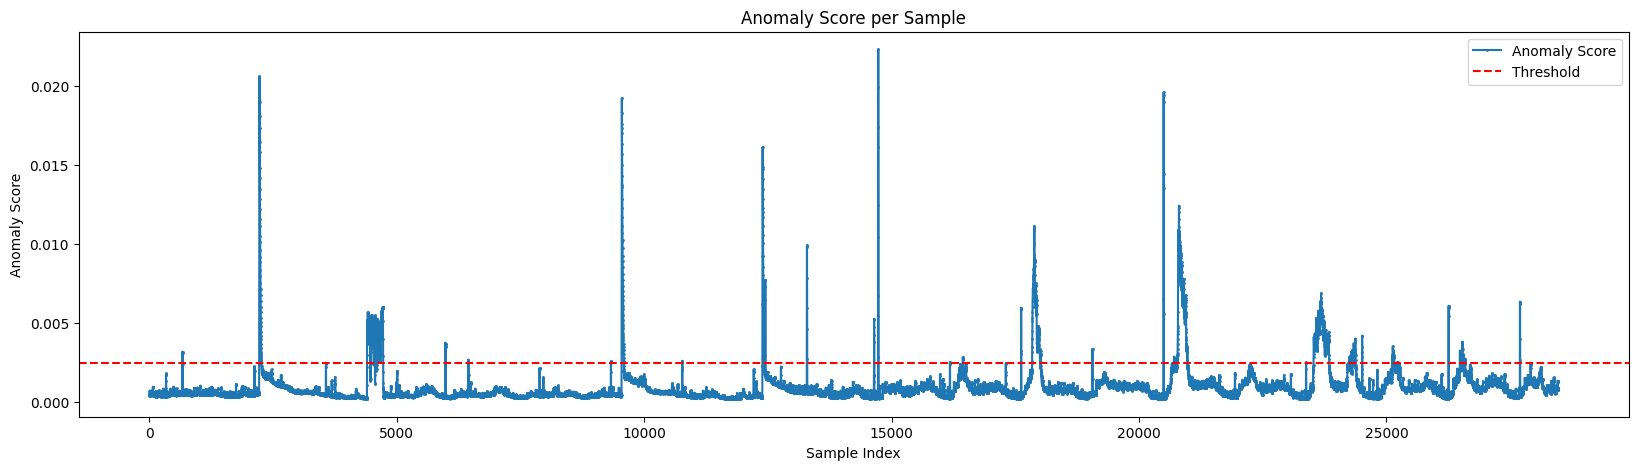

In [15]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.5624, Precision: 0.4619, Recall: 0.7186


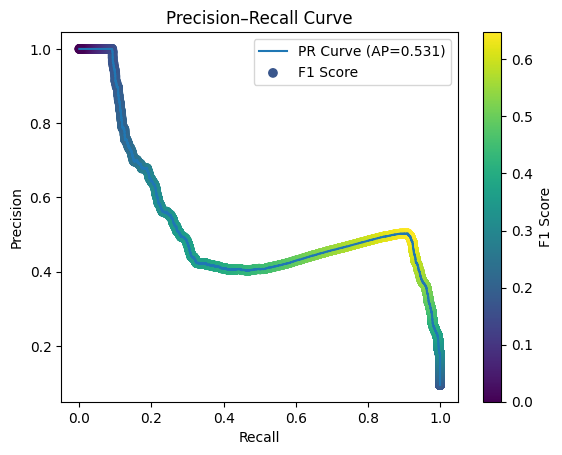

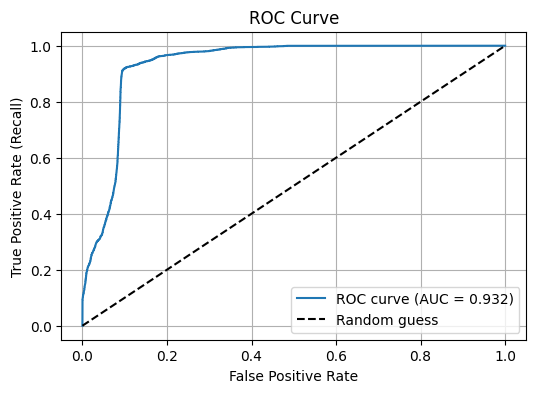

In [16]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.5927, Precision: 0.4719, Recall: 0.7966


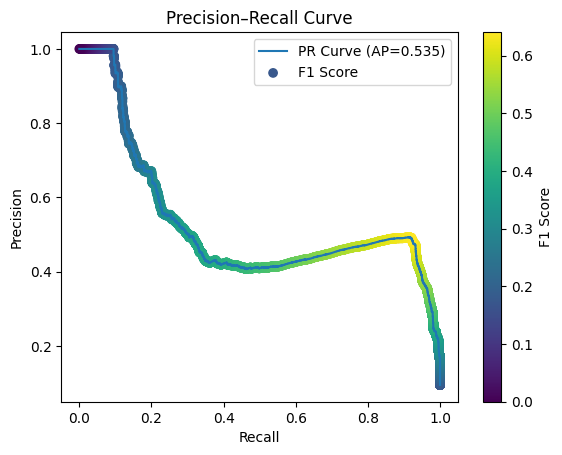

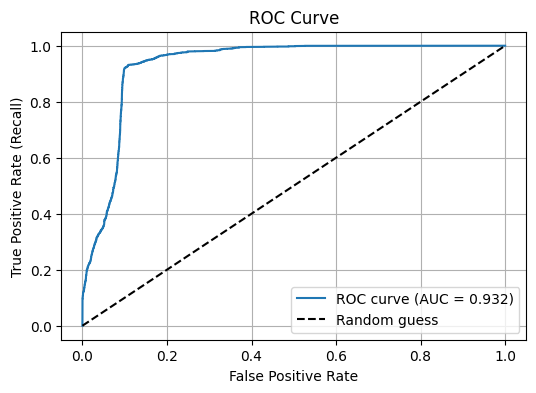

In [17]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

Average pooling helps not accidentally mislabelling data as abnormal when it is normal since if the data is normal, more windows containing timestamp x is lower score, so average is lower
    If x is abnormal, even on average it would still be high, but the surrounding timestamps wont be polluted by the high window score. However the averaging can also squashes down anomalous value
    This results in higher precision scores while lowering recalls

Max pooling helps separating true anomaly from normal data, but risk polutting nearby timestamps if anomalous timestamp is surrounded by normal timestamp
    This results in higher recall but lowering precisions

In [18]:
y_test_full.value_counts()

0
0    25785
1     2694
Name: count, dtype: int64

In [19]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 90.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4079, Precision: 0.4070, Recall: 0.4087


In [20]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 90.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4201, Precision: 0.4192, Recall: 0.4209


<span style='color:red; font-size:60px'> Machine-1-2 </span>

In [21]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(1,2)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0066, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0066, Epoch loss: 0.0057, Delta loss: 0.0009
Epoch 3/30
		 Previous Loss 0.0057, Epoch loss: 0.0055, Delta loss: 0.0002
Epoch 4/30
		 Previous Loss 0.0055, Epoch loss: 0.0043, Delta loss: 0.0012
Epoch 5/30
		 Previous Loss 0.0043, Epoch loss: 0.0035, Delta loss: 0.0008
Epoch 6/30
		 Previous Loss 0.0035, Epoch loss: 0.0024, Delta loss: 0.0011
Epoch 7/30
		 Previous Loss 0.0024, Epoch loss: 0.0022, Delta loss: 0.0002
Epoch 8/30
		 Previous Loss 0.0022, Epoch loss: 0.0026, Delta loss: -0.0004

 max_err: 0.050760671496391296, min_err: 0.0006095453863963485


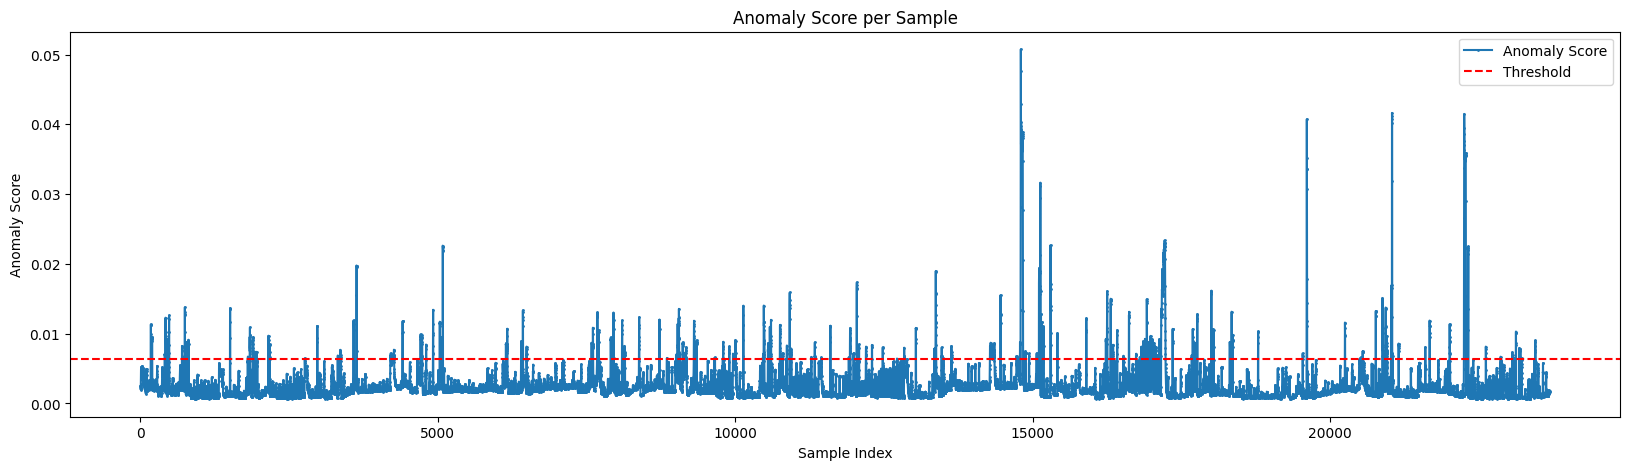

In [22]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.6028, Precision: 0.7347, Recall: 0.5111


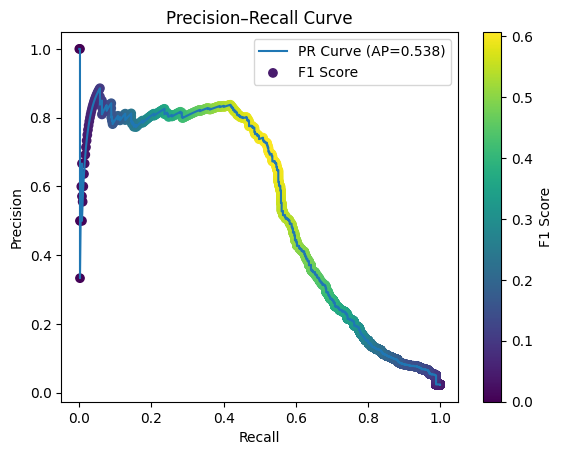

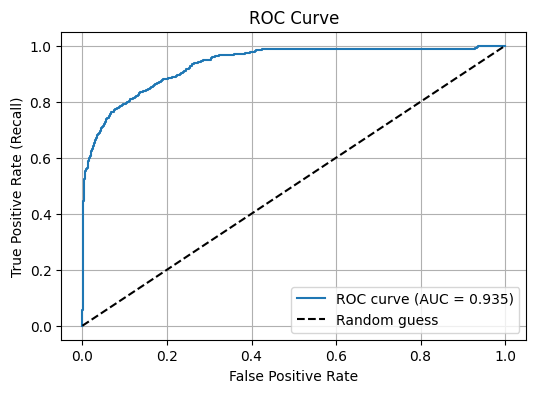

In [23]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.5919, Precision: 0.5808, Recall: 0.6033


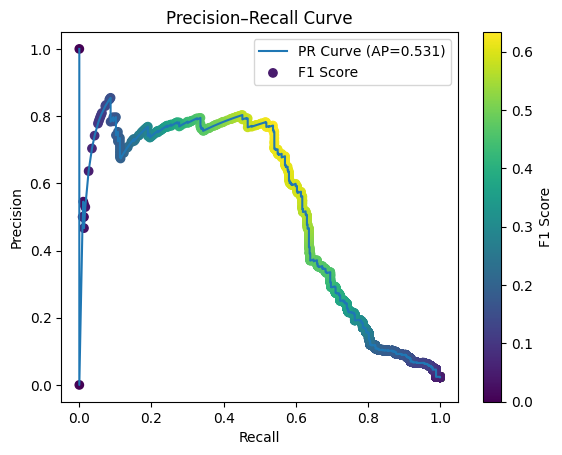

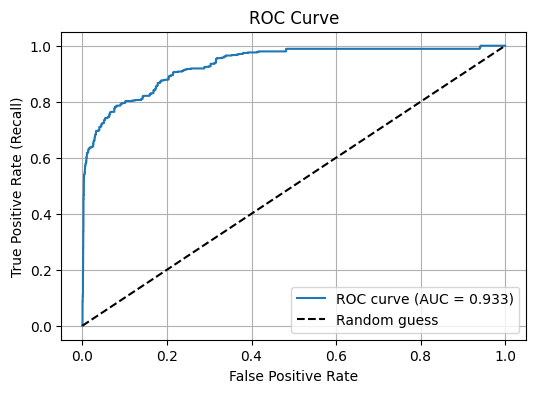

In [24]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [25]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.5886, Precision: 0.6308, Recall: 0.5517


In [26]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.6102, Precision: 0.6540, Recall: 0.5720


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0066, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0066, Epoch loss: 0.0065, Delta loss: 0.0001
Epoch 3/30
		 Previous Loss 0.0066, Epoch loss: 0.0064, Delta loss: 0.0002
Epoch 4/30
		 Previous Loss 0.0064, Epoch loss: 0.0050, Delta loss: 0.0014
Epoch 5/30
		 Previous Loss 0.0050, Epoch loss: 0.0047, Delta loss: 0.0003
Epoch 6/30
		 Previous Loss 0.0047, Epoch loss: 0.0056, Delta loss: -0.0009

 max_err: 0.09067428857088089, min_err: 0.0011559838894754648


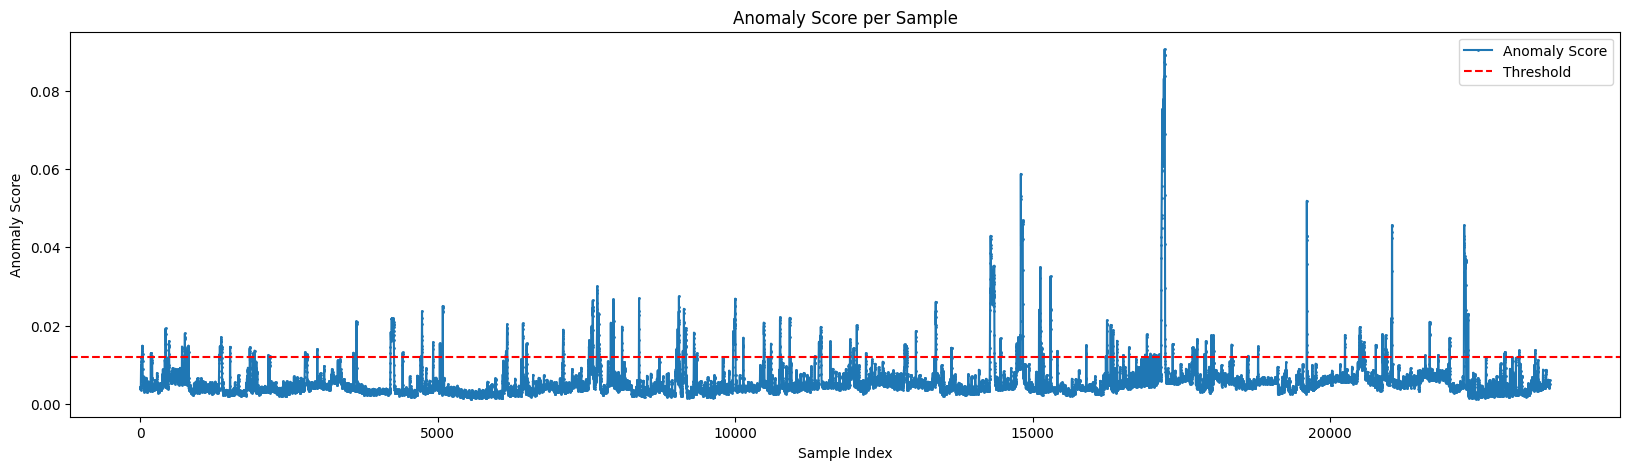

In [27]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.5658, Precision: 0.6973, Recall: 0.4760


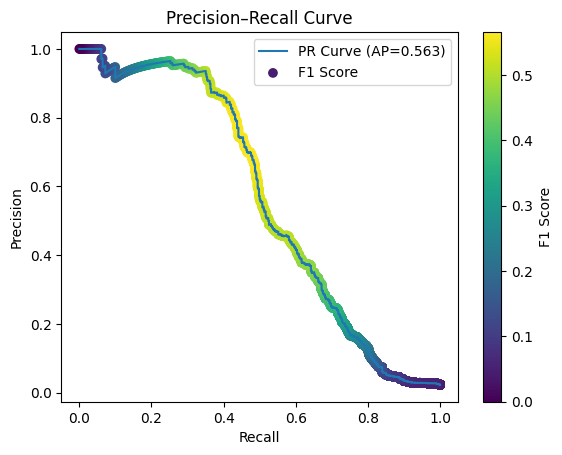

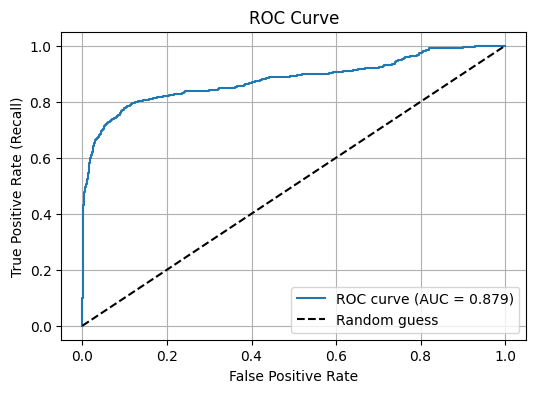

In [28]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.5630, Precision: 0.5789, Recall: 0.5480


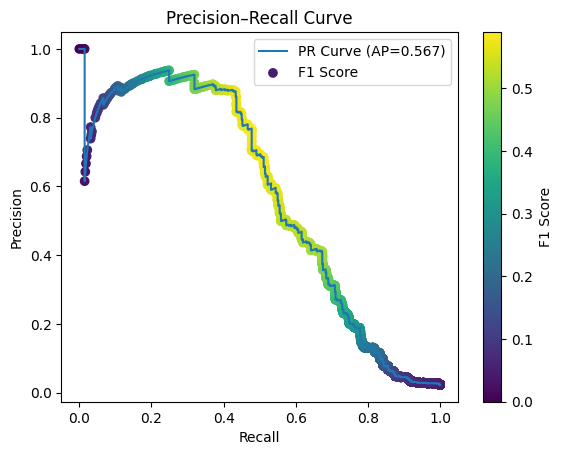

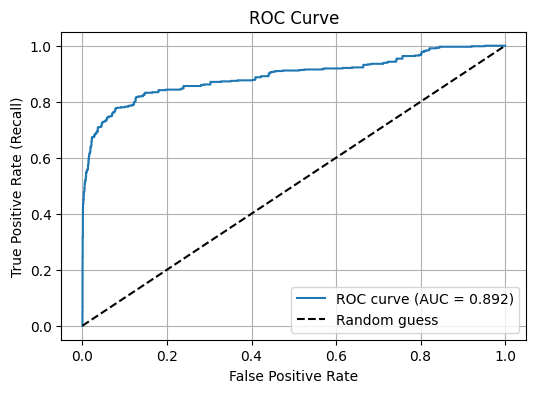

In [29]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [30]:
y_test_full.value_counts()

0
0    23152
1      542
Name: count, dtype: int64

In [31]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.5335, Precision: 0.5717, Recall: 0.5000


In [32]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.5669, Precision: 0.6076, Recall: 0.5314


<span style='color:red; font-size:60px'> Machine-1-3 </span>

In [33]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(1,3)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0139, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0139, Epoch loss: 0.0105, Delta loss: 0.0034
Epoch 3/30
		 Previous Loss 0.0105, Epoch loss: 0.0094, Delta loss: 0.0011
Epoch 4/30
		 Previous Loss 0.0094, Epoch loss: 0.0087, Delta loss: 0.0007
Epoch 5/30
		 Previous Loss 0.0087, Epoch loss: 0.0083, Delta loss: 0.0004
Epoch 6/30
		 Previous Loss 0.0083, Epoch loss: 0.0080, Delta loss: 0.0003
Epoch 7/30
		 Previous Loss 0.0080, Epoch loss: 0.0076, Delta loss: 0.0003
Epoch 8/30
		 Previous Loss 0.0076, Epoch loss: 0.0073, Delta loss: 0.0003
Epoch 9/30
		 Previous Loss 0.0073, Epoch loss: 0.0070, Delta loss: 0.0004
Epoch 10/30
		 Previous Loss 0.0070, Epoch loss: 0.0066, Delta loss: 0.0004
Epoch 11/30
		 Previous Loss 0.0066, Epoch loss: 0.0062, Delta loss: 0.0004
Epoch 12/30
		 Previous Loss 0.0062, Epoch loss: 0.0060, Delta loss: 0.0003
Epoch 13/30
		 Previous Loss 0.0060, Epoch loss: 0.0058, Delta loss: 0.0002
Epoch 14/30
		 Previous Los

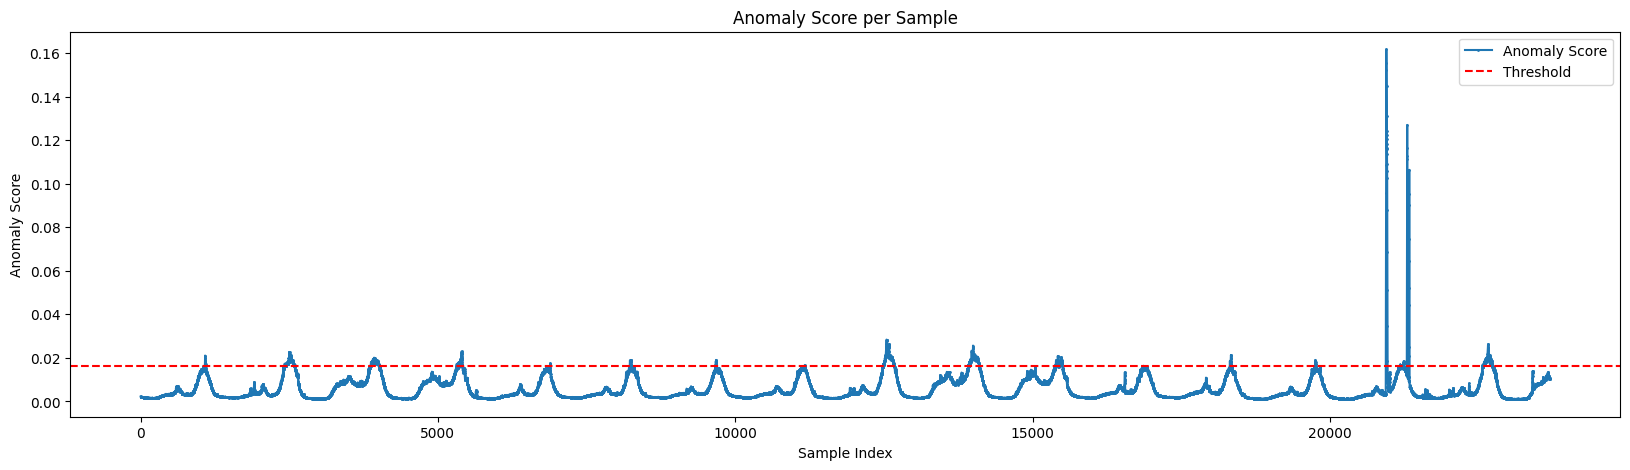

In [34]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.2553, Precision: 0.4190, Recall: 0.1836


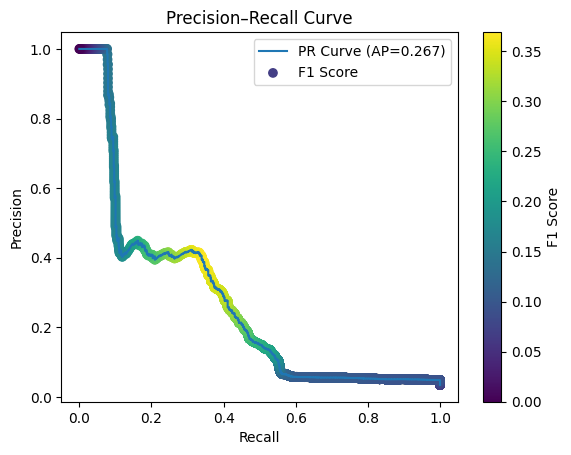

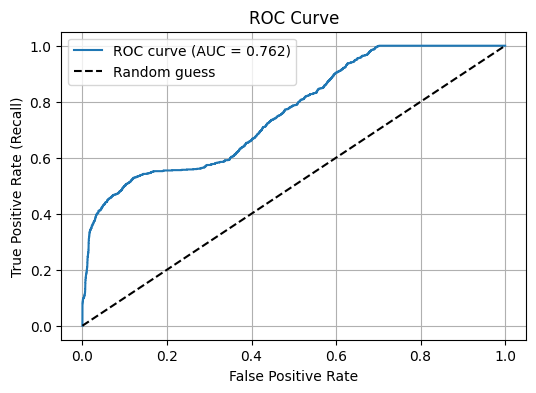

In [35]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.2986, Precision: 0.4336, Recall: 0.2277


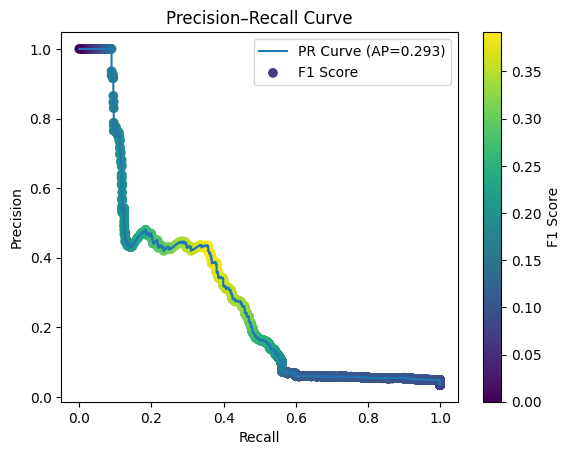

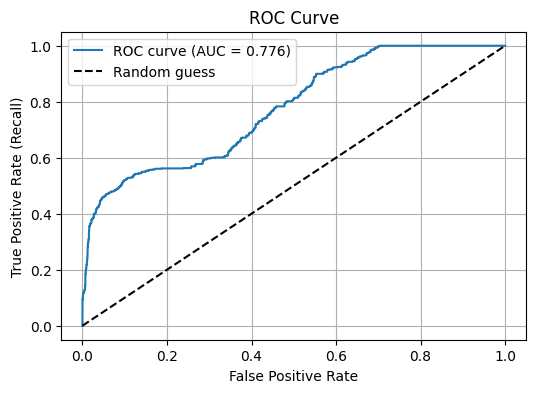

In [36]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [37]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 96.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3546, Precision: 0.3518, Recall: 0.3574


In [38]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 96.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3781, Precision: 0.3756, Recall: 0.3807


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0140, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0140, Epoch loss: 0.0130, Delta loss: 0.0010
Epoch 3/30
		 Previous Loss 0.0130, Epoch loss: 0.0035, Delta loss: 0.0095
Epoch 4/30
		 Previous Loss 0.0035, Epoch loss: 0.0018, Delta loss: 0.0016
Epoch 5/30
		 Previous Loss 0.0018, Epoch loss: 0.0016, Delta loss: 0.0003
Epoch 6/30
		 Previous Loss 0.0016, Epoch loss: 0.0015, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0015, Epoch loss: 0.0016, Delta loss: -0.0001

 max_err: 0.1512410044670105, min_err: 0.00014477220247499645


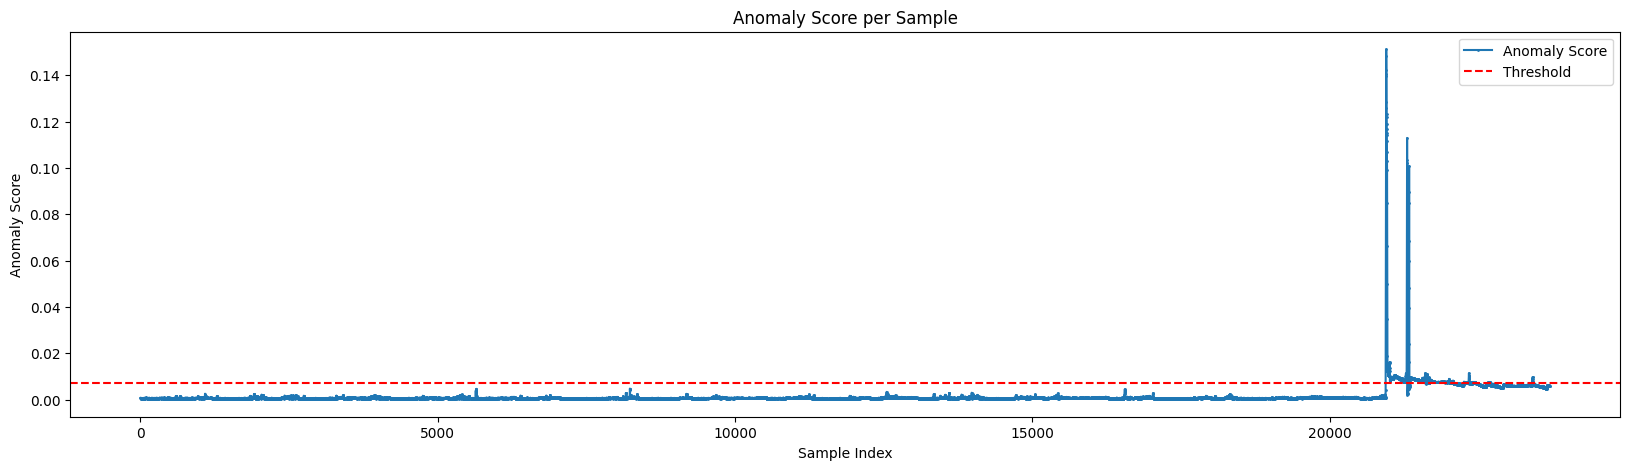

In [39]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.1092, Precision: 0.1121, Recall: 0.1065


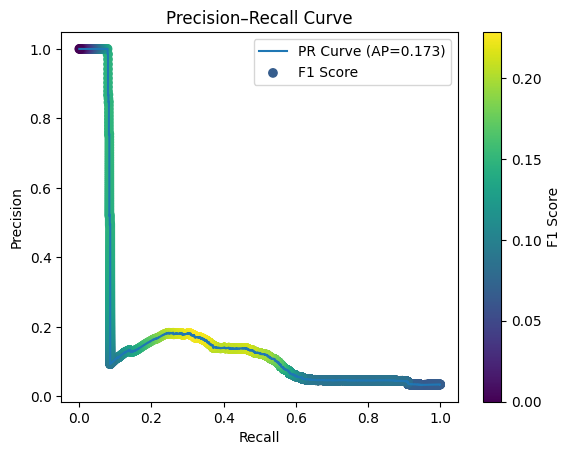

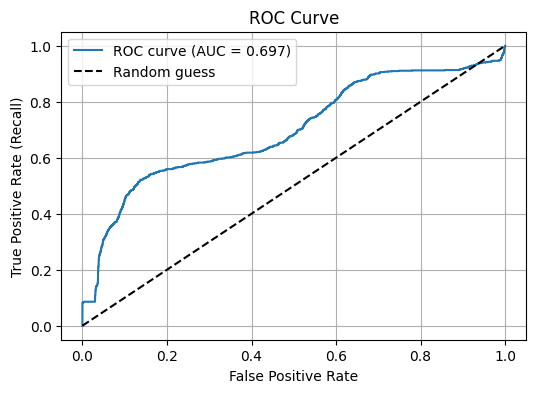

In [40]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1254, Precision: 0.1259, Recall: 0.1248


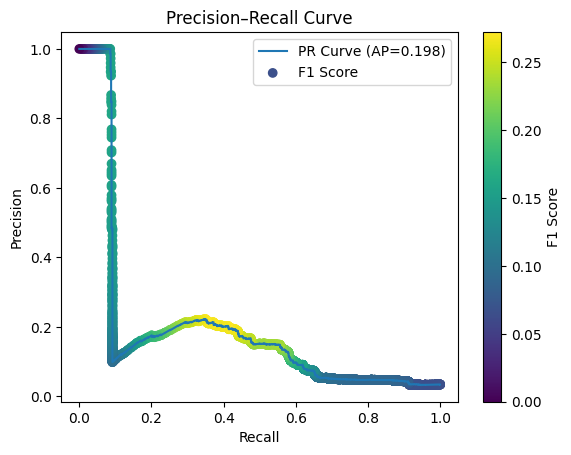

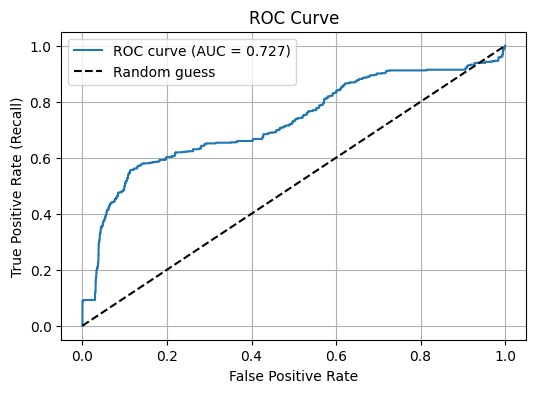

In [41]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [42]:
y_test_full.value_counts()

0
0    22886
1      817
Name: count, dtype: int64

In [43]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 96.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1299, Precision: 0.1289, Recall: 0.1310


In [44]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 96.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1409, Precision: 0.1399, Recall: 0.1420


<span style='color:red; font-size:60px'> Machine-1-4 </span>

In [45]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(1,4)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0162, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0162, Epoch loss: 0.0128, Delta loss: 0.0035
Epoch 3/30
		 Previous Loss 0.0128, Epoch loss: 0.0120, Delta loss: 0.0008
Epoch 4/30
		 Previous Loss 0.0120, Epoch loss: 0.0116, Delta loss: 0.0004
Epoch 5/30
		 Previous Loss 0.0116, Epoch loss: 0.0112, Delta loss: 0.0004
Epoch 6/30
		 Previous Loss 0.0112, Epoch loss: 0.0109, Delta loss: 0.0003
Epoch 7/30
		 Previous Loss 0.0109, Epoch loss: 0.0107, Delta loss: 0.0002
Epoch 8/30
		 Previous Loss 0.0107, Epoch loss: 0.0071, Delta loss: 0.0036
Epoch 9/30
		 Previous Loss 0.0071, Epoch loss: 0.0063, Delta loss: 0.0008
Epoch 10/30
		 Previous Loss 0.0063, Epoch loss: 0.0030, Delta loss: 0.0034
Epoch 11/30
		 Previous Loss 0.0030, Epoch loss: 0.0027, Delta loss: 0.0002
Epoch 12/30
		 Previous Loss 0.0027, Epoch loss: 0.0026, Delta loss: 0.0002
Epoch 13/30
		 Previous Loss 0.0026, Epoch loss: 0.0025, Delta loss: 0.0001
Epoch 14/30
		 Previous Los

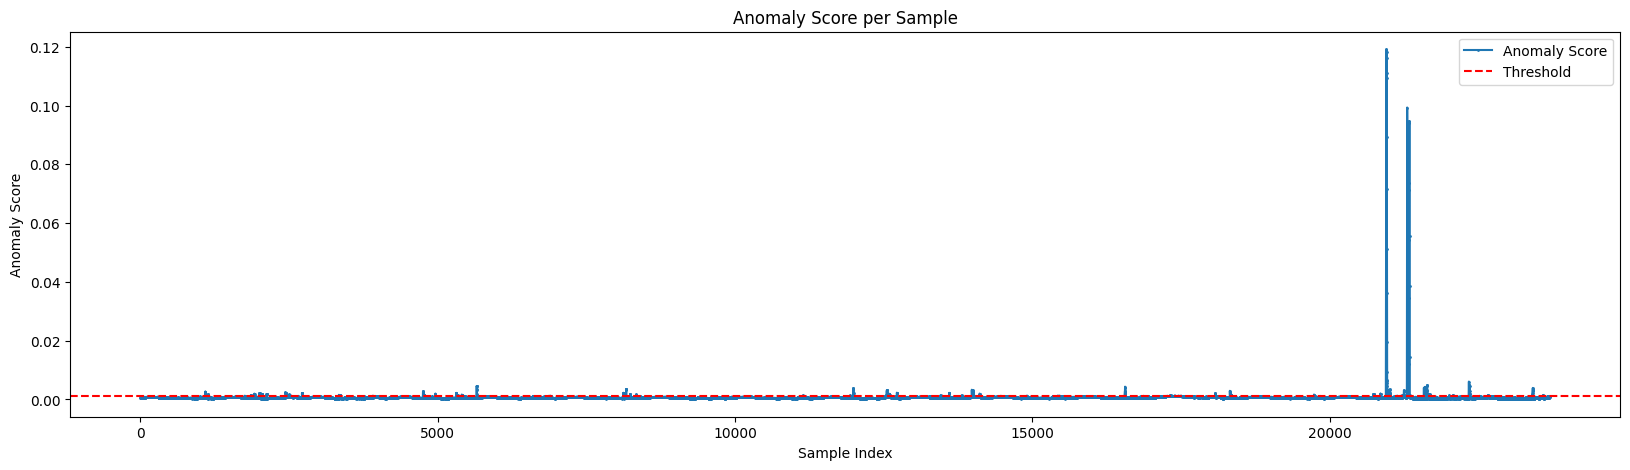

In [46]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.3445, Precision: 0.2265, Recall: 0.7194


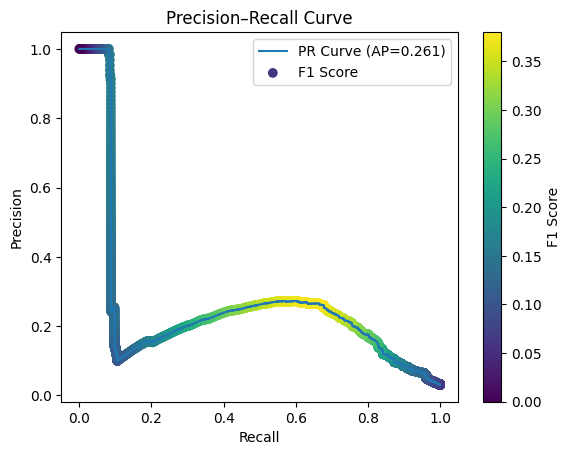

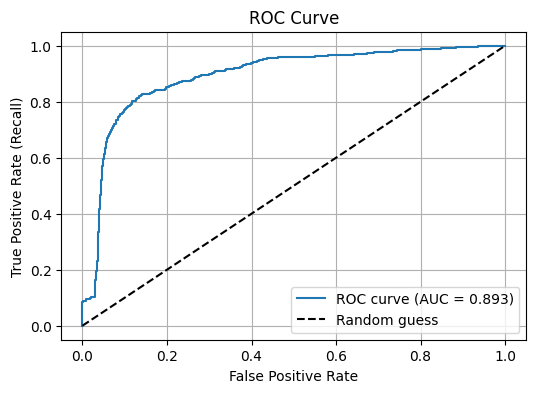

In [47]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.3310, Precision: 0.2094, Recall: 0.7889


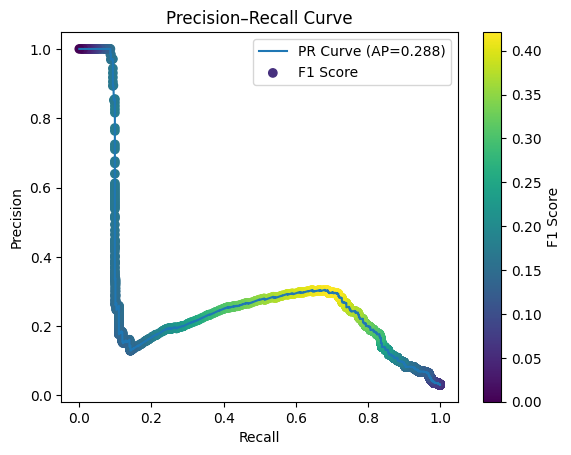

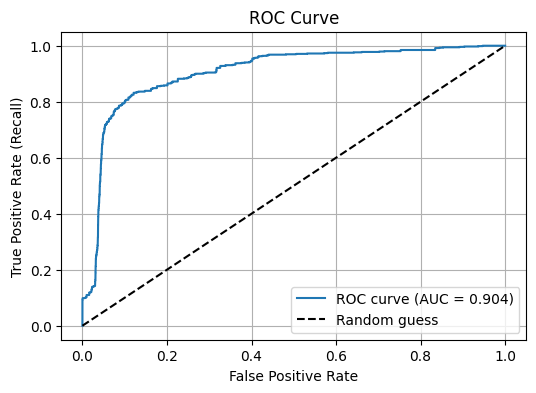

In [48]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [49]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 97), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1048, Precision: 0.1055, Recall: 0.1042


In [50]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 97), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1426, Precision: 0.1435, Recall: 0.1417


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0191, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0191, Epoch loss: 0.0191, Delta loss: -0.0000
Epoch 3/30
		 Previous Loss 0.0191, Epoch loss: 0.0190, Delta loss: 0.0001
Epoch 4/30
		 Previous Loss 0.0190, Epoch loss: 0.0163, Delta loss: 0.0027
Epoch 5/30
		 Previous Loss 0.0163, Epoch loss: 0.0070, Delta loss: 0.0093
Epoch 6/30
		 Previous Loss 0.0070, Epoch loss: 0.0062, Delta loss: 0.0007
Epoch 7/30
		 Previous Loss 0.0062, Epoch loss: 0.0059, Delta loss: 0.0003
Epoch 8/30
		 Previous Loss 0.0059, Epoch loss: 0.0057, Delta loss: 0.0002
Epoch 9/30
		 Previous Loss 0.0057, Epoch loss: 0.0058, Delta loss: -0.0001
Epoch 10/30
		 Previous Loss 0.0057, Epoch loss: 0.0055, Delta loss: 0.0002
Epoch 11/30
		 Previous Loss 0.0055, Epoch loss: 0.0055, Delta loss: 0.0000
Epoch 12/30
		 Previous Loss 0.0055, Epoch loss: 0.0055, Delta loss: -0.0000
Epoch 13/30
		 Previous Loss 0.0055, Epoch loss: 0.0336, Delta loss: -0.0281

 max_err: 0.1735437959

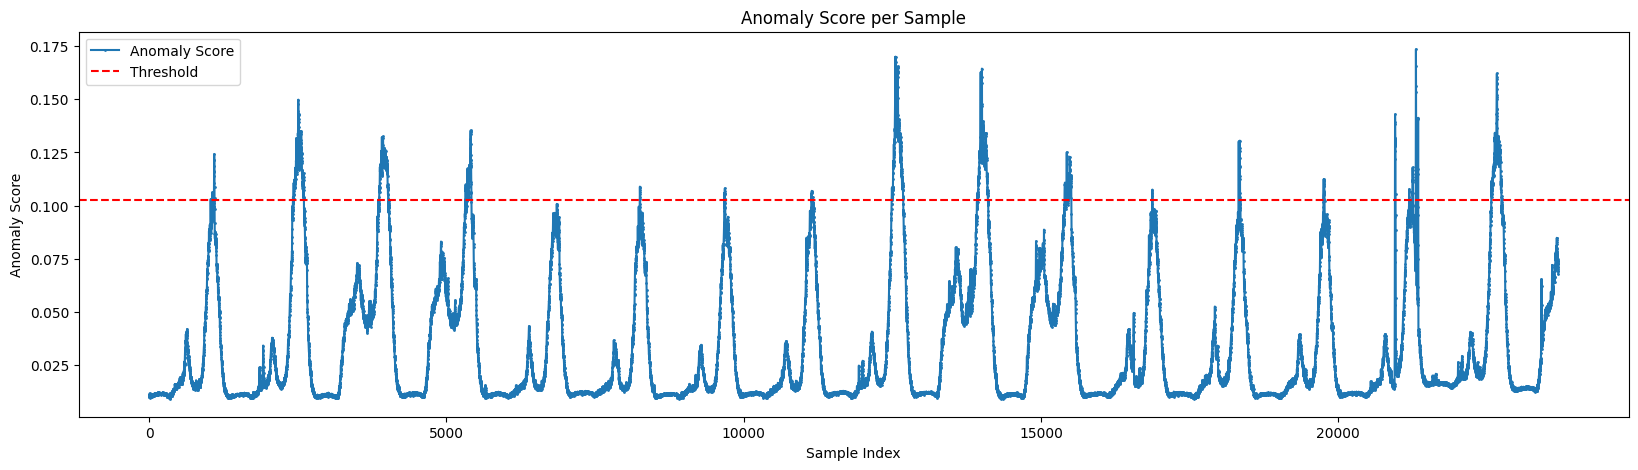

In [51]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.1787, Precision: 0.5098, Recall: 0.1083


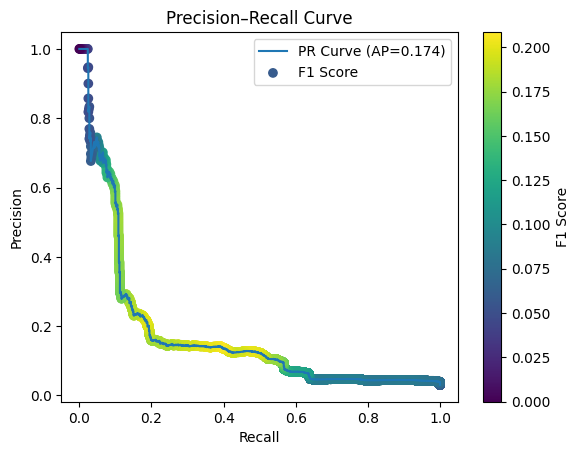

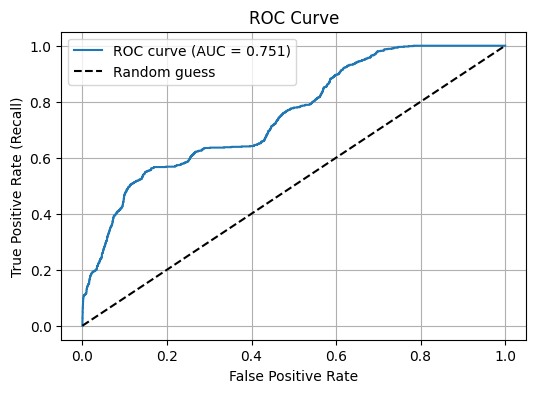

In [52]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1907, Precision: 0.4018, Recall: 0.1250


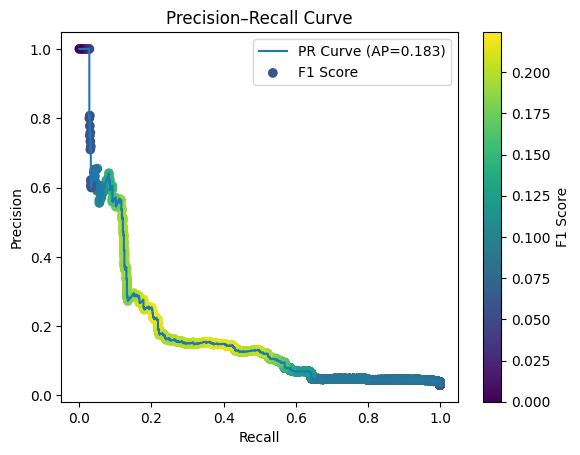

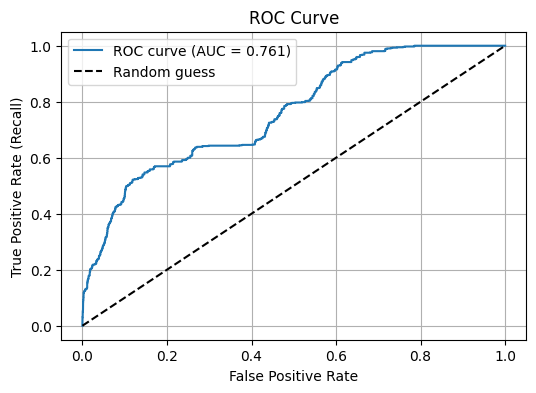

In [53]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [54]:
y_test_full.value_counts()

0
0    22987
1      720
Name: count, dtype: int64

In [55]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 97), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1943, Precision: 0.1955, Recall: 0.1931


In [56]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 97), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.2180, Precision: 0.2194, Recall: 0.2167


<span style='color:red; font-size:60px'> Machine-1-5 </span>

In [57]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(1,5)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0048, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0048, Epoch loss: 0.0030, Delta loss: 0.0017
Epoch 3/30
		 Previous Loss 0.0030, Epoch loss: 0.0027, Delta loss: 0.0004
Epoch 4/30
		 Previous Loss 0.0027, Epoch loss: 0.0026, Delta loss: 0.0001
Epoch 5/30
		 Previous Loss 0.0027, Epoch loss: 0.0025, Delta loss: 0.0001
Epoch 6/30
		 Previous Loss 0.0025, Epoch loss: 0.0025, Delta loss: 0.0000
Epoch 7/30
		 Previous Loss 0.0025, Epoch loss: 0.0025, Delta loss: 0.0000
Epoch 8/30
		 Previous Loss 0.0025, Epoch loss: 0.0025, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0025, Epoch loss: 0.0024, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0024, Epoch loss: 0.0024, Delta loss: 0.0000
Epoch 11/30
		 Previous Loss 0.0024, Epoch loss: 0.0024, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0024, Epoch loss: 0.0024, Delta loss: 0.0001
Epoch 13/30
		 Previous Loss 0.0024, Epoch loss: 0.0024, Delta loss: 0.0001

 max_err: 0.01452569942921

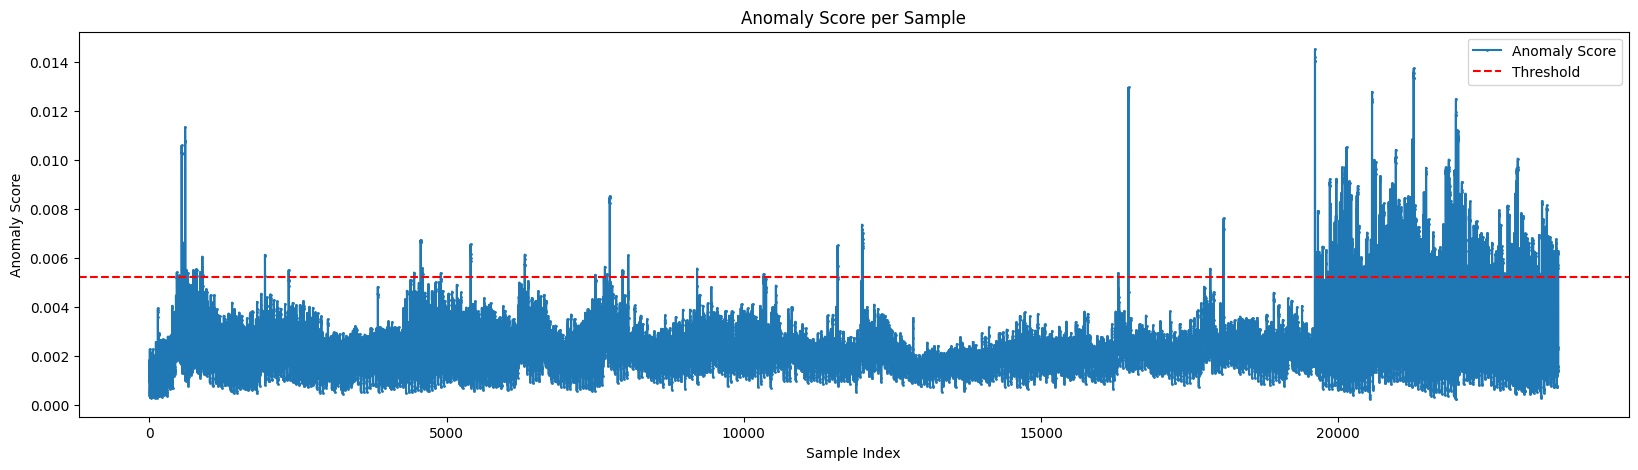

In [58]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.3796, Precision: 0.2508, Recall: 0.7800


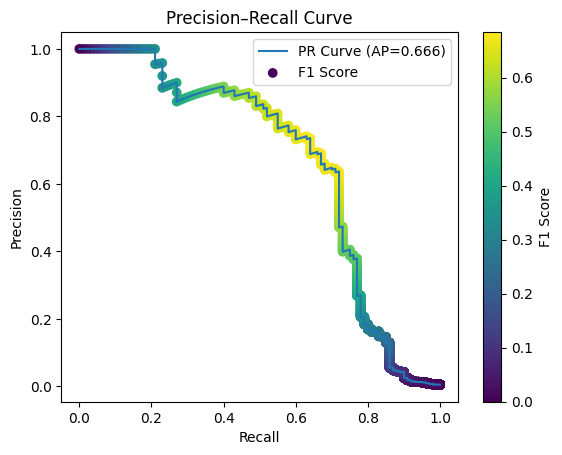

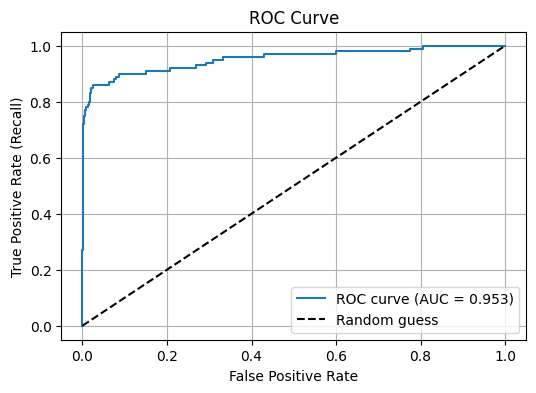

In [59]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.0935, Precision: 0.0493, Recall: 0.8900


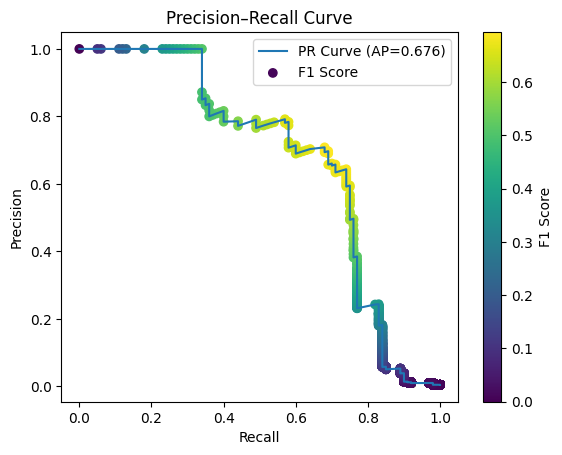

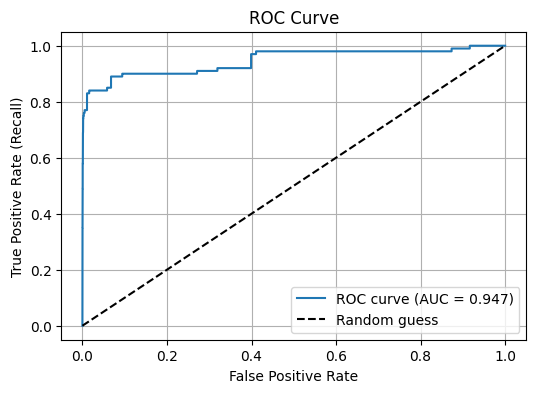

In [60]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [61]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.6575, Precision: 0.6050, Recall: 0.7200


In [62]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.6758, Precision: 0.6218, Recall: 0.7400


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0078, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0078, Epoch loss: 0.0072, Delta loss: 0.0006
Epoch 3/30
		 Previous Loss 0.0072, Epoch loss: 0.0054, Delta loss: 0.0018
Epoch 4/30
		 Previous Loss 0.0054, Epoch loss: 0.0034, Delta loss: 0.0020
Epoch 5/30
		 Previous Loss 0.0034, Epoch loss: 0.0032, Delta loss: 0.0002
Epoch 6/30
		 Previous Loss 0.0032, Epoch loss: 0.0029, Delta loss: 0.0003
Epoch 7/30
		 Previous Loss 0.0029, Epoch loss: 0.0028, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0029, Epoch loss: 0.0063, Delta loss: -0.0034

 max_err: 0.034384407103061676, min_err: 0.000511285790707916


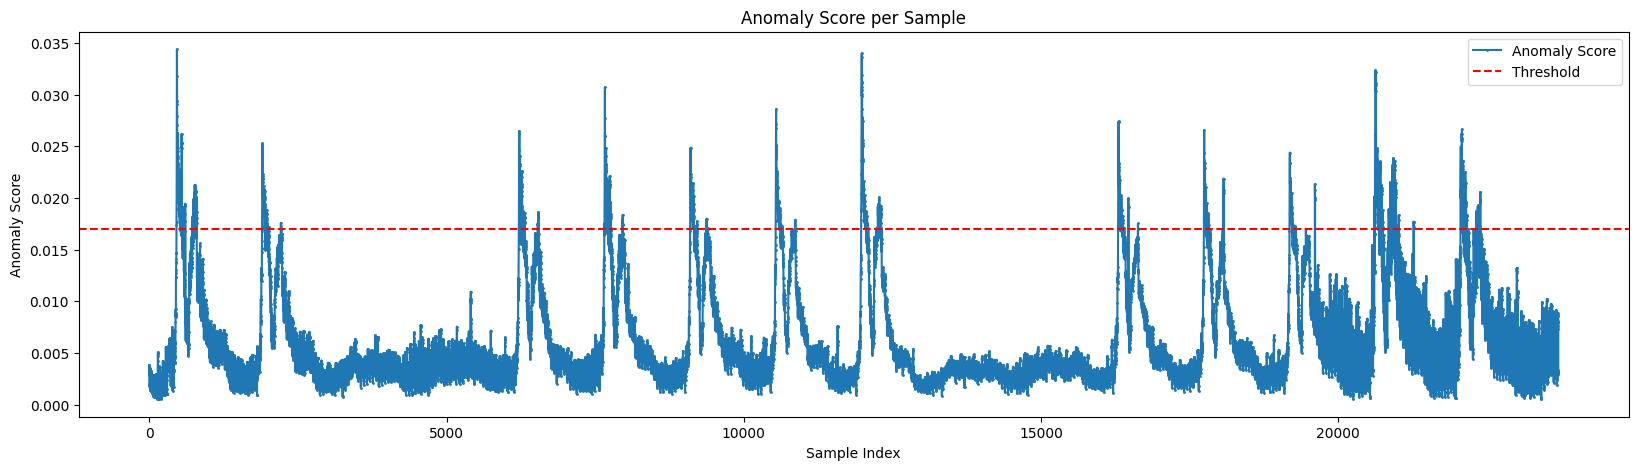

In [63]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.2275, Precision: 0.1334, Recall: 0.7700


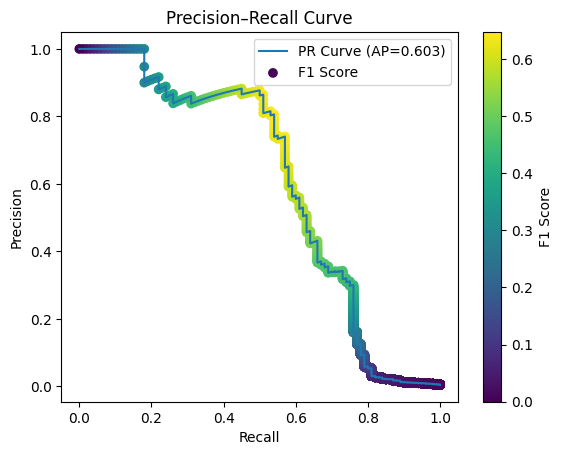

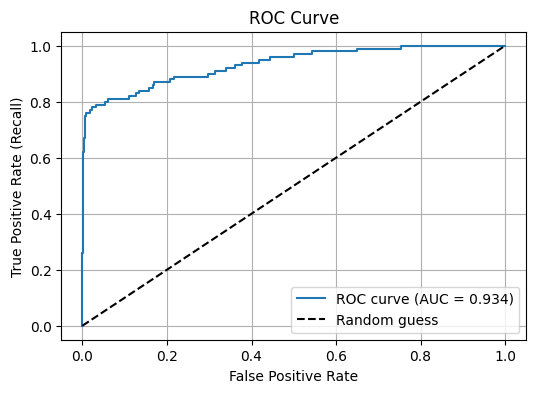

In [64]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1360, Precision: 0.0740, Recall: 0.8400


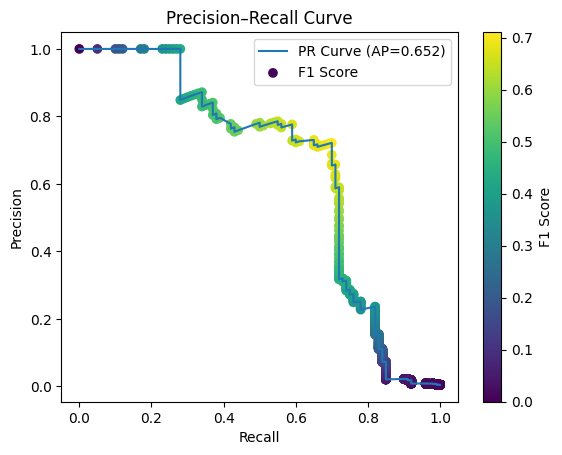

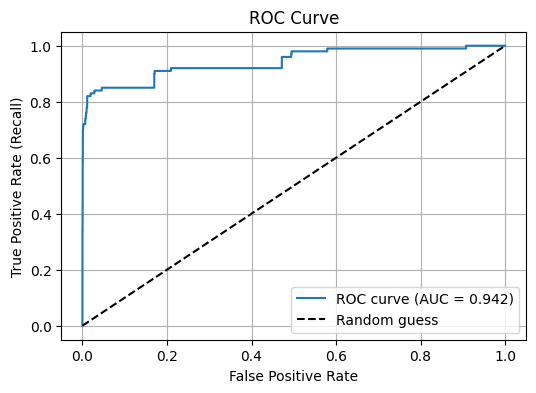

In [65]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [66]:
y_test_full.value_counts()

0
0    23606
1      100
Name: count, dtype: int64

In [67]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.5662, Precision: 0.5210, Recall: 0.6200


In [68]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.6605, Precision: 0.6174, Recall: 0.7100


<span style='color:red; font-size:60px'> Machine-1-6 </span>

In [69]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(1,6)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0195, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0195, Epoch loss: 0.0080, Delta loss: 0.0114
Epoch 3/30
		 Previous Loss 0.0080, Epoch loss: 0.0071, Delta loss: 0.0009
Epoch 4/30
		 Previous Loss 0.0071, Epoch loss: 0.0069, Delta loss: 0.0002
Epoch 5/30
		 Previous Loss 0.0069, Epoch loss: 0.0068, Delta loss: 0.0001
Epoch 6/30
		 Previous Loss 0.0069, Epoch loss: 0.0068, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0068, Epoch loss: 0.0067, Delta loss: 0.0000
Epoch 8/30
		 Previous Loss 0.0068, Epoch loss: 0.0067, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0067, Epoch loss: 0.0066, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0067, Epoch loss: 0.0066, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0066, Epoch loss: 0.0065, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0066, Epoch loss: 0.0064, Delta loss: 0.0001
Epoch 13/30
		 Previous Loss 0.0064, Epoch loss: 0.0064, Delta loss: 0.0001
Epoch 14/30
		 Previous Los

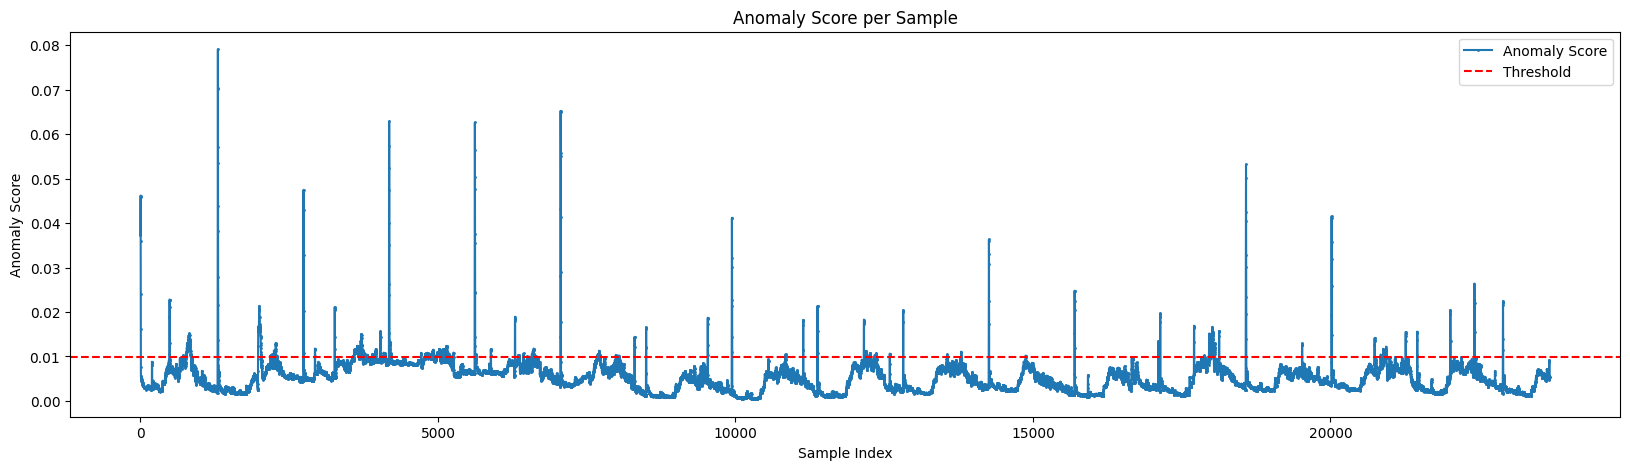

In [70]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.3174, Precision: 0.1925, Recall: 0.9043


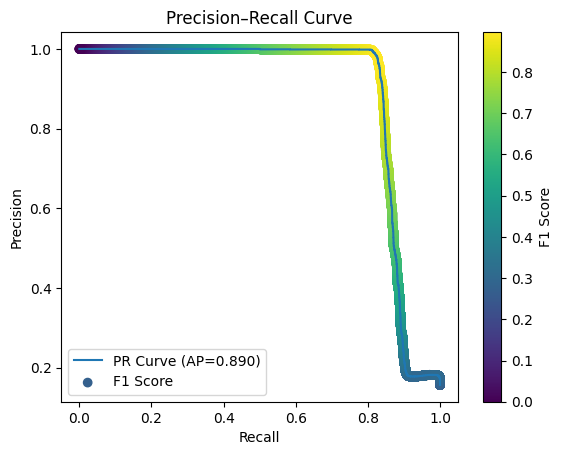

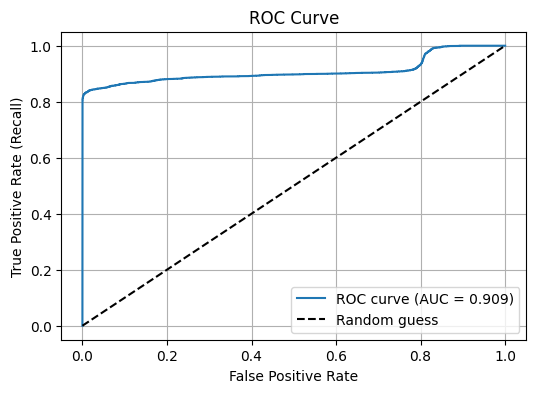

In [71]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.3114, Precision: 0.1878, Recall: 0.9099


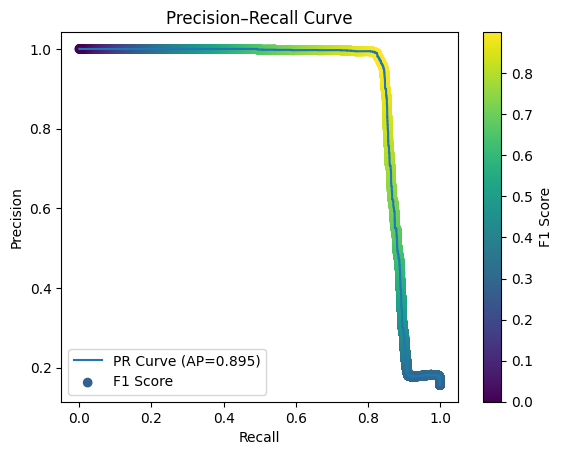

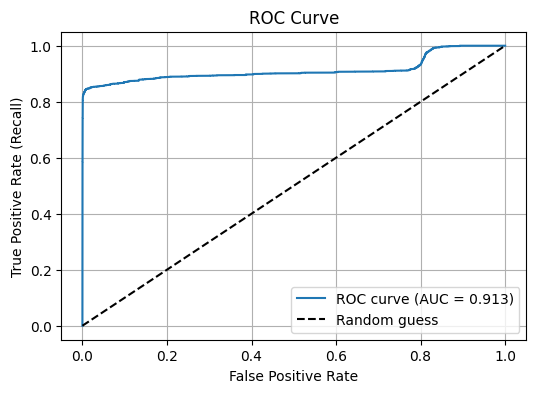

In [72]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [73]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 85), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8602, Precision: 0.8790, Recall: 0.8422


In [74]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 85), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8688, Precision: 0.8877, Recall: 0.8506


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0079, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0079, Epoch loss: 0.0078, Delta loss: 0.0002
Epoch 3/30
		 Previous Loss 0.0078, Epoch loss: 0.0077, Delta loss: 0.0001
Epoch 4/30
		 Previous Loss 0.0078, Epoch loss: 0.0075, Delta loss: 0.0002
Epoch 5/30
		 Previous Loss 0.0075, Epoch loss: 0.0056, Delta loss: 0.0020
Epoch 6/30
		 Previous Loss 0.0056, Epoch loss: 0.0037, Delta loss: 0.0019
Epoch 7/30
		 Previous Loss 0.0037, Epoch loss: 0.0033, Delta loss: 0.0004
Epoch 8/30
		 Previous Loss 0.0033, Epoch loss: 0.0033, Delta loss: 0.0000
Epoch 9/30
		 Previous Loss 0.0033, Epoch loss: 0.0031, Delta loss: 0.0002
Epoch 10/30
		 Previous Loss 0.0031, Epoch loss: 0.0030, Delta loss: 0.0000
Epoch 11/30
		 Previous Loss 0.0031, Epoch loss: 0.0030, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0031, Epoch loss: 0.0030, Delta loss: 0.0001
Epoch 13/30
		 Previous Loss 0.0031, Epoch loss: 0.0030, Delta loss: 0.0000

 max_err: 0.08465076237916

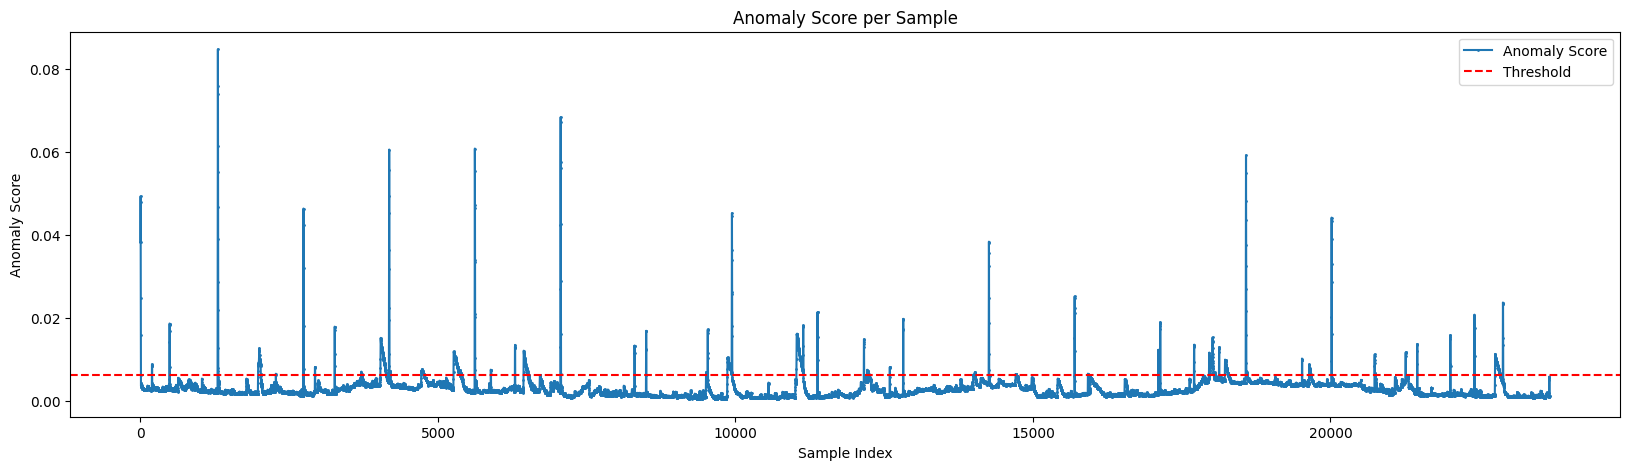

In [75]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.3501, Precision: 0.2164, Recall: 0.9153


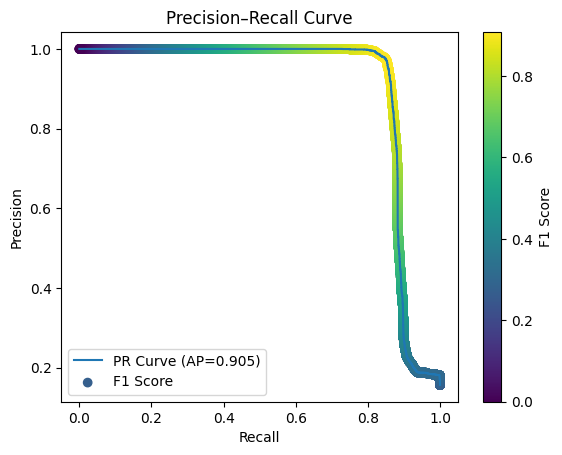

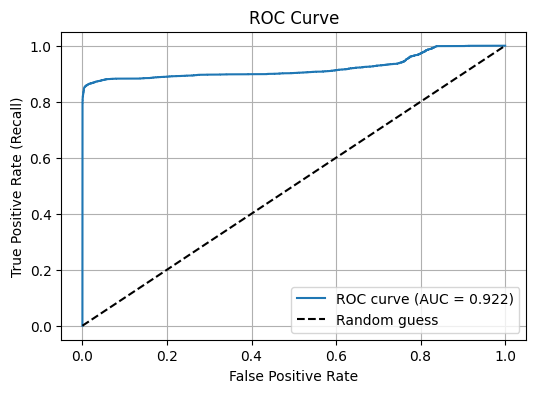

In [76]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.3373, Precision: 0.2063, Recall: 0.9245


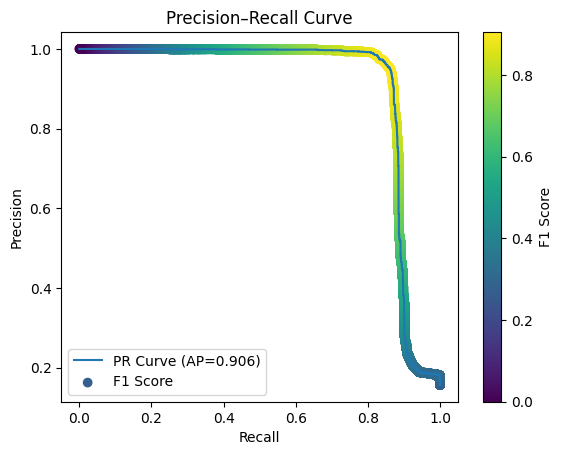

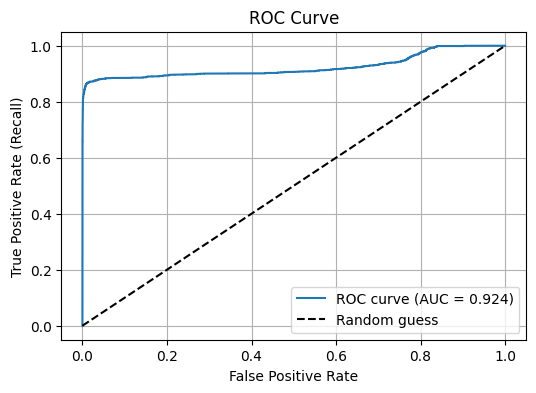

In [77]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [78]:
y_test_full.value_counts()

0
0    19981
1     3708
Name: count, dtype: int64

In [79]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 85), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8828, Precision: 0.9021, Recall: 0.8643


In [80]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 85), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8889, Precision: 0.9082, Recall: 0.8703


<span style='color:red; font-size:60px'> Machine-1-7 </span>

In [81]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(1,7)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0228, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0228, Epoch loss: 0.0211, Delta loss: 0.0017
Epoch 3/30
		 Previous Loss 0.0211, Epoch loss: 0.0150, Delta loss: 0.0061
Epoch 4/30
		 Previous Loss 0.0150, Epoch loss: 0.0148, Delta loss: 0.0002
Epoch 5/30
		 Previous Loss 0.0148, Epoch loss: 0.0146, Delta loss: 0.0002
Epoch 6/30
		 Previous Loss 0.0146, Epoch loss: 0.0144, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0144, Epoch loss: 0.0143, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0143, Epoch loss: 0.0142, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0142, Epoch loss: 0.0141, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0141, Epoch loss: 0.0139, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0139, Epoch loss: 0.0138, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0138, Epoch loss: 0.0137, Delta loss: 0.0001
Epoch 13/30
		 Previous Loss 0.0137, Epoch loss: 0.0135, Delta loss: 0.0002
Epoch 14/30
		 Previous Los

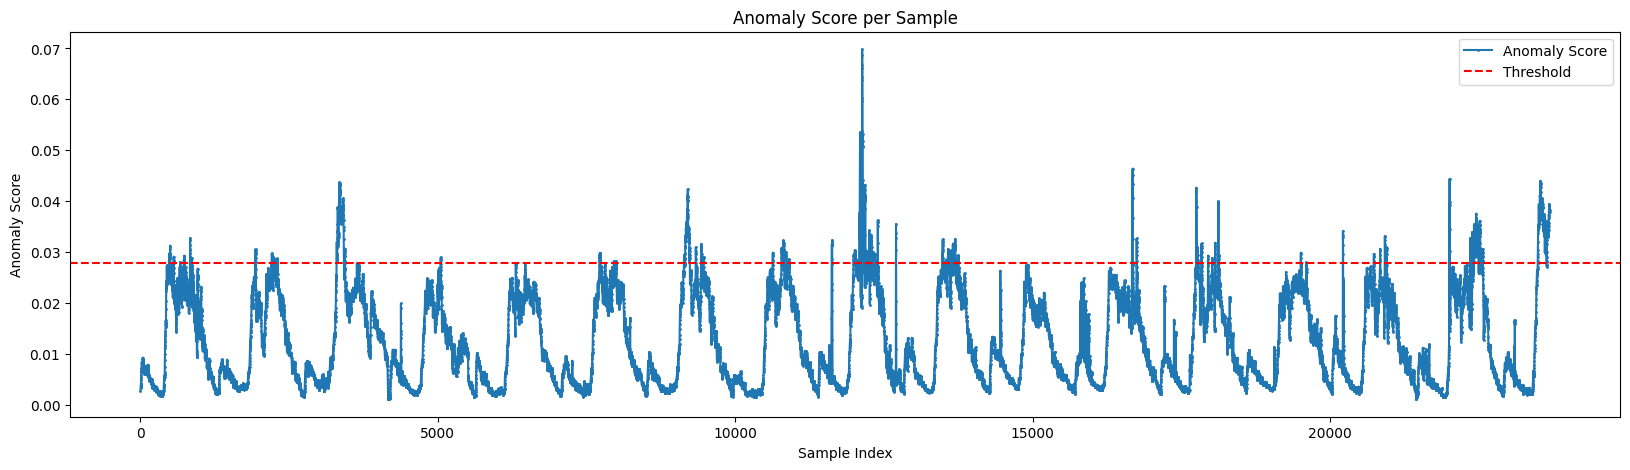

In [82]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.0253, Precision: 0.1535, Recall: 0.0138


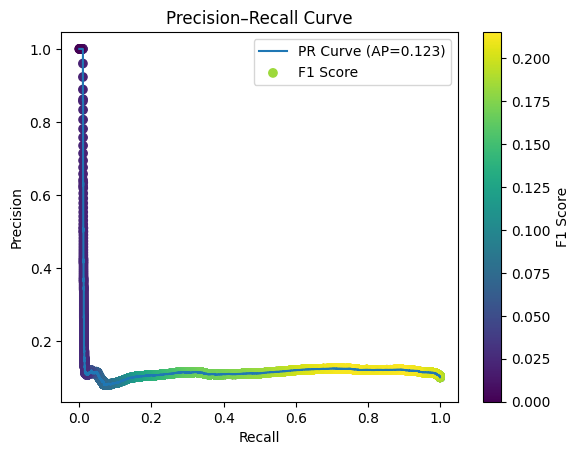

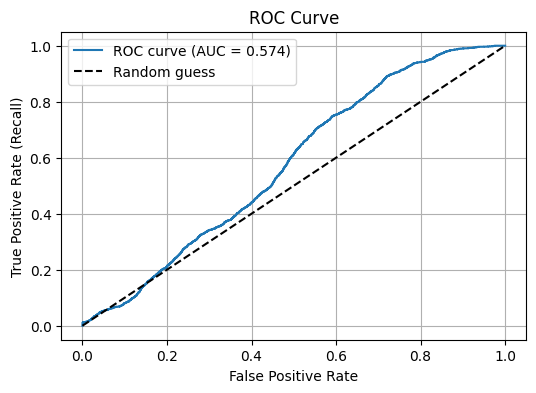

In [83]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.0369, Precision: 0.1877, Recall: 0.0204


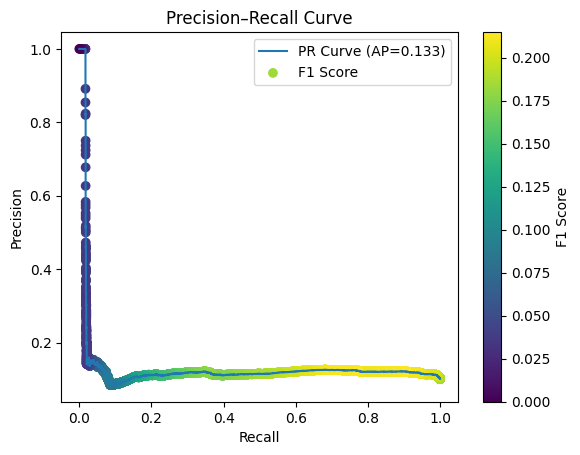

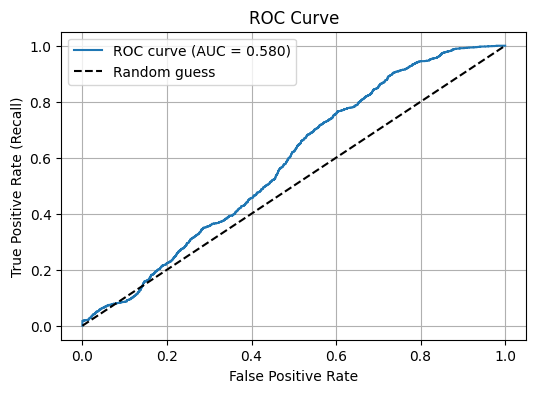

In [84]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [85]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 90), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.0822, Precision: 0.0827, Recall: 0.0817


In [86]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 90), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.0864, Precision: 0.0869, Recall: 0.0859


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0173, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0173, Epoch loss: 0.0167, Delta loss: 0.0007
Epoch 3/30
		 Previous Loss 0.0167, Epoch loss: 0.0106, Delta loss: 0.0061
Epoch 4/30
		 Previous Loss 0.0106, Epoch loss: 0.0088, Delta loss: 0.0018
Epoch 5/30
		 Previous Loss 0.0088, Epoch loss: 0.0083, Delta loss: 0.0004
Epoch 6/30
		 Previous Loss 0.0083, Epoch loss: 0.0082, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0083, Epoch loss: 0.0081, Delta loss: 0.0002
Epoch 8/30
		 Previous Loss 0.0081, Epoch loss: 0.0080, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0080, Epoch loss: 0.0079, Delta loss: 0.0000
Epoch 10/30
		 Previous Loss 0.0080, Epoch loss: 0.0081, Delta loss: -0.0001
Epoch 11/30
		 Previous Loss 0.0080, Epoch loss: 0.0079, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0080, Epoch loss: 0.0079, Delta loss: 0.0000

 max_err: 0.1625947207212448, min_err: 0.0011133395601063967


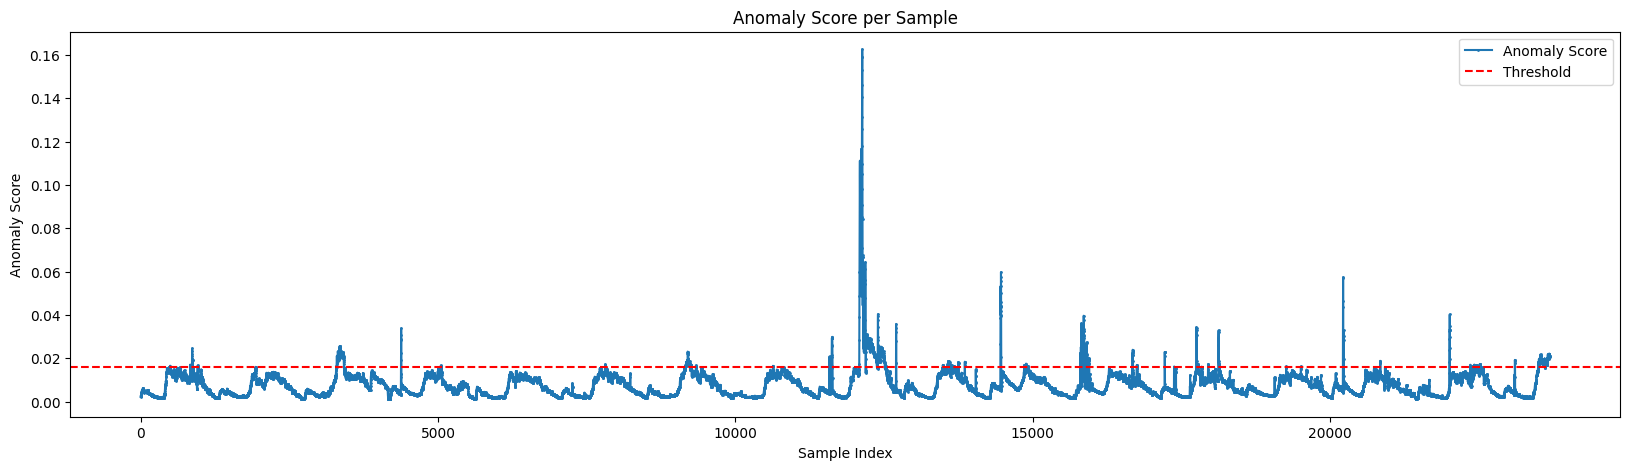

In [87]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.0900, Precision: 1.0000, Recall: 0.0471


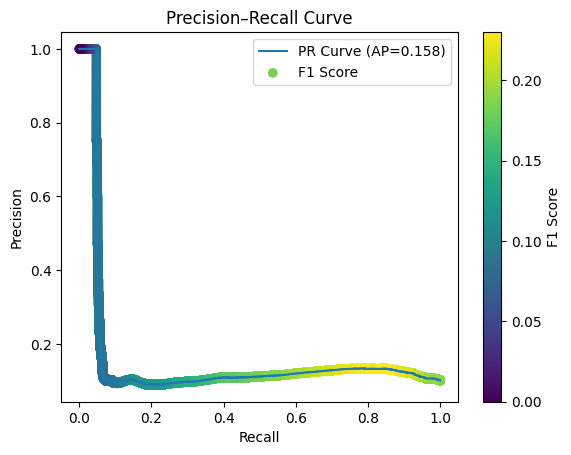

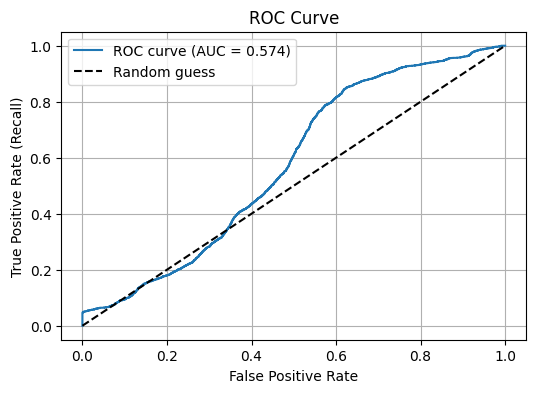

In [88]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1145, Precision: 0.9542, Recall: 0.0609


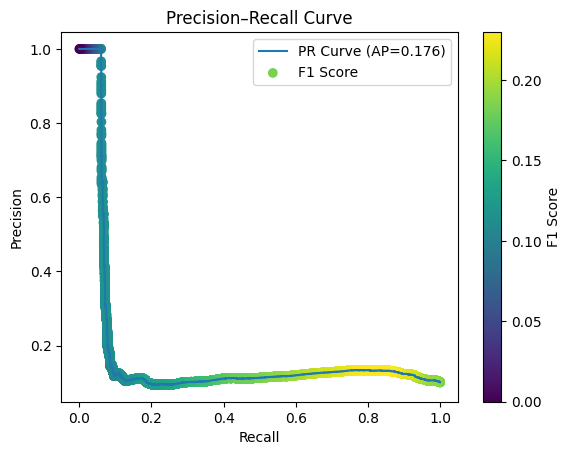

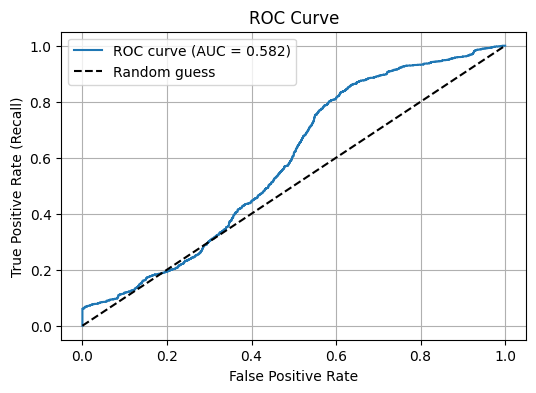

In [89]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [90]:
y_test_full.value_counts()

0
0    21299
1     2398
Name: count, dtype: int64

In [91]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 90), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.0948, Precision: 0.0954, Recall: 0.0942


In [92]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 90), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1166, Precision: 0.1173, Recall: 0.1159


<span style='color:red; font-size:60px'> Machine-1-8 </span>

In [93]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(1,8)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0024, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0024, Epoch loss: 0.0018, Delta loss: 0.0005
Epoch 3/30
		 Previous Loss 0.0018, Epoch loss: 0.0018, Delta loss: 0.0001
Epoch 4/30
		 Previous Loss 0.0018, Epoch loss: 0.0018, Delta loss: 0.0000
Epoch 5/30
		 Previous Loss 0.0018, Epoch loss: 0.0016, Delta loss: 0.0003
Epoch 6/30
		 Previous Loss 0.0016, Epoch loss: 0.0014, Delta loss: 0.0002
Epoch 7/30
		 Previous Loss 0.0014, Epoch loss: 0.0012, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0012, Epoch loss: 0.0012, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0012, Epoch loss: 0.0011, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0011, Epoch loss: 0.0011, Delta loss: 0.0000
Epoch 11/30
		 Previous Loss 0.0011, Epoch loss: 0.0010, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0011, Epoch loss: 0.0010, Delta loss: 0.0001
Epoch 13/30
		 Previous Loss 0.0010, Epoch loss: 0.0009, Delta loss: 0.0001
Epoch 14/30
		 Previous Los

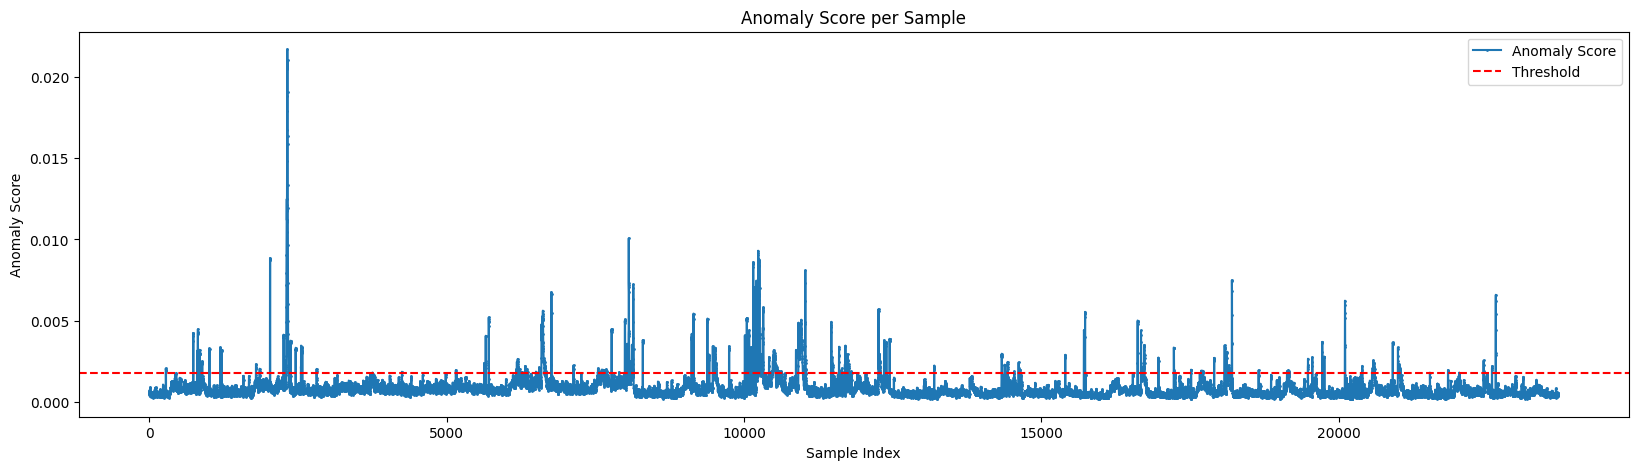

In [94]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.2325, Precision: 0.2141, Recall: 0.2543


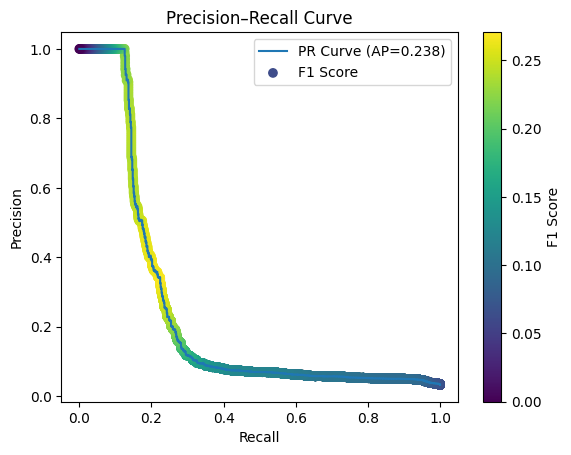

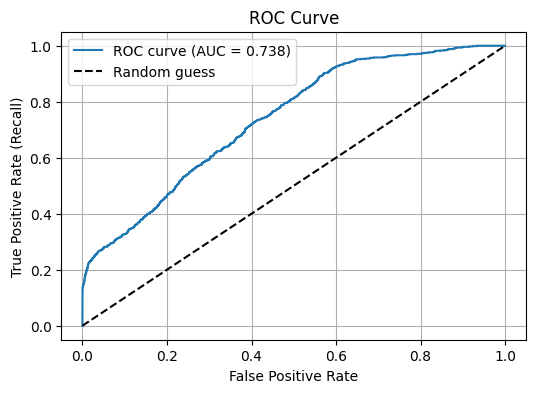

In [95]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.2420, Precision: 0.2059, Recall: 0.2936


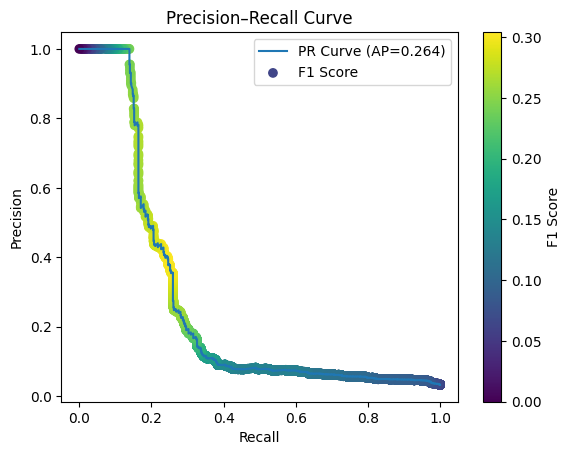

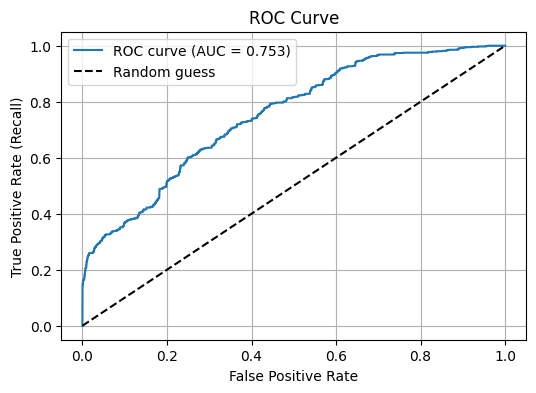

In [96]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [97]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 97), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.2456, Precision: 0.2546, Recall: 0.2372


In [98]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 97), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.2690, Precision: 0.2793, Recall: 0.2595


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0077, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0077, Epoch loss: 0.0046, Delta loss: 0.0031
Epoch 3/30
		 Previous Loss 0.0046, Epoch loss: 0.0024, Delta loss: 0.0022
Epoch 4/30
		 Previous Loss 0.0024, Epoch loss: 0.0020, Delta loss: 0.0004
Epoch 5/30
		 Previous Loss 0.0020, Epoch loss: 0.0018, Delta loss: 0.0002
Epoch 6/30
		 Previous Loss 0.0018, Epoch loss: 0.0017, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0018, Epoch loss: 0.0017, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0017, Epoch loss: 0.0018, Delta loss: -0.0001

 max_err: 0.022037716582417488, min_err: 0.0003514167619869113


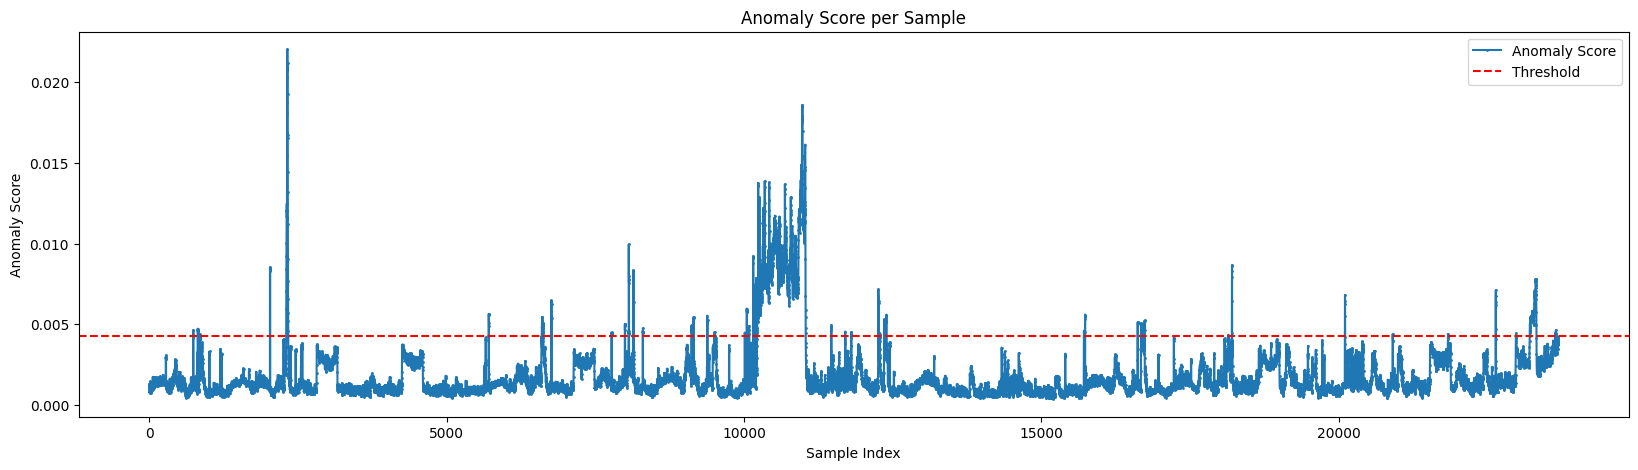

In [99]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.0590, Precision: 0.0349, Recall: 0.1900


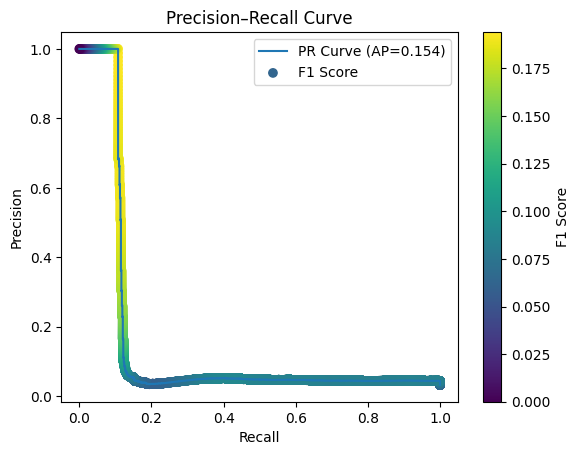

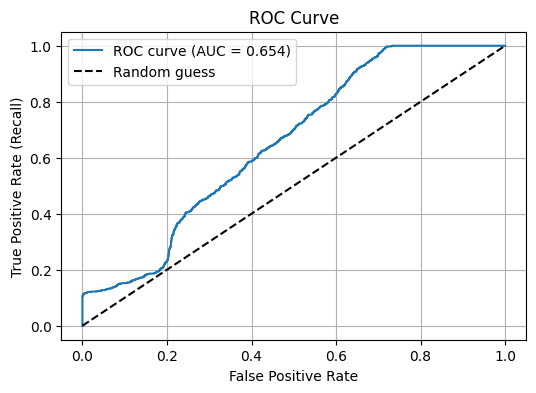

In [100]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.0633, Precision: 0.0373, Recall: 0.2110


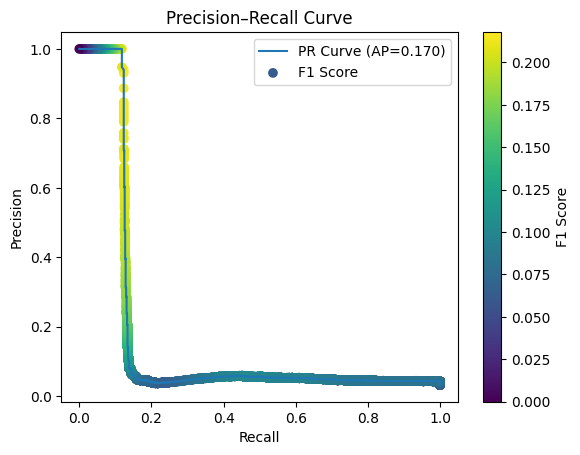

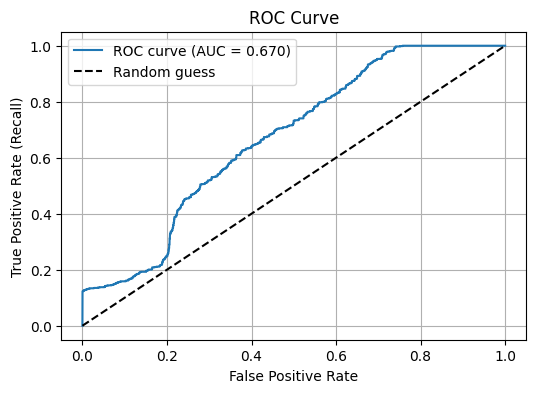

In [101]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [102]:
y_test_full.value_counts()

0
0    22936
1      763
Name: count, dtype: int64

In [103]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 97), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1262, Precision: 0.1308, Recall: 0.1219


In [104]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 97), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1384, Precision: 0.1435, Recall: 0.1337


<span style='color:red; font-size:60px'> Machine-2-1 </span>

In [105]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,1)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0258, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0258, Epoch loss: 0.0108, Delta loss: 0.0149
Epoch 3/30
		 Previous Loss 0.0108, Epoch loss: 0.0078, Delta loss: 0.0031
Epoch 4/30
		 Previous Loss 0.0078, Epoch loss: 0.0057, Delta loss: 0.0020
Epoch 5/30
		 Previous Loss 0.0057, Epoch loss: 0.0034, Delta loss: 0.0023
Epoch 6/30
		 Previous Loss 0.0034, Epoch loss: 0.0028, Delta loss: 0.0006
Epoch 7/30
		 Previous Loss 0.0028, Epoch loss: 0.0027, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0027, Epoch loss: 0.0027, Delta loss: -0.0000
Epoch 9/30
		 Previous Loss 0.0027, Epoch loss: 0.0025, Delta loss: 0.0002
Epoch 10/30
		 Previous Loss 0.0025, Epoch loss: 0.0022, Delta loss: 0.0003
Epoch 11/30
		 Previous Loss 0.0022, Epoch loss: 0.0020, Delta loss: 0.0003
Epoch 12/30
		 Previous Loss 0.0020, Epoch loss: 0.0018, Delta loss: 0.0002
Epoch 13/30
		 Previous Loss 0.0018, Epoch loss: 0.0017, Delta loss: 0.0001
Epoch 14/30
		 Previous Lo

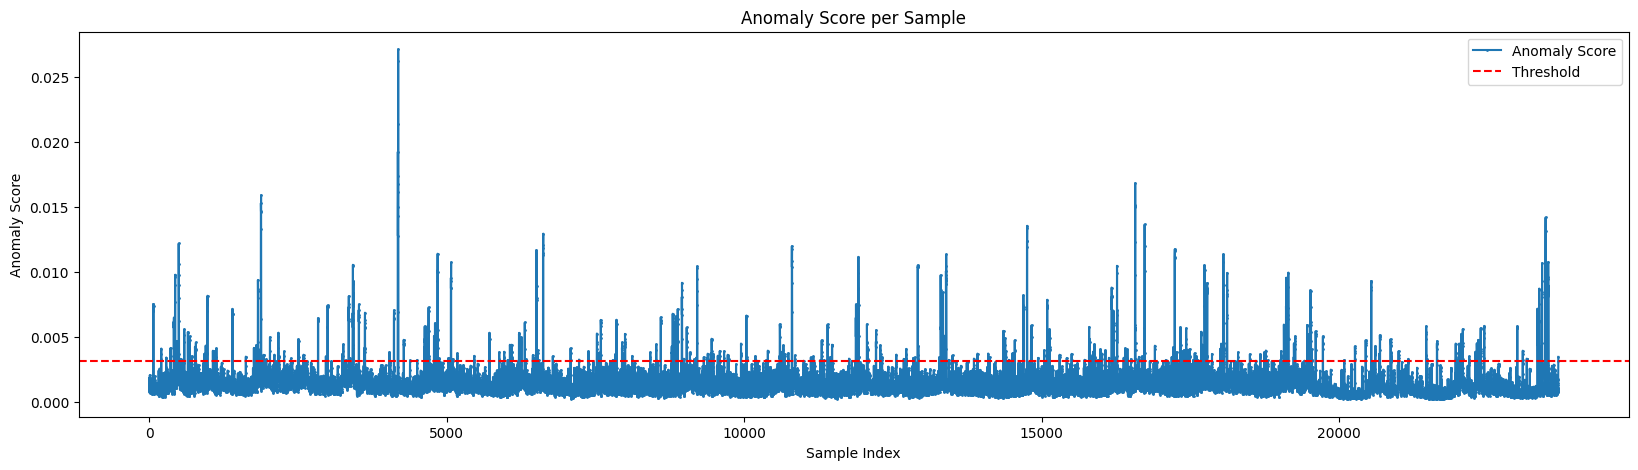

In [106]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.3228, Precision: 0.5839, Recall: 0.2231


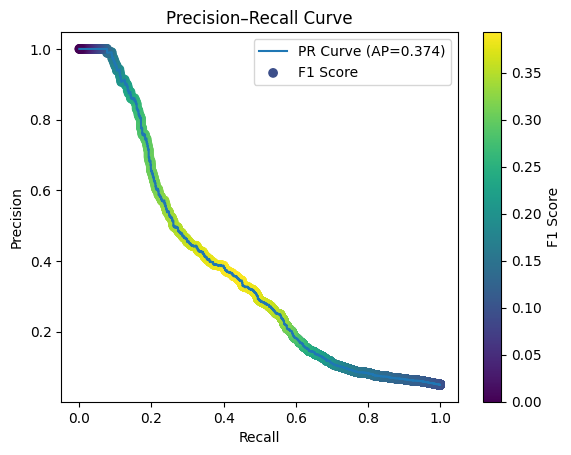

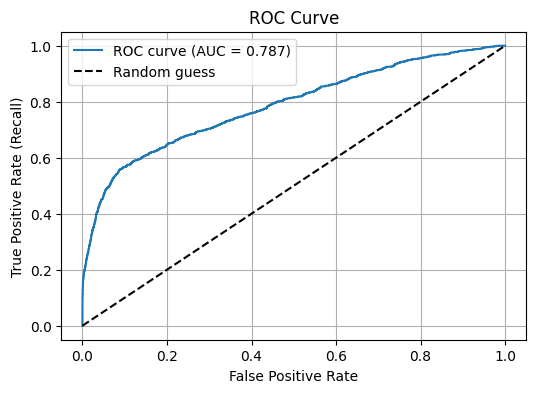

In [107]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.3845, Precision: 0.4497, Recall: 0.3359


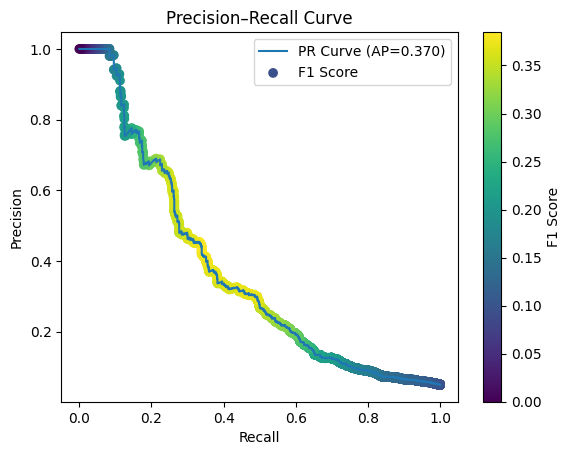

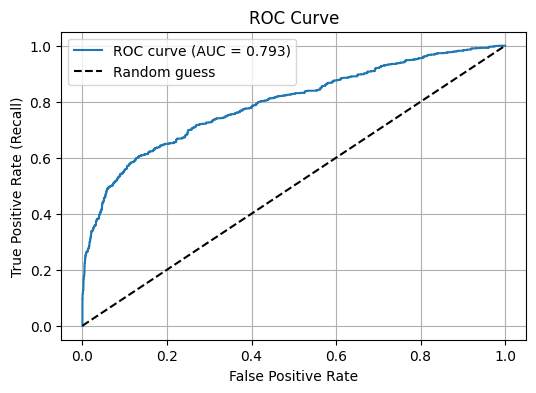

In [108]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [109]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3907, Precision: 0.3882, Recall: 0.3932


In [110]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3711, Precision: 0.3688, Recall: 0.3735


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0091, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0091, Epoch loss: 0.0089, Delta loss: 0.0002
Epoch 3/30
		 Previous Loss 0.0089, Epoch loss: 0.0075, Delta loss: 0.0014
Epoch 4/30
		 Previous Loss 0.0075, Epoch loss: 0.0048, Delta loss: 0.0026
Epoch 5/30
		 Previous Loss 0.0048, Epoch loss: 0.0044, Delta loss: 0.0004
Epoch 6/30
		 Previous Loss 0.0044, Epoch loss: 0.0043, Delta loss: 0.0002
Epoch 7/30
		 Previous Loss 0.0043, Epoch loss: 0.0042, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0043, Epoch loss: 0.0109, Delta loss: -0.0067

 max_err: 0.11300141364336014, min_err: 0.0020888797007501125


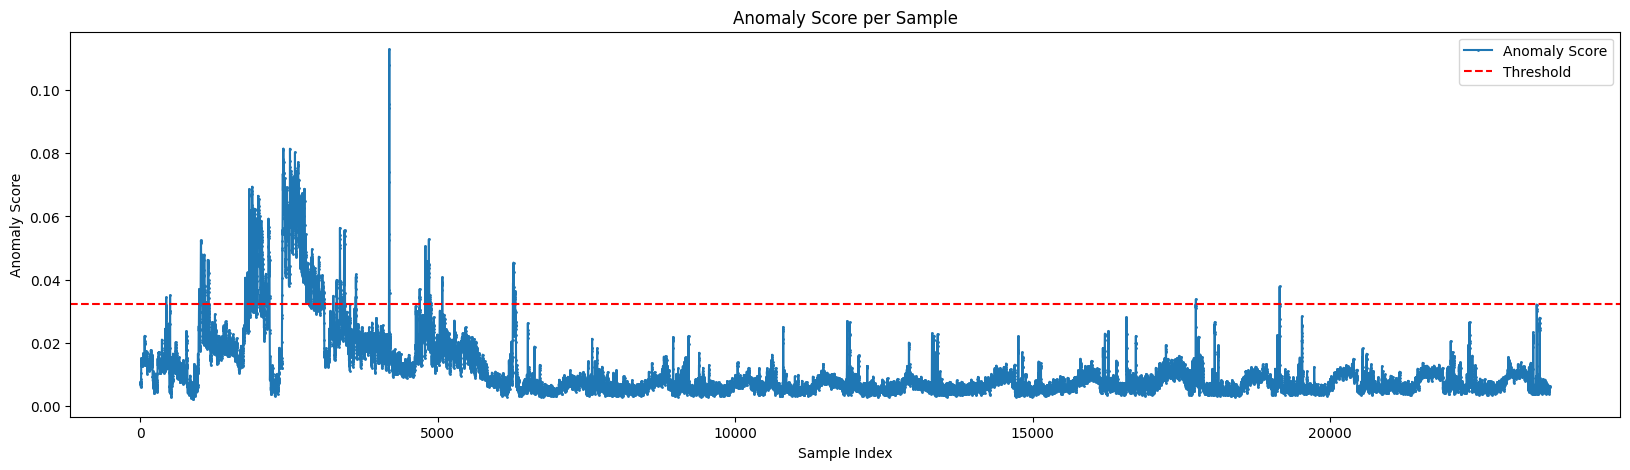

In [111]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.0203, Precision: 0.8571, Recall: 0.0103


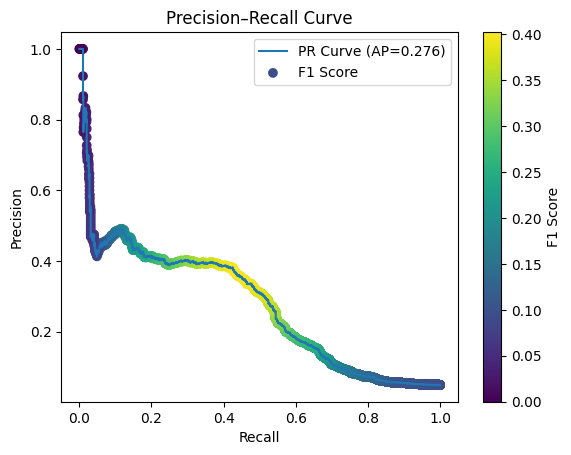

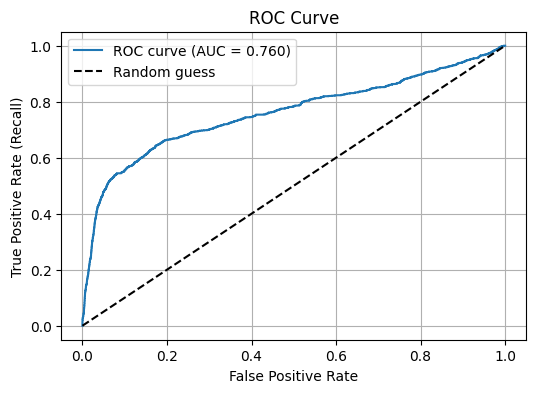

In [112]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.0414, Precision: 0.6757, Recall: 0.0214


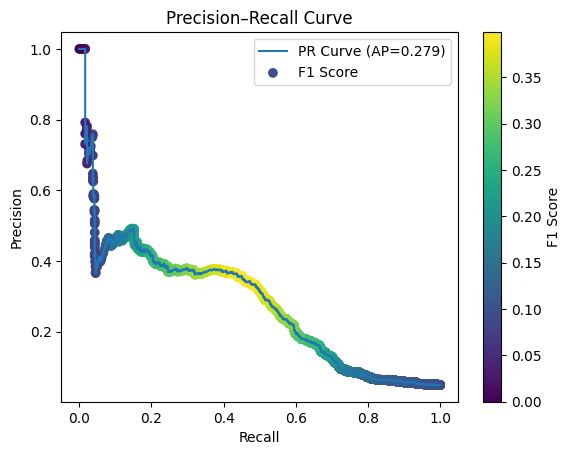

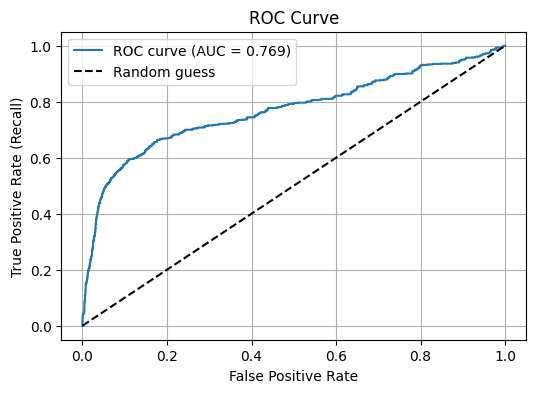

In [113]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [114]:
y_test_full.value_counts()

0
0    22524
1     1170
Name: count, dtype: int64

In [115]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3907, Precision: 0.3882, Recall: 0.3932


In [116]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3789, Precision: 0.3767, Recall: 0.3812


<span style='color:red; font-size:60px'> Machine-2-2 </span>

In [117]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,2)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0041, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0041, Epoch loss: 0.0028, Delta loss: 0.0013
Epoch 3/30
		 Previous Loss 0.0028, Epoch loss: 0.0024, Delta loss: 0.0004
Epoch 4/30
		 Previous Loss 0.0024, Epoch loss: 0.0023, Delta loss: 0.0001
Epoch 5/30
		 Previous Loss 0.0023, Epoch loss: 0.0023, Delta loss: 0.0000
Epoch 6/30
		 Previous Loss 0.0023, Epoch loss: 0.0023, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0023, Epoch loss: 0.0022, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0023, Epoch loss: 0.0022, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0022, Epoch loss: 0.0021, Delta loss: 0.0000
Epoch 10/30
		 Previous Loss 0.0022, Epoch loss: 0.0021, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0022, Epoch loss: 0.0021, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0022, Epoch loss: 0.0021, Delta loss: 0.0001

 max_err: 0.010639493353664875, min_err: 0.00016452853742521256


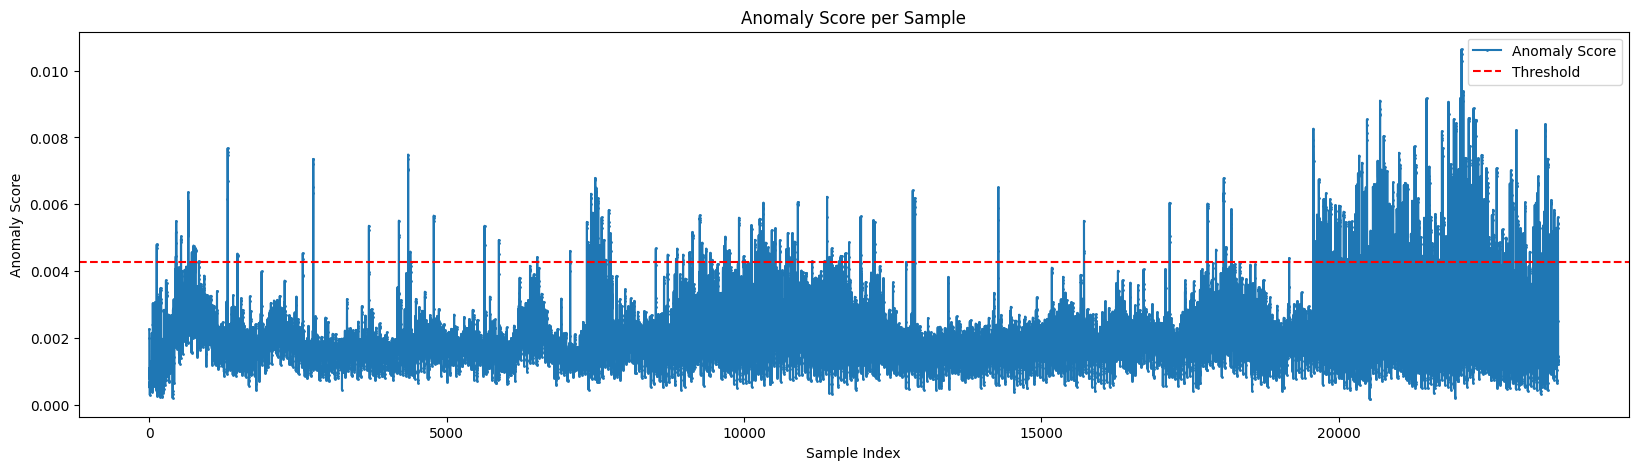

In [118]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.0881, Precision: 0.2319, Recall: 0.0544


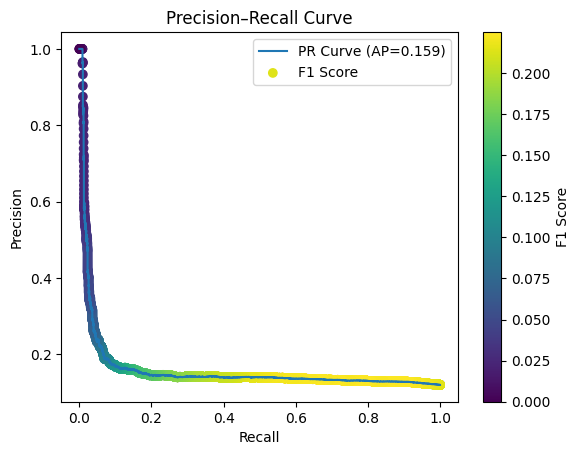

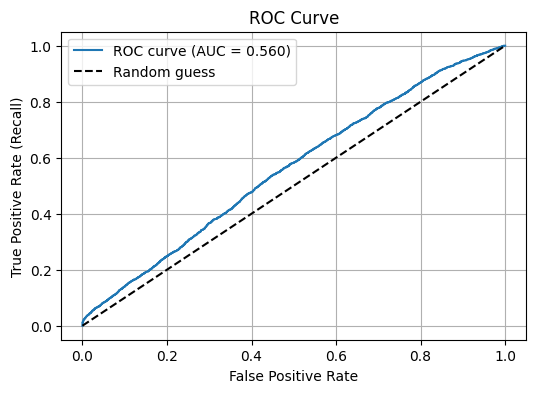

In [119]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1580, Precision: 0.1416, Recall: 0.1786


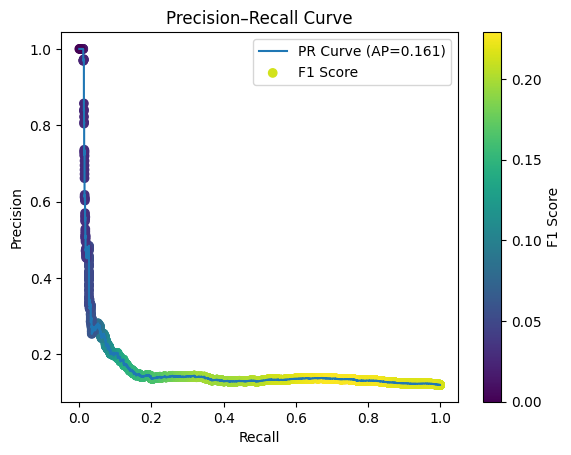

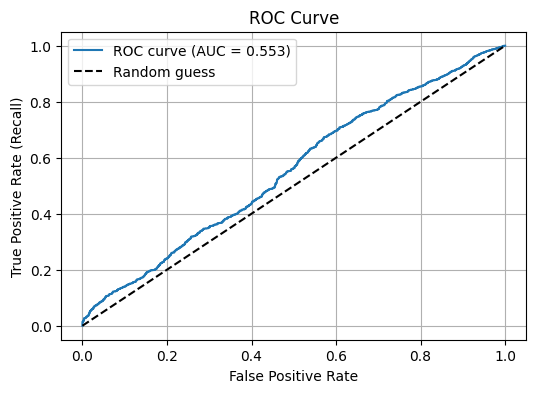

In [120]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [121]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 88), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1571, Precision: 0.1568, Recall: 0.1574


In [122]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 88), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.1505, Precision: 0.1502, Recall: 0.1507


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0073, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0073, Epoch loss: 0.0070, Delta loss: 0.0002
Epoch 3/30
		 Previous Loss 0.0070, Epoch loss: 0.0051, Delta loss: 0.0019
Epoch 4/30
		 Previous Loss 0.0051, Epoch loss: 0.0038, Delta loss: 0.0014
Epoch 5/30
		 Previous Loss 0.0038, Epoch loss: 0.0034, Delta loss: 0.0003
Epoch 6/30
		 Previous Loss 0.0034, Epoch loss: 0.0071, Delta loss: -0.0037

 max_err: 0.05985032021999359, min_err: 0.0008675512508489192


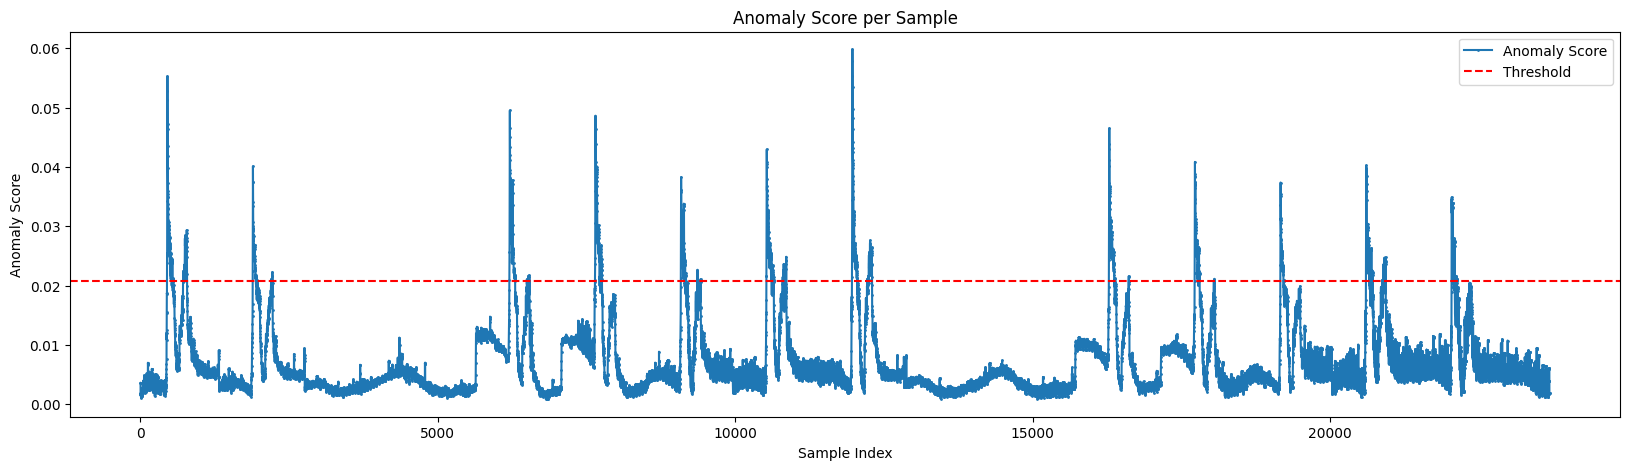

In [123]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.0753, Precision: 0.2998, Recall: 0.0431


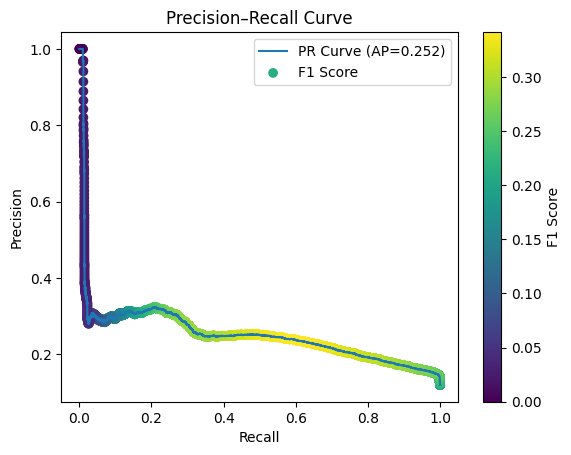

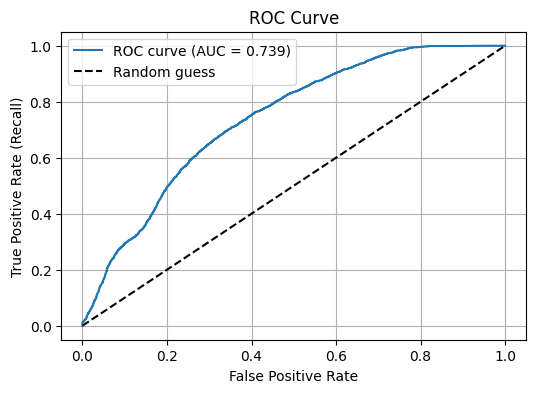

In [124]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1107, Precision: 0.2956, Recall: 0.0681


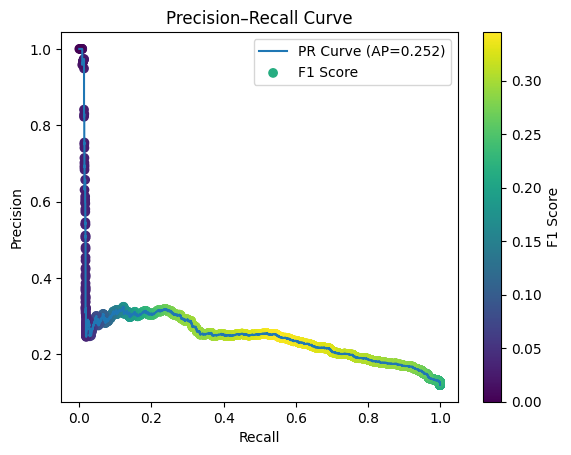

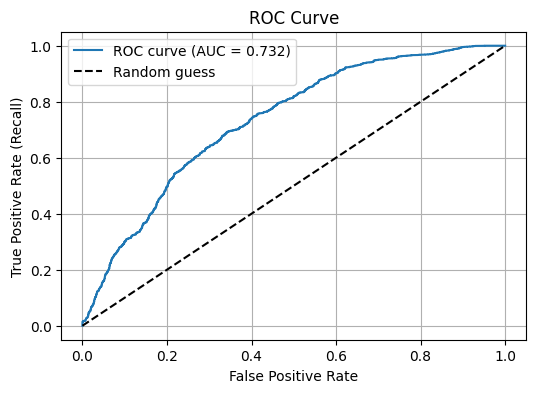

In [125]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [126]:
y_test_full.value_counts()

0
0    20867
1     2833
Name: count, dtype: int64

In [127]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 88), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.2871, Precision: 0.2866, Recall: 0.2877


In [128]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 88), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.2918, Precision: 0.2913, Recall: 0.2923


<span style='color:red; font-size:60px'> Machine-2-3 </span>

In [129]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,3)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0015, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0015, Epoch loss: 0.0015, Delta loss: 0.0001
Epoch 3/30
		 Previous Loss 0.0015, Epoch loss: 0.0015, Delta loss: 0.0001
Epoch 4/30
		 Previous Loss 0.0015, Epoch loss: 0.0014, Delta loss: 0.0002
Epoch 5/30
		 Previous Loss 0.0014, Epoch loss: 0.0011, Delta loss: 0.0003
Epoch 6/30
		 Previous Loss 0.0011, Epoch loss: 0.0008, Delta loss: 0.0002
Epoch 7/30
		 Previous Loss 0.0008, Epoch loss: 0.0008, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0008, Epoch loss: 0.0007, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0007, Epoch loss: 0.0007, Delta loss: 0.0000
Epoch 10/30
		 Previous Loss 0.0007, Epoch loss: 0.0007, Delta loss: 0.0000
Epoch 11/30
		 Previous Loss 0.0007, Epoch loss: 0.0007, Delta loss: 0.0000
Epoch 12/30
		 Previous Loss 0.0007, Epoch loss: 0.0007, Delta loss: 0.0000

 max_err: 0.16042807698249817, min_err: 7.362294127233326e-05


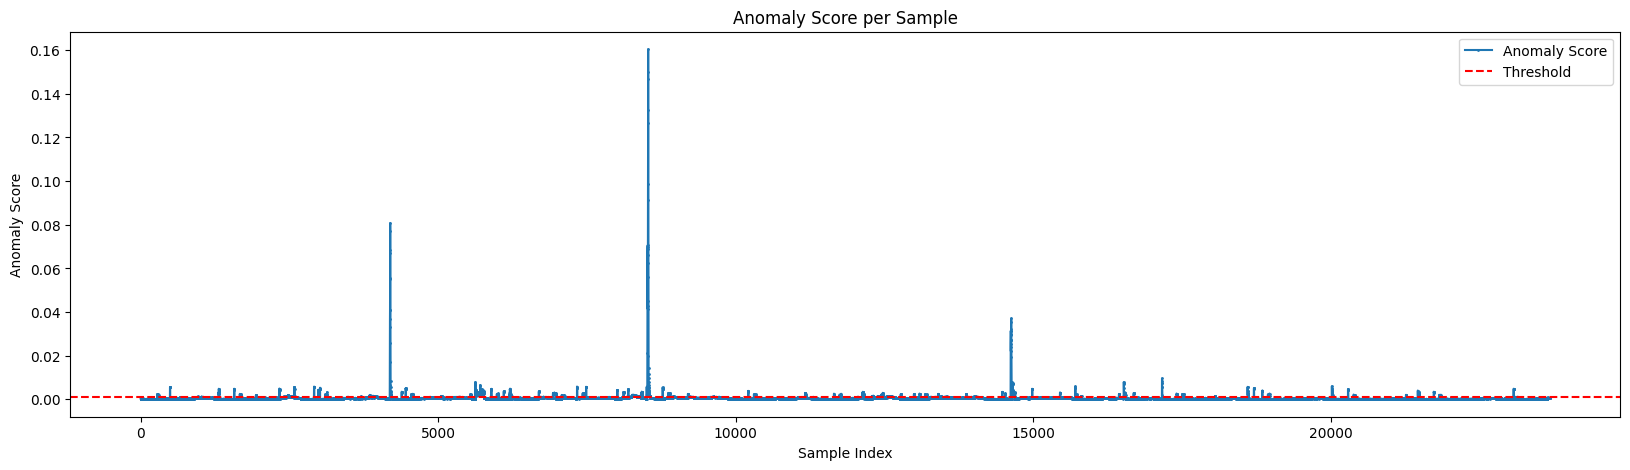

In [130]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.5434, Precision: 0.4788, Recall: 0.6283


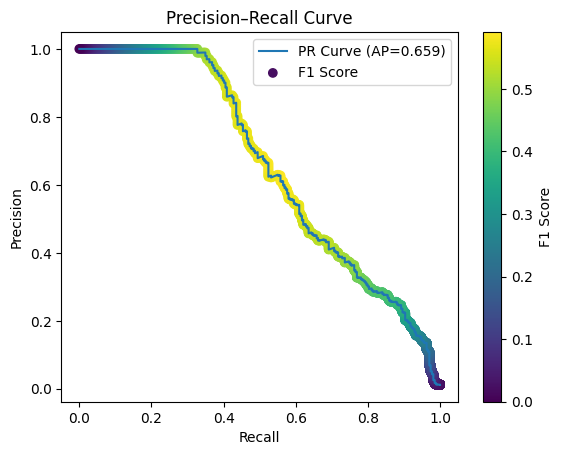

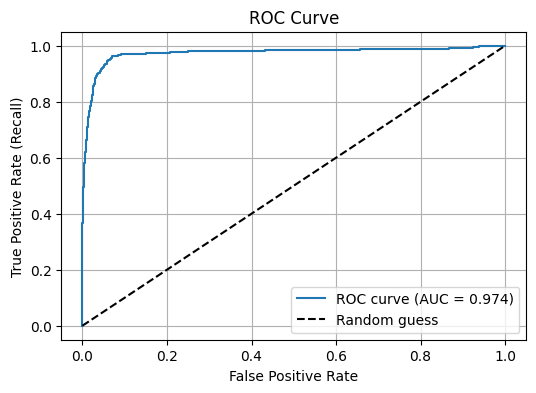

In [131]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.4370, Precision: 0.3121, Recall: 0.7286


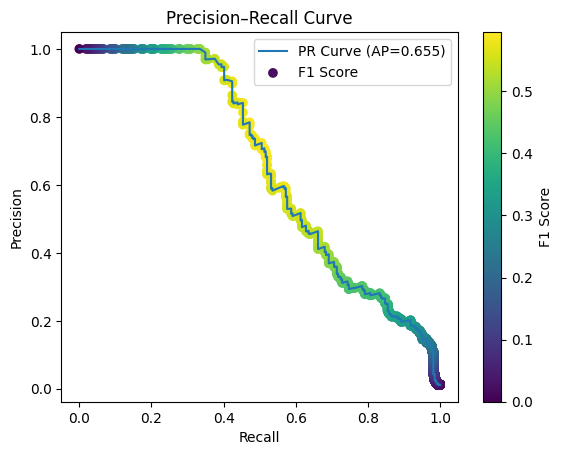

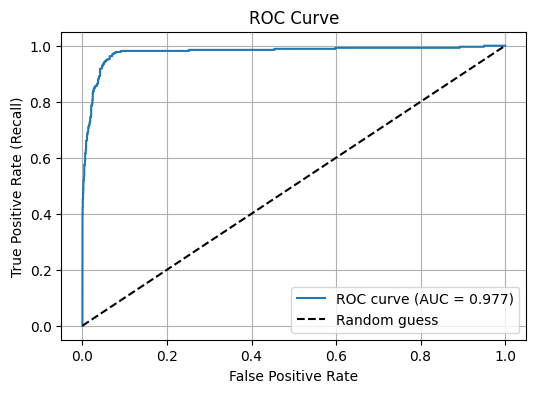

In [132]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [133]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.5889, Precision: 0.6287, Recall: 0.5539


In [134]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.5663, Precision: 0.6059, Recall: 0.5316


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0234, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0234, Epoch loss: 0.0234, Delta loss: -0.0000
Epoch 3/30
		 Previous Loss 0.0234, Epoch loss: 0.0234, Delta loss: -0.0000
Epoch 4/30
		 Previous Loss 0.0234, Epoch loss: 0.0234, Delta loss: -0.0000
Epoch 5/30
		 Previous Loss 0.0234, Epoch loss: 0.0234, Delta loss: -0.0000

 max_err: 0.2836986184120178, min_err: 0.01179258618503809


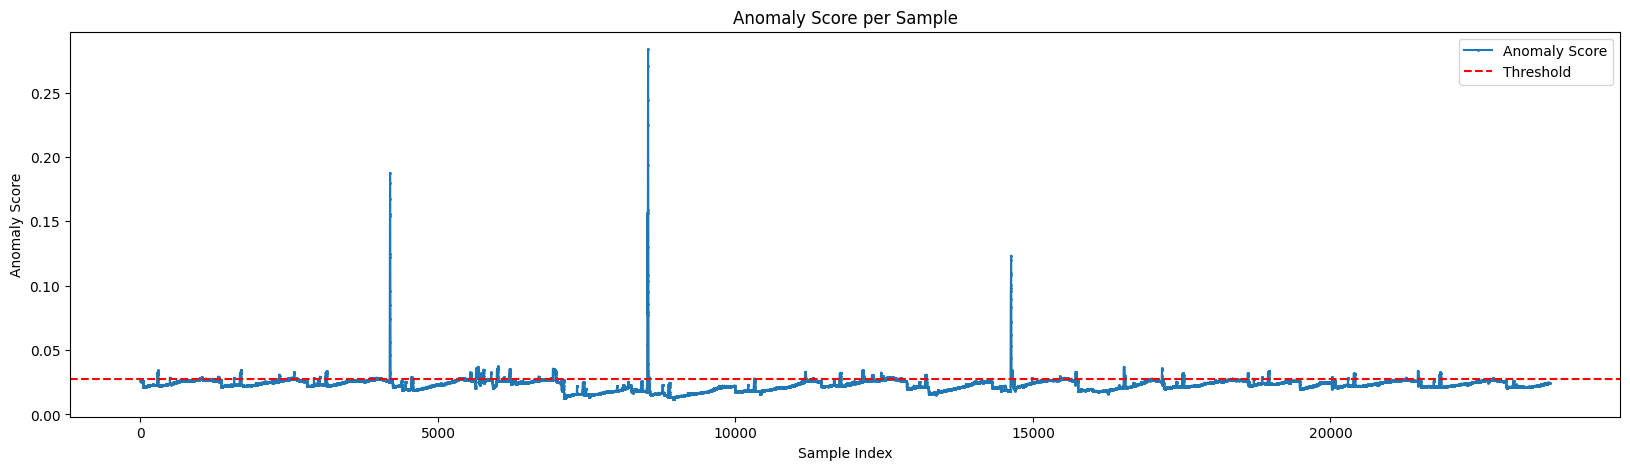

In [135]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.4444, Precision: 0.4504, Recall: 0.4387


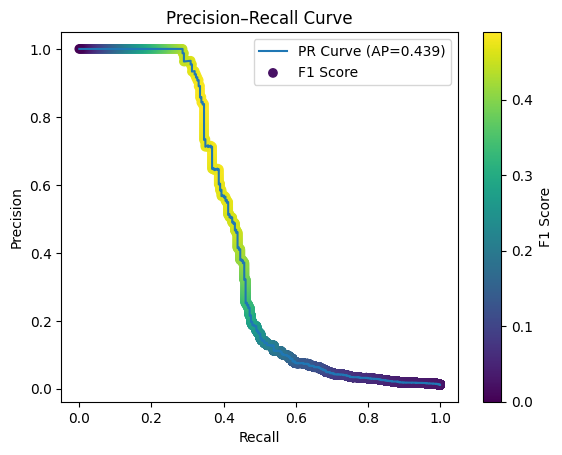

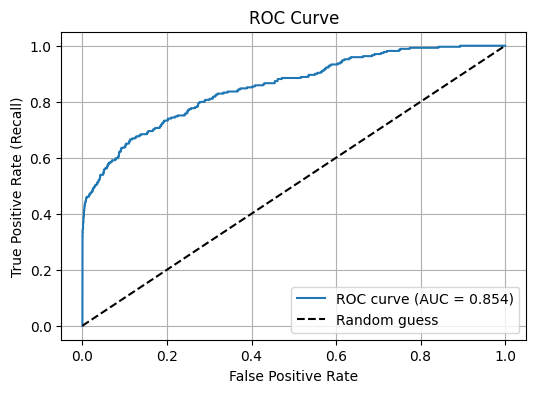

In [136]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.4086, Precision: 0.3318, Recall: 0.5316


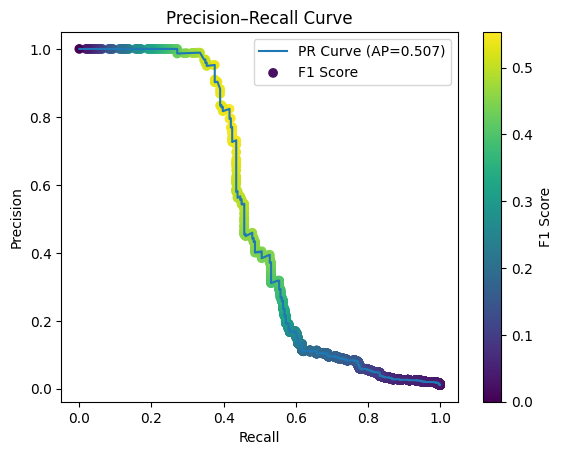

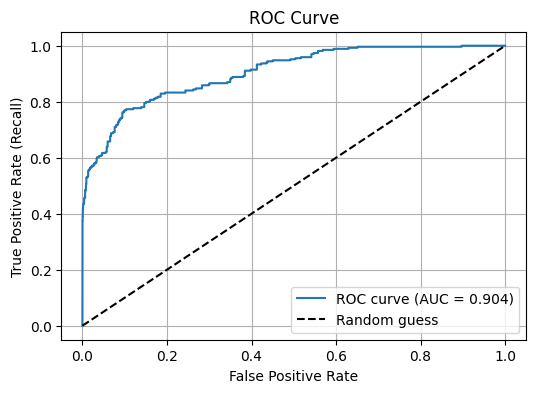

In [137]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [138]:
y_test_full.value_counts()

0
0    23420
1      269
Name: count, dtype: int64

In [139]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4545, Precision: 0.4852, Recall: 0.4275


In [140]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4900, Precision: 0.5279, Recall: 0.4572


<span style='color:red; font-size:60px'> Machine-2-4 </span>

In [141]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,4)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0055, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0055, Epoch loss: 0.0045, Delta loss: 0.0010
Epoch 3/30
		 Previous Loss 0.0045, Epoch loss: 0.0045, Delta loss: 0.0001
Epoch 4/30
		 Previous Loss 0.0045, Epoch loss: 0.0023, Delta loss: 0.0023
Epoch 5/30
		 Previous Loss 0.0023, Epoch loss: 0.0020, Delta loss: 0.0003
Epoch 6/30
		 Previous Loss 0.0020, Epoch loss: 0.0018, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0018, Epoch loss: 0.0017, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0017, Epoch loss: 0.0017, Delta loss: 0.0000
Epoch 9/30
		 Previous Loss 0.0017, Epoch loss: 0.0017, Delta loss: 0.0000
Epoch 10/30
		 Previous Loss 0.0017, Epoch loss: 0.0016, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0017, Epoch loss: 0.0014, Delta loss: 0.0003
Epoch 12/30
		 Previous Loss 0.0014, Epoch loss: 0.0013, Delta loss: 0.0002
Epoch 13/30
		 Previous Loss 0.0013, Epoch loss: 0.0012, Delta loss: 0.0001
Epoch 14/30
		 Previous Los

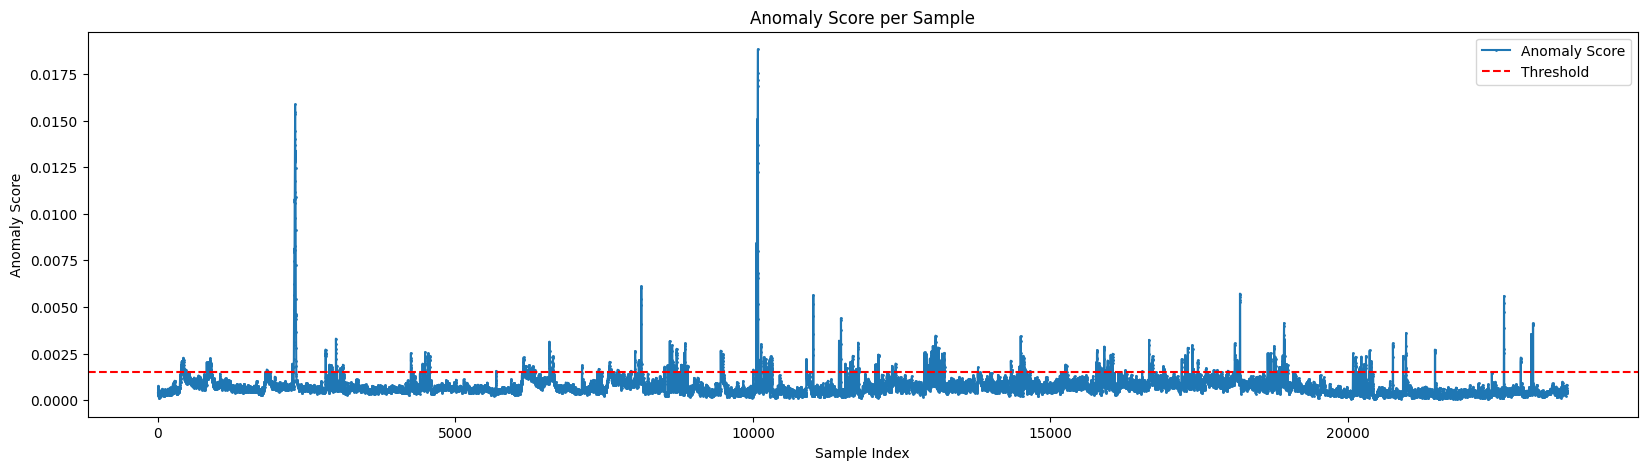

In [142]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.3667, Precision: 0.5544, Recall: 0.2739


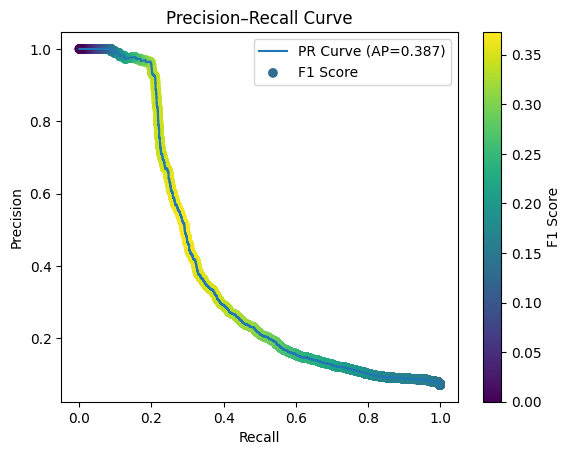

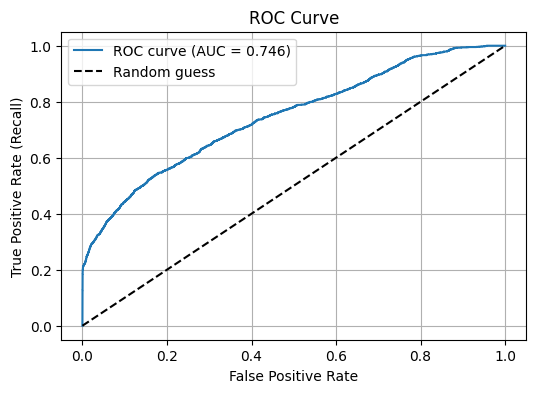

In [143]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.3847, Precision: 0.4004, Recall: 0.3701


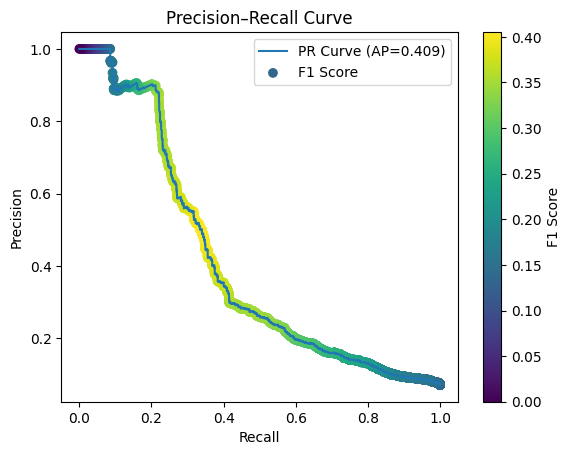

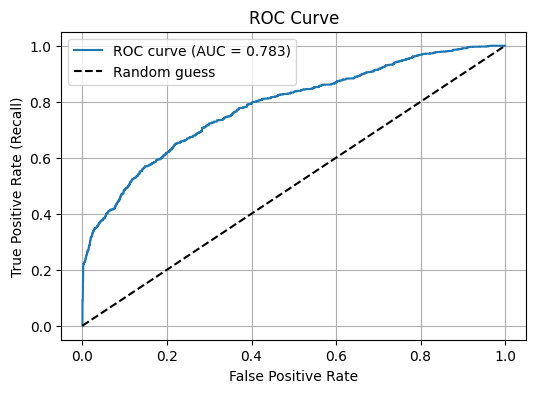

In [144]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [145]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 93), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3508, Precision: 0.3546, Recall: 0.3471


In [146]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 93), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3798, Precision: 0.3843, Recall: 0.3754


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0058, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0058, Epoch loss: 0.0055, Delta loss: 0.0004
Epoch 3/30
		 Previous Loss 0.0055, Epoch loss: 0.0026, Delta loss: 0.0029
Epoch 4/30
		 Previous Loss 0.0026, Epoch loss: 0.0021, Delta loss: 0.0005
Epoch 5/30
		 Previous Loss 0.0021, Epoch loss: 0.0019, Delta loss: 0.0001
Epoch 6/30
		 Previous Loss 0.0019, Epoch loss: 0.0019, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0019, Epoch loss: 0.0018, Delta loss: 0.0002
Epoch 8/30
		 Previous Loss 0.0018, Epoch loss: 0.0018, Delta loss: 0.0000
Epoch 9/30
		 Previous Loss 0.0018, Epoch loss: 0.0018, Delta loss: 0.0000
Epoch 10/30
		 Previous Loss 0.0018, Epoch loss: 0.0017, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0018, Epoch loss: 0.0017, Delta loss: 0.0001

 max_err: 0.04409133642911911, min_err: 0.0004670543421525508


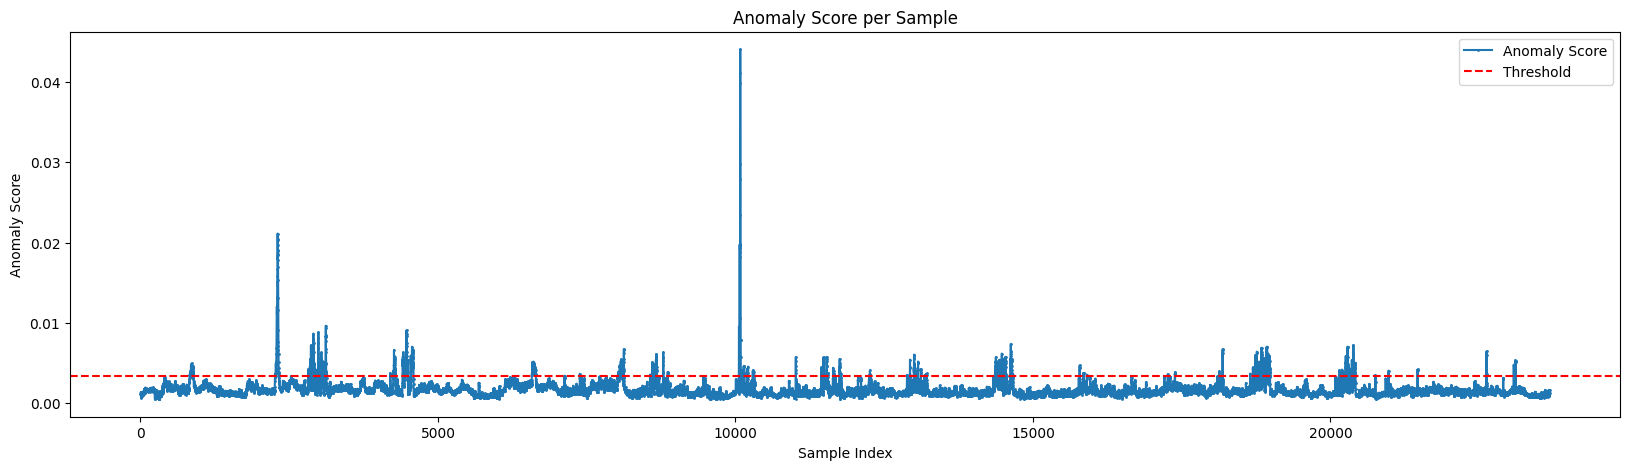

In [147]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.3035, Precision: 0.5810, Recall: 0.2054


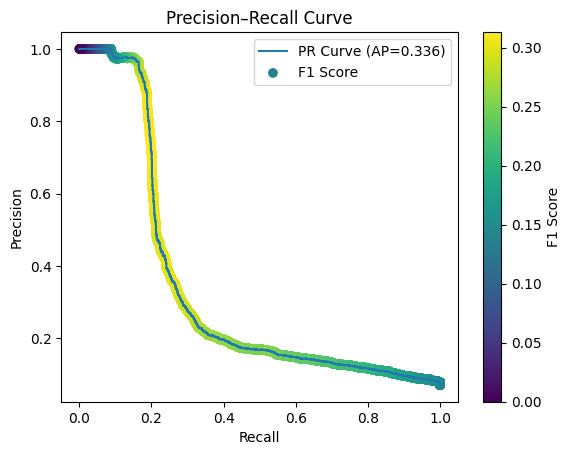

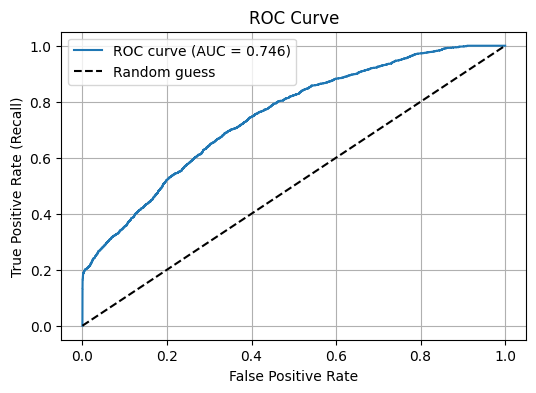

In [148]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.3110, Precision: 0.4980, Recall: 0.2261


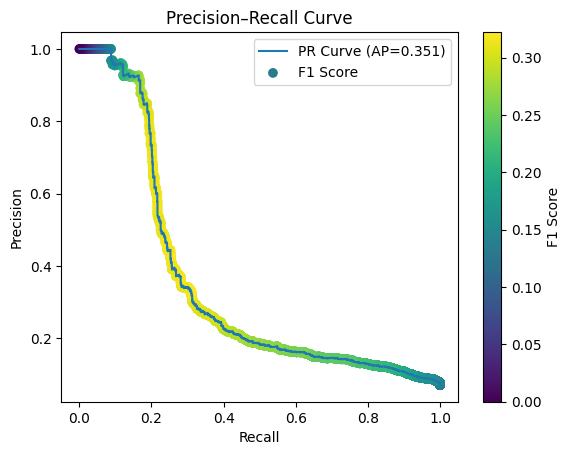

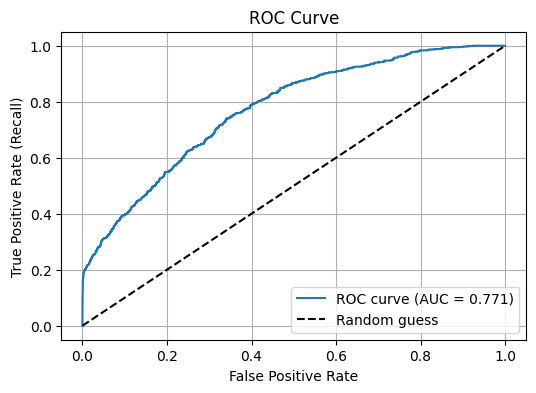

In [149]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [150]:
y_test_full.value_counts()

0
0    21995
1     1694
Name: count, dtype: int64

In [151]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 93), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.2906, Precision: 0.2937, Recall: 0.2875


In [152]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 93), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3148, Precision: 0.3186, Recall: 0.3111


<span style='color:red; font-size:60px'> Machine-2-5 </span>

In [153]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,5)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0093, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0093, Epoch loss: 0.0072, Delta loss: 0.0022
Epoch 3/30
		 Previous Loss 0.0072, Epoch loss: 0.0054, Delta loss: 0.0018
Epoch 4/30
		 Previous Loss 0.0054, Epoch loss: 0.0051, Delta loss: 0.0003
Epoch 5/30
		 Previous Loss 0.0051, Epoch loss: 0.0049, Delta loss: 0.0002
Epoch 6/30
		 Previous Loss 0.0049, Epoch loss: 0.0047, Delta loss: 0.0002
Epoch 7/30
		 Previous Loss 0.0047, Epoch loss: 0.0047, Delta loss: 0.0000
Epoch 8/30
		 Previous Loss 0.0047, Epoch loss: 0.0046, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0046, Epoch loss: 0.0045, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0046, Epoch loss: 0.0044, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0044, Epoch loss: 0.0044, Delta loss: 0.0000
Epoch 12/30
		 Previous Loss 0.0044, Epoch loss: 0.0043, Delta loss: 0.0002
Epoch 13/30
		 Previous Loss 0.0043, Epoch loss: 0.0022, Delta loss: 0.0020
Epoch 14/30
		 Previous Los

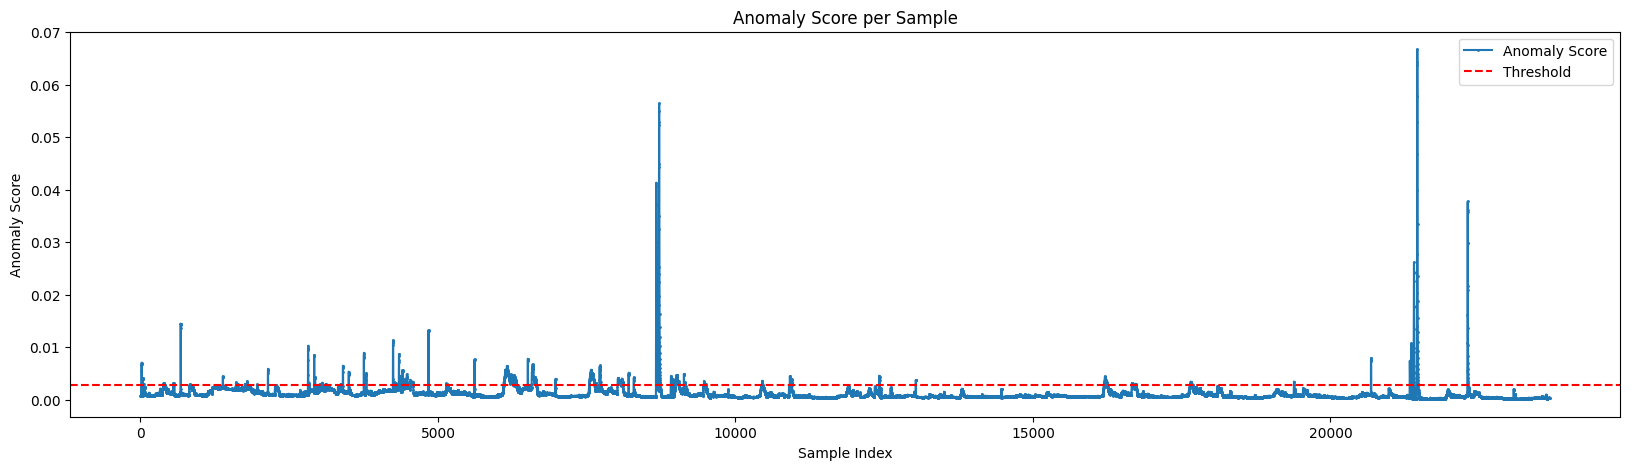

In [154]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.3865, Precision: 0.4611, Recall: 0.3327


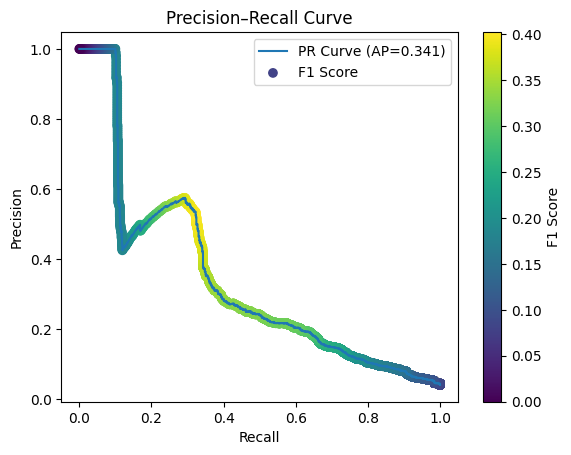

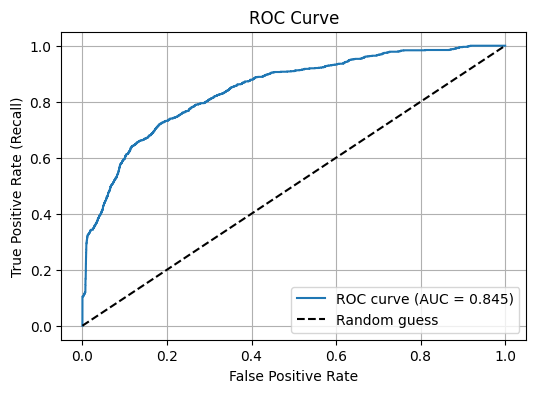

In [155]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.4141, Precision: 0.4281, Recall: 0.4010


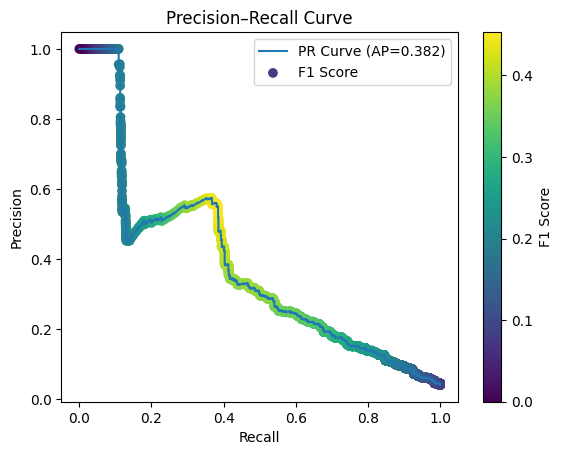

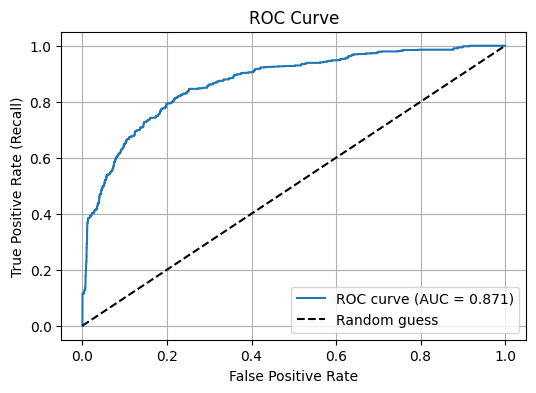

In [156]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [157]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3460, Precision: 0.3321, Recall: 0.3612


In [158]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3965, Precision: 0.3810, Recall: 0.4133


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0058, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0058, Epoch loss: 0.0058, Delta loss: 0.0001
Epoch 3/30
		 Previous Loss 0.0058, Epoch loss: 0.0058, Delta loss: 0.0001
Epoch 4/30
		 Previous Loss 0.0058, Epoch loss: 0.0055, Delta loss: 0.0004
Epoch 5/30
		 Previous Loss 0.0055, Epoch loss: 0.0035, Delta loss: 0.0020
Epoch 6/30
		 Previous Loss 0.0035, Epoch loss: 0.0028, Delta loss: 0.0006
Epoch 7/30
		 Previous Loss 0.0028, Epoch loss: 0.0025, Delta loss: 0.0003
Epoch 8/30
		 Previous Loss 0.0025, Epoch loss: 0.0021, Delta loss: 0.0004
Epoch 9/30
		 Previous Loss 0.0021, Epoch loss: 0.0018, Delta loss: 0.0003
Epoch 10/30
		 Previous Loss 0.0018, Epoch loss: 0.0017, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0017, Epoch loss: 0.0016, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0016, Epoch loss: 0.0016, Delta loss: -0.0001

 max_err: 0.08895255625247955, min_err: 0.00012952773249708116


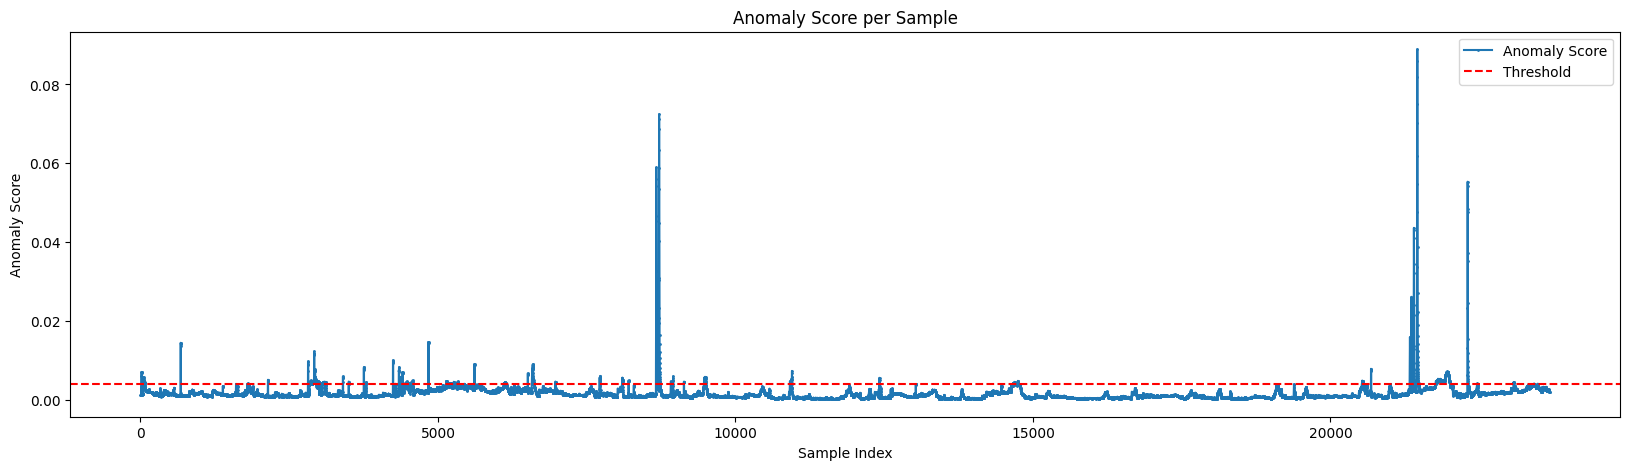

In [159]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.3402, Precision: 0.3190, Recall: 0.3643


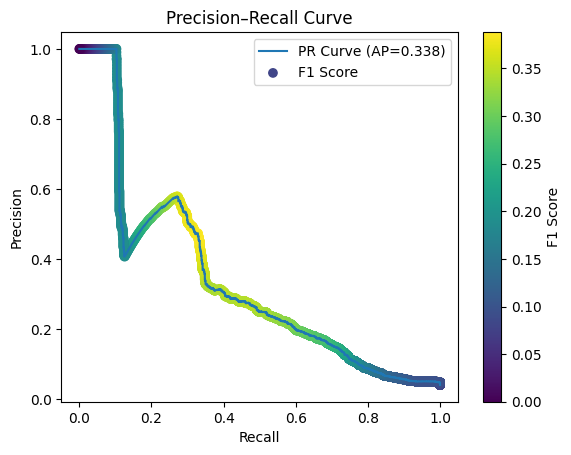

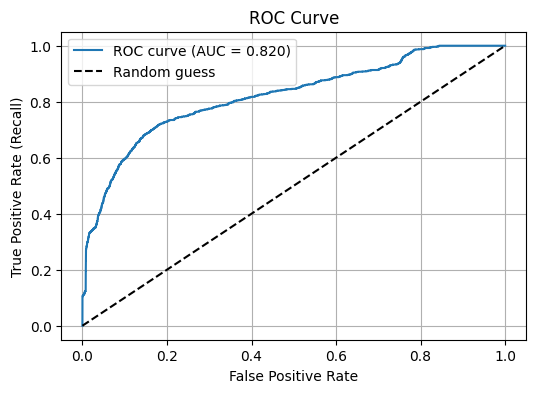

In [160]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.3790, Precision: 0.3258, Recall: 0.4531


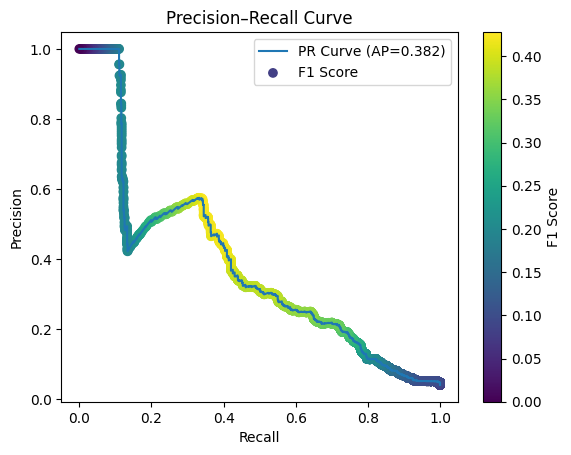

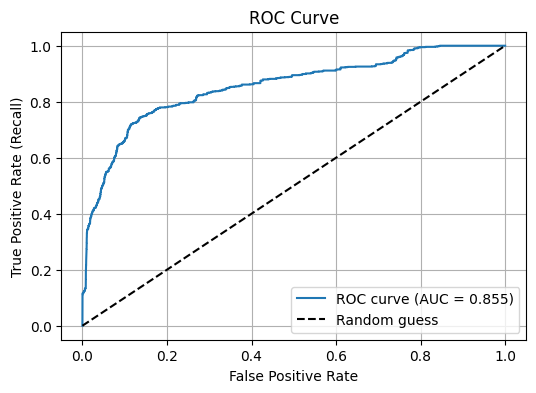

In [161]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [162]:
y_test_full.value_counts()

0
0    22709
1      980
Name: count, dtype: int64

In [163]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3402, Precision: 0.3265, Recall: 0.3551


In [164]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4027, Precision: 0.3865, Recall: 0.4204


<span style='color:red; font-size:60px'> Machine-2-6 </span>

In [165]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,6)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0031, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0031, Epoch loss: 0.0012, Delta loss: 0.0019
Epoch 3/30
		 Previous Loss 0.0012, Epoch loss: 0.0011, Delta loss: 0.0001
Epoch 4/30
		 Previous Loss 0.0012, Epoch loss: 0.0010, Delta loss: 0.0002
Epoch 5/30
		 Previous Loss 0.0010, Epoch loss: 0.0009, Delta loss: 0.0001
Epoch 6/30
		 Previous Loss 0.0010, Epoch loss: 0.0009, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0009, Epoch loss: 0.0009, Delta loss: 0.0000
Epoch 8/30
		 Previous Loss 0.0009, Epoch loss: 0.0007, Delta loss: 0.0002
Epoch 9/30
		 Previous Loss 0.0007, Epoch loss: 0.0007, Delta loss: 0.0000
Epoch 10/30
		 Previous Loss 0.0007, Epoch loss: 0.0007, Delta loss: 0.0000
Epoch 11/30
		 Previous Loss 0.0007, Epoch loss: 0.0006, Delta loss: 0.0000
Epoch 12/30
		 Previous Loss 0.0007, Epoch loss: 0.0006, Delta loss: 0.0000

 max_err: 0.0067548854276537895, min_err: 4.15452741435729e-05


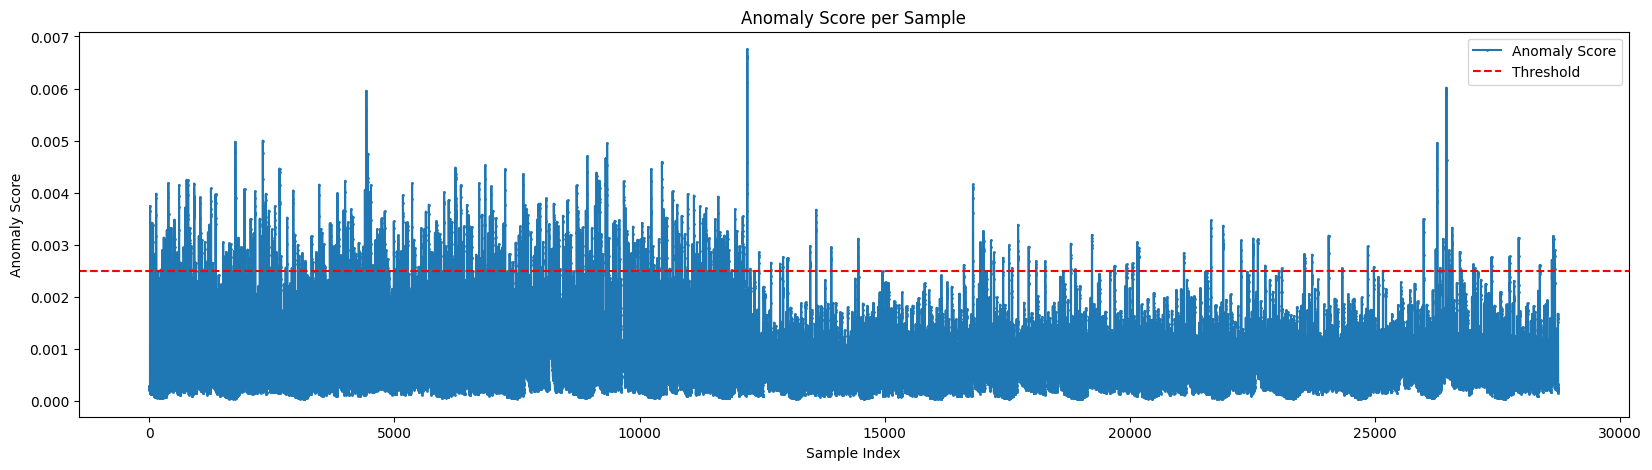

In [166]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.1670, Precision: 0.0950, Recall: 0.6934


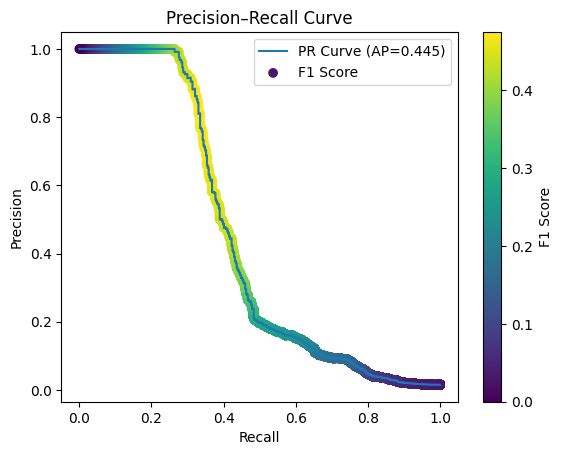

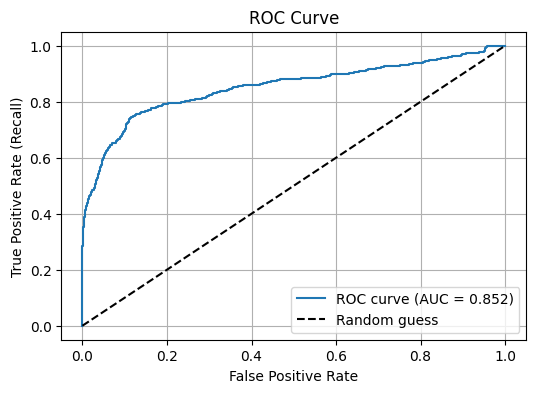

In [167]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1529, Precision: 0.0854, Recall: 0.7241


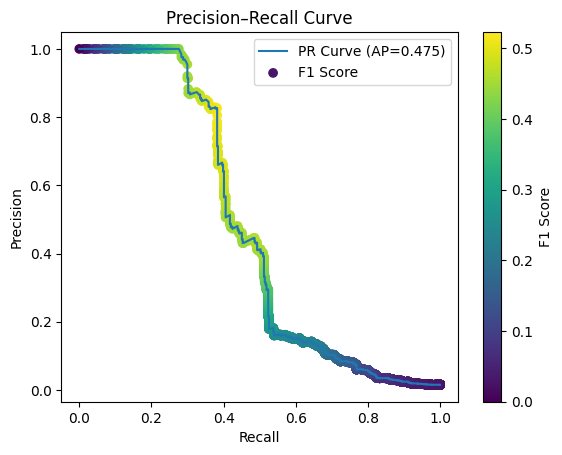

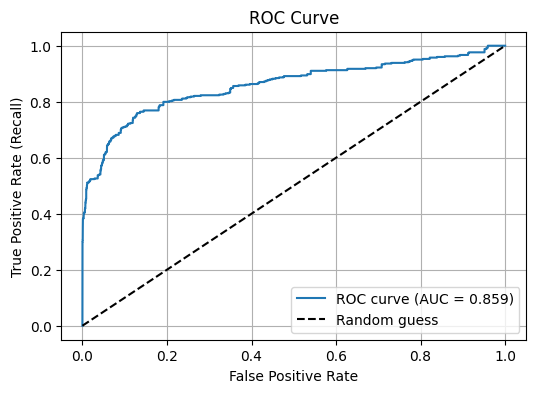

In [168]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [169]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4211, Precision: 0.4176, Recall: 0.4245


In [170]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4484, Precision: 0.4463, Recall: 0.4505


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0223, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0223, Epoch loss: 0.0192, Delta loss: 0.0031
Epoch 3/30
		 Previous Loss 0.0192, Epoch loss: 0.0025, Delta loss: 0.0167
Epoch 4/30
		 Previous Loss 0.0025, Epoch loss: 0.0015, Delta loss: 0.0010
Epoch 5/30
		 Previous Loss 0.0015, Epoch loss: 0.0013, Delta loss: 0.0002
Epoch 6/30
		 Previous Loss 0.0013, Epoch loss: 0.0013, Delta loss: -0.0001

 max_err: 0.00879949051886797, min_err: 0.00022048722894396633


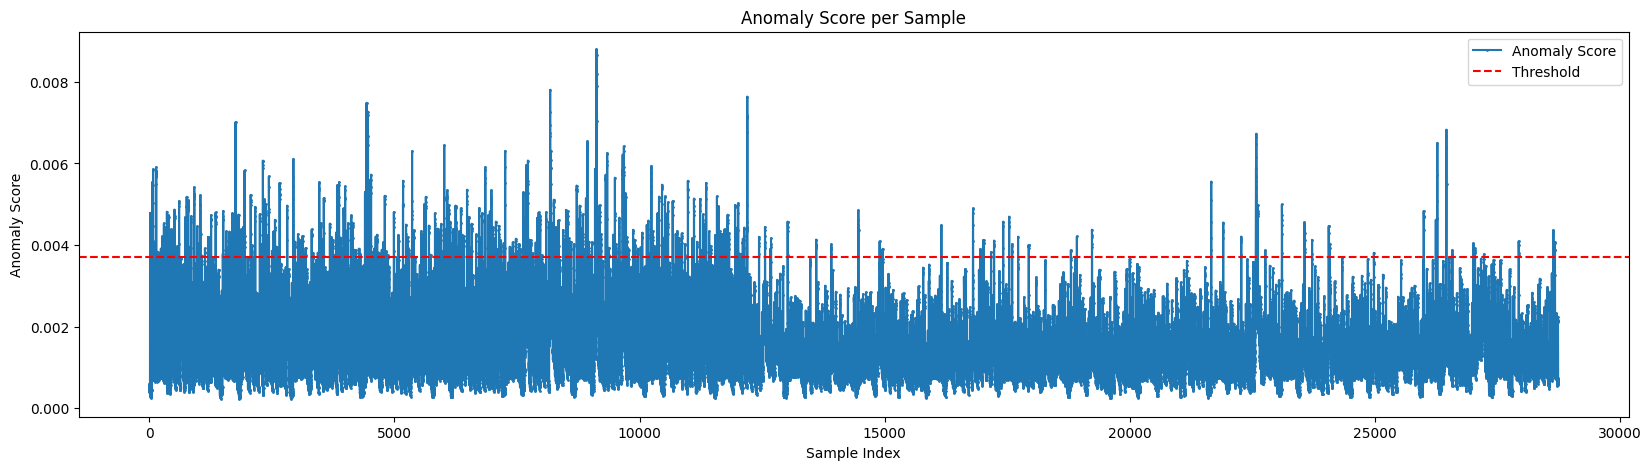

In [171]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.1722, Precision: 0.0987, Recall: 0.6769


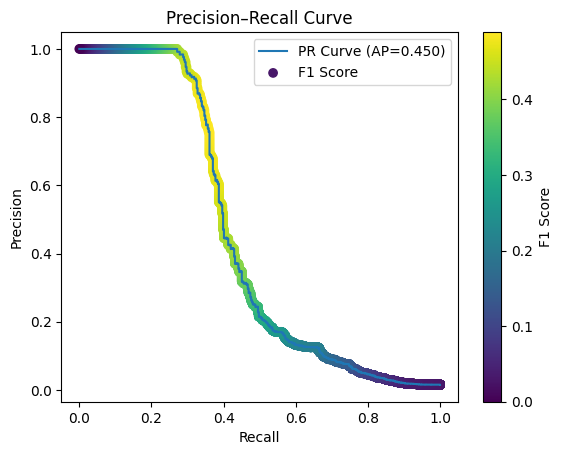

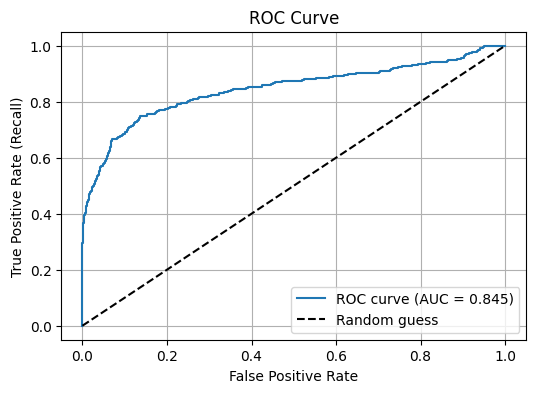

In [172]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1596, Precision: 0.0899, Recall: 0.7099


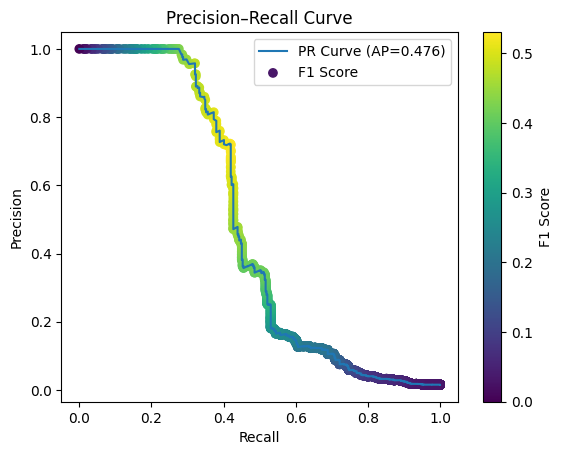

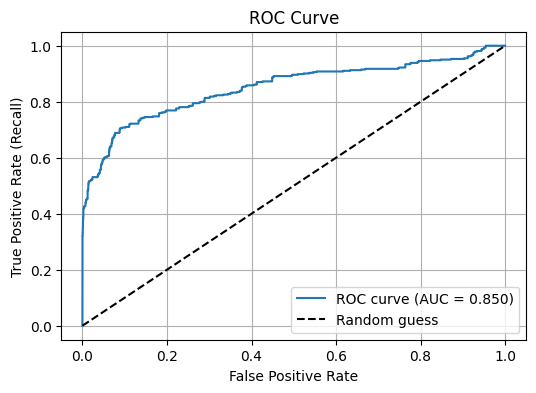

In [173]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [174]:
y_test_full.value_counts()

0
0    28319
1      424
Name: count, dtype: int64

In [175]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4164, Precision: 0.4130, Recall: 0.4198


In [176]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.4444, Precision: 0.4408, Recall: 0.4481


<span style='color:red; font-size:60px'> Machine-2-7 </span>

In [177]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,7)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0059, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0059, Epoch loss: 0.0038, Delta loss: 0.0021
Epoch 3/30
		 Previous Loss 0.0038, Epoch loss: 0.0036, Delta loss: 0.0002
Epoch 4/30
		 Previous Loss 0.0036, Epoch loss: 0.0035, Delta loss: 0.0001
Epoch 5/30
		 Previous Loss 0.0036, Epoch loss: 0.0034, Delta loss: 0.0002
Epoch 6/30
		 Previous Loss 0.0034, Epoch loss: 0.0033, Delta loss: 0.0001
Epoch 7/30
		 Previous Loss 0.0033, Epoch loss: 0.0021, Delta loss: 0.0012
Epoch 8/30
		 Previous Loss 0.0021, Epoch loss: 0.0020, Delta loss: 0.0002
Epoch 9/30
		 Previous Loss 0.0020, Epoch loss: 0.0019, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0019, Epoch loss: 0.0018, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0019, Epoch loss: 0.0017, Delta loss: 0.0002
Epoch 12/30
		 Previous Loss 0.0017, Epoch loss: 0.0017, Delta loss: 0.0000
Epoch 13/30
		 Previous Loss 0.0017, Epoch loss: 0.0018, Delta loss: -0.0001

 max_err: 0.0792934298515

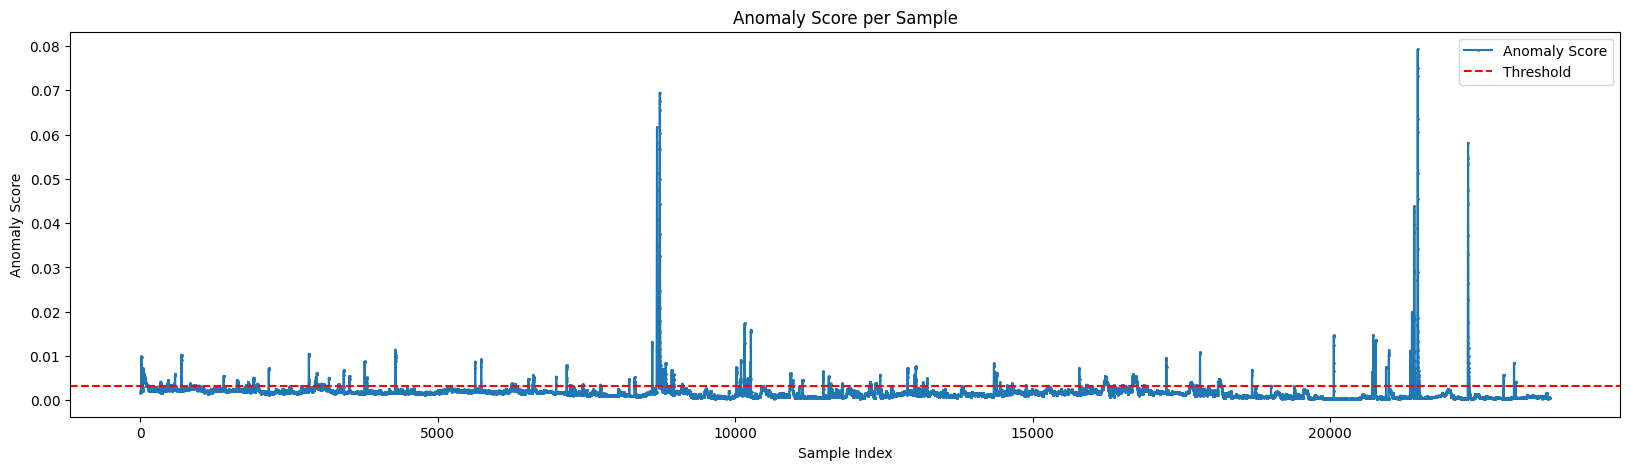

In [178]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.7237, Precision: 0.6180, Recall: 0.8729


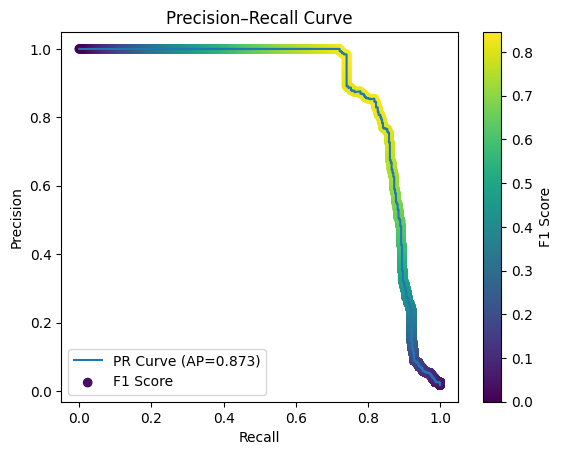

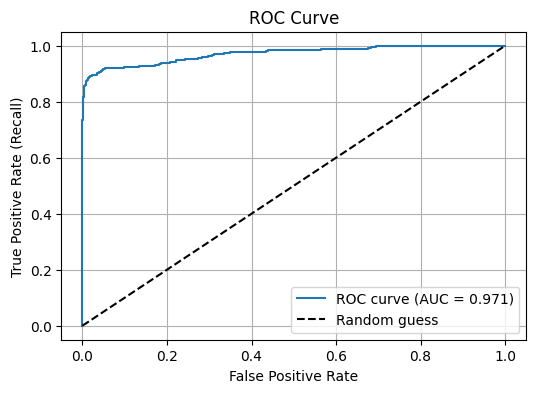

In [179]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.6479, Precision: 0.5033, Recall: 0.9089


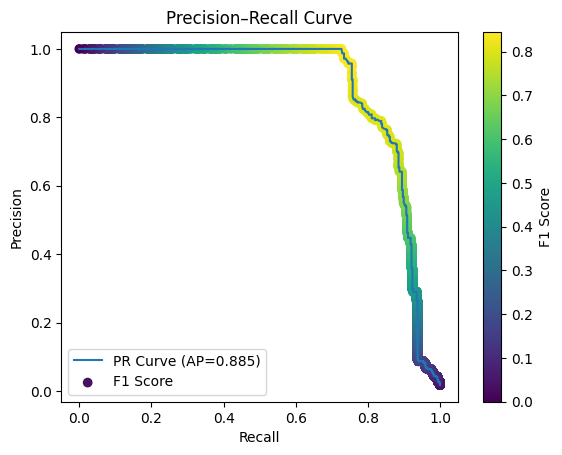

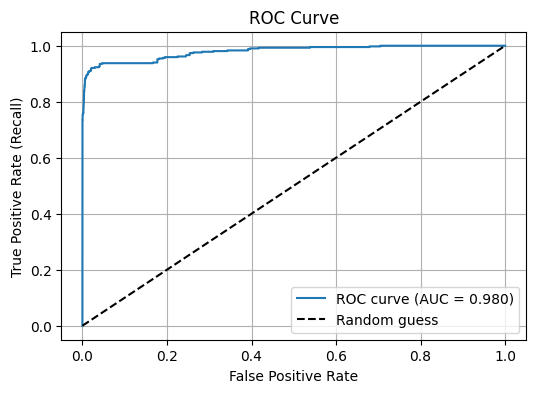

In [180]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [181]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8135, Precision: 0.8845, Recall: 0.7530


In [182]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8197, Precision: 0.8927, Recall: 0.7578


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0067, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0067, Epoch loss: 0.0065, Delta loss: 0.0003
Epoch 3/30
		 Previous Loss 0.0065, Epoch loss: 0.0058, Delta loss: 0.0007
Epoch 4/30
		 Previous Loss 0.0058, Epoch loss: 0.0046, Delta loss: 0.0012
Epoch 5/30
		 Previous Loss 0.0046, Epoch loss: 0.0042, Delta loss: 0.0005
Epoch 6/30
		 Previous Loss 0.0042, Epoch loss: 0.0034, Delta loss: 0.0007
Epoch 7/30
		 Previous Loss 0.0034, Epoch loss: 0.0032, Delta loss: 0.0002
Epoch 8/30
		 Previous Loss 0.0032, Epoch loss: 0.0031, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0031, Epoch loss: 0.0031, Delta loss: 0.0000
Epoch 10/30
		 Previous Loss 0.0031, Epoch loss: 0.0030, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0031, Epoch loss: 0.0030, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0031, Epoch loss: 0.0029, Delta loss: 0.0002
Epoch 13/30
		 Previous Loss 0.0029, Epoch loss: 0.0029, Delta loss: 0.0000
Epoch 14/30
		 Previous Los

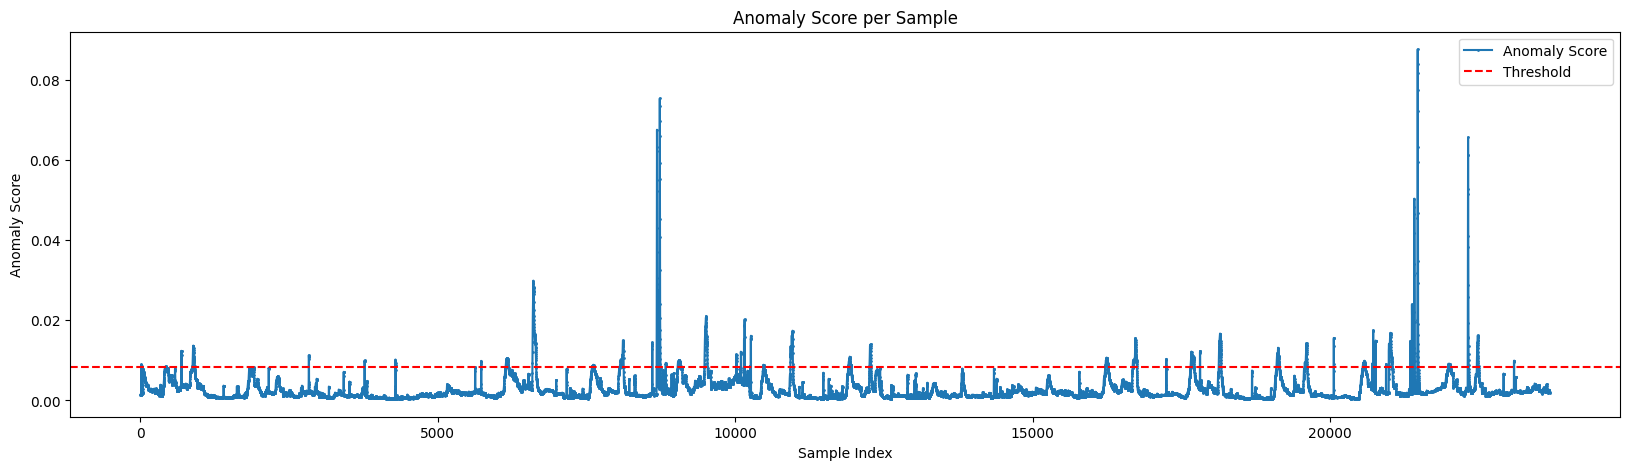

In [183]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.5964, Precision: 0.4907, Recall: 0.7602


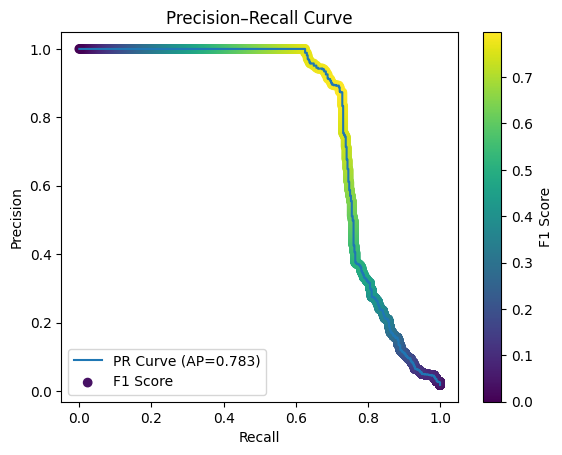

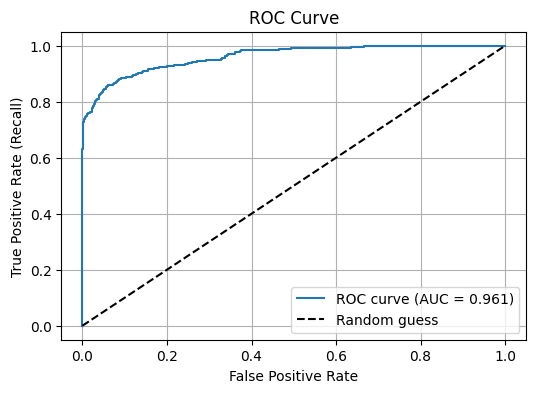

In [184]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.5654, Precision: 0.4444, Recall: 0.7770


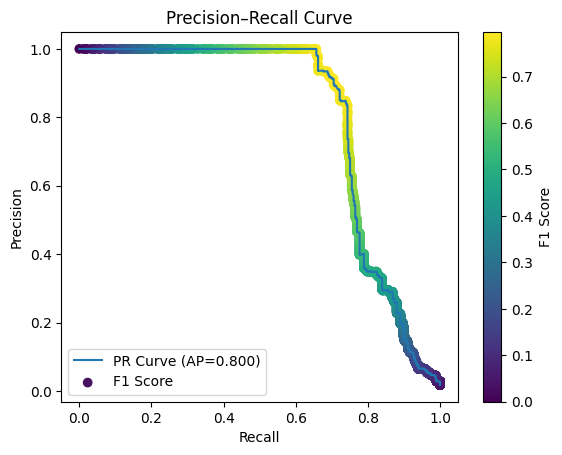

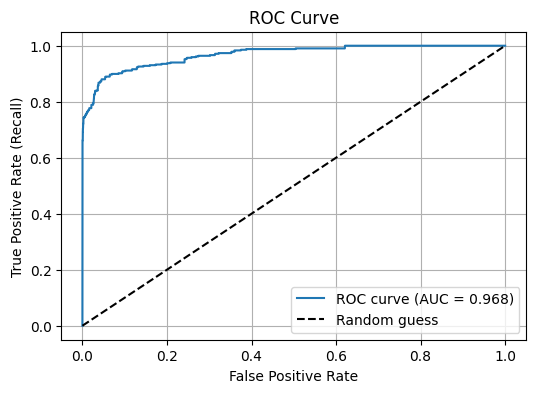

In [185]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [186]:
y_test_full.value_counts()

0
0    23279
1      417
Name: count, dtype: int64

In [187]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.7876, Precision: 0.8563, Recall: 0.7290


In [188]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.7824, Precision: 0.8507, Recall: 0.7242


<span style='color:red; font-size:60px'> Machine-2-8 </span>

In [189]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,8)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0059, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0059, Epoch loss: 0.0032, Delta loss: 0.0026
Epoch 3/30
		 Previous Loss 0.0032, Epoch loss: 0.0029, Delta loss: 0.0003
Epoch 4/30
		 Previous Loss 0.0029, Epoch loss: 0.0029, Delta loss: -0.0000
Epoch 5/30
		 Previous Loss 0.0029, Epoch loss: 0.0029, Delta loss: 0.0000
Epoch 6/30
		 Previous Loss 0.0029, Epoch loss: 0.0029, Delta loss: 0.0000
Epoch 7/30
		 Previous Loss 0.0029, Epoch loss: 0.0029, Delta loss: 0.0000

 max_err: 0.018909893929958344, min_err: 5.424025221145712e-05


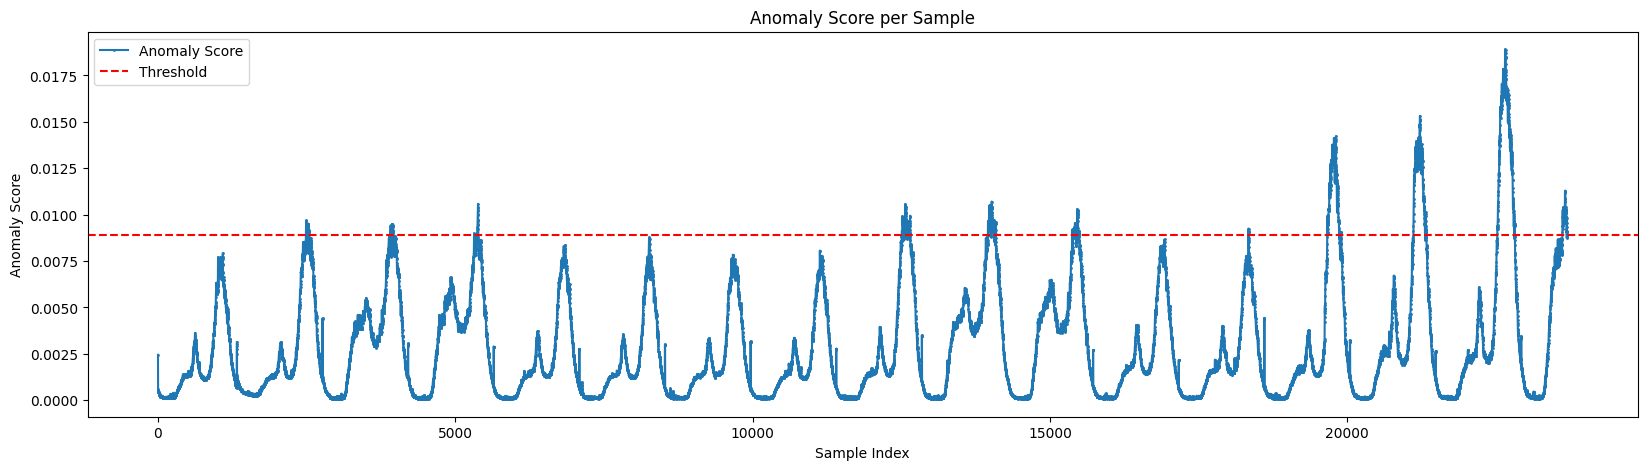

In [190]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.0823, Precision: 0.0429, Recall: 0.9938


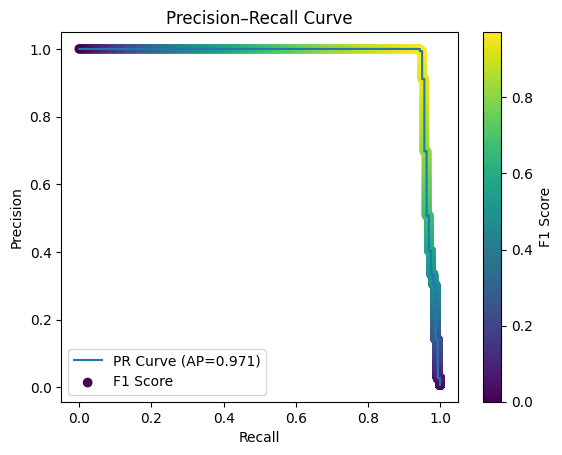

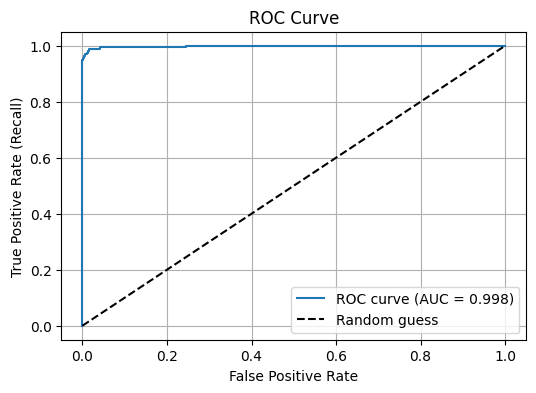

In [191]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.0777, Precision: 0.0404, Recall: 0.9938


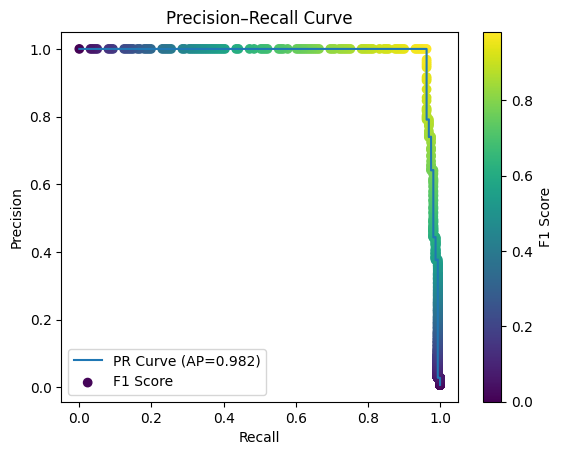

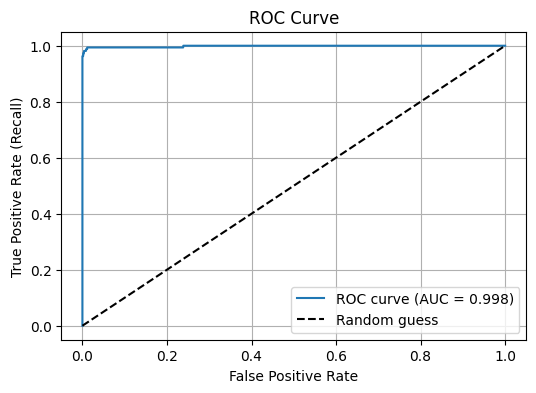

In [192]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [193]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8500, Precision: 1.0000, Recall: 0.7391


In [194]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8500, Precision: 1.0000, Recall: 0.7391


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0043, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0043, Epoch loss: 0.0043, Delta loss: 0.0000
Epoch 3/30
		 Previous Loss 0.0043, Epoch loss: 0.0043, Delta loss: 0.0000
Epoch 4/30
		 Previous Loss 0.0043, Epoch loss: 0.0043, Delta loss: 0.0001
Epoch 5/30
		 Previous Loss 0.0043, Epoch loss: 0.0041, Delta loss: 0.0003
Epoch 6/30
		 Previous Loss 0.0041, Epoch loss: 0.0020, Delta loss: 0.0020
Epoch 7/30
		 Previous Loss 0.0020, Epoch loss: 0.0013, Delta loss: 0.0007
Epoch 8/30
		 Previous Loss 0.0013, Epoch loss: 0.0012, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0012, Epoch loss: 0.0011, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0011, Epoch loss: 0.0010, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0011, Epoch loss: 0.0009, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0009, Epoch loss: 0.0009, Delta loss: 0.0000
Epoch 13/30
		 Previous Loss 0.0009, Epoch loss: 0.0010, Delta loss: -0.0000
Epoch 14/30
		 Previous Lo

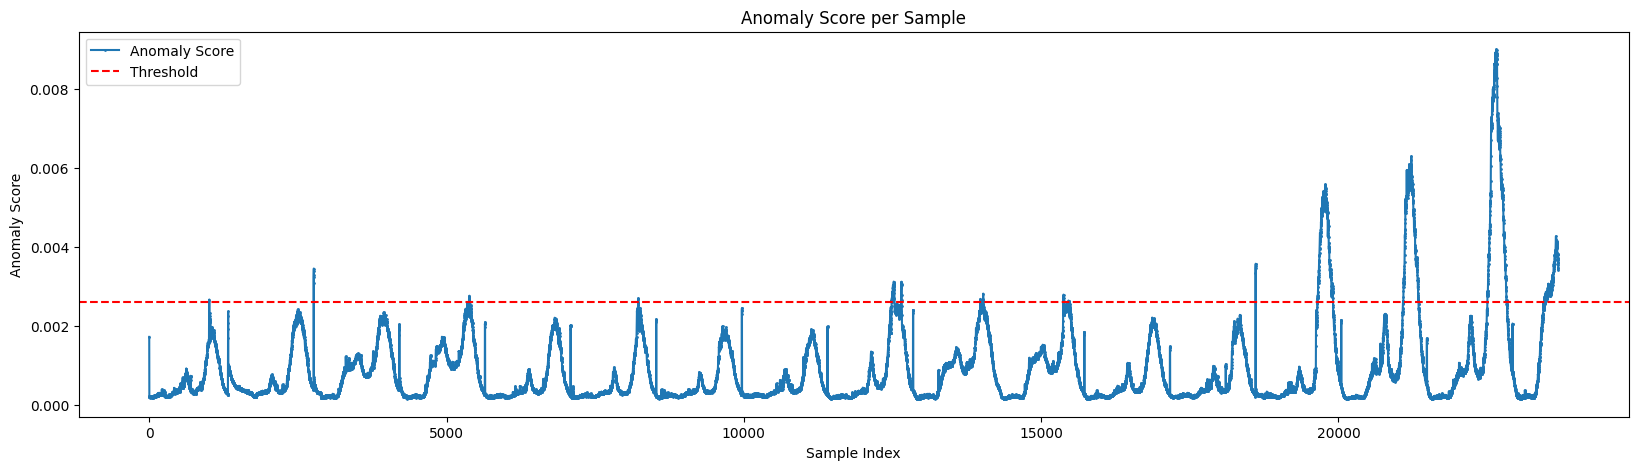

In [195]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.0393, Precision: 0.0201, Recall: 0.9938


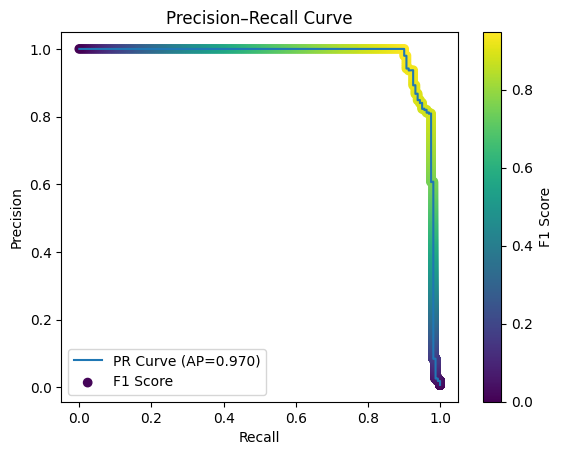

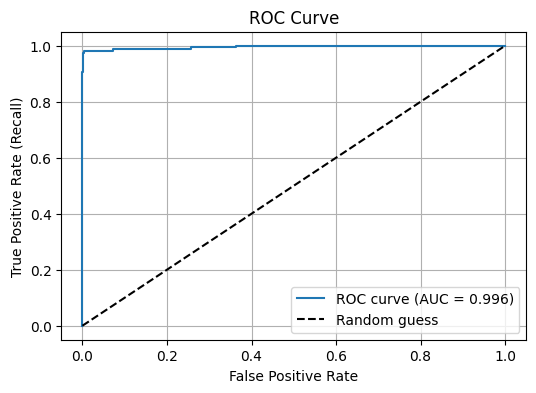

In [196]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.0387, Precision: 0.0198, Recall: 0.9938


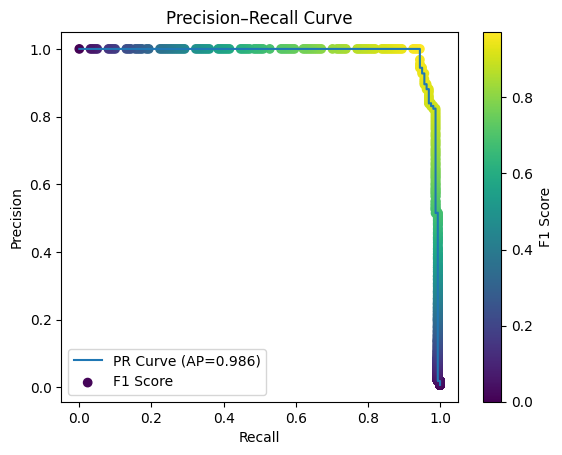

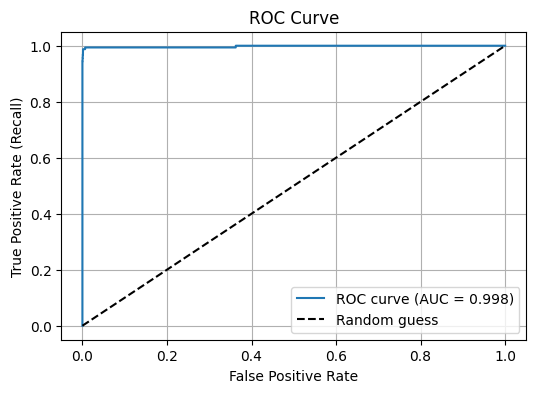

In [197]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [198]:
y_test_full.value_counts()

0
0    23542
1      161
Name: count, dtype: int64

In [199]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8500, Precision: 1.0000, Recall: 0.7391


In [200]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99.5), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.8500, Precision: 1.0000, Recall: 0.7391


<span style='color:red; font-size:60px'> Machine-2-9 </span>

In [201]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(2,9)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0104, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0104, Epoch loss: 0.0100, Delta loss: 0.0003
Epoch 3/30
		 Previous Loss 0.0100, Epoch loss: 0.0099, Delta loss: 0.0001
Epoch 4/30
		 Previous Loss 0.0099, Epoch loss: 0.0016, Delta loss: 0.0083
Epoch 5/30
		 Previous Loss 0.0016, Epoch loss: 0.0017, Delta loss: -0.0001
Epoch 6/30
		 Previous Loss 0.0016, Epoch loss: 0.0017, Delta loss: -0.0001
Epoch 7/30
		 Previous Loss 0.0016, Epoch loss: 0.0017, Delta loss: -0.0000
Epoch 8/30
		 Previous Loss 0.0016, Epoch loss: 0.0015, Delta loss: 0.0001
Epoch 9/30
		 Previous Loss 0.0015, Epoch loss: 0.0014, Delta loss: 0.0001
Epoch 10/30
		 Previous Loss 0.0014, Epoch loss: 0.0012, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0012, Epoch loss: 0.0012, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0012, Epoch loss: 0.0011, Delta loss: 0.0002
Epoch 13/30
		 Previous Loss 0.0011, Epoch loss: 0.0009, Delta loss: 0.0002
Epoch 14/30
		 Previous 

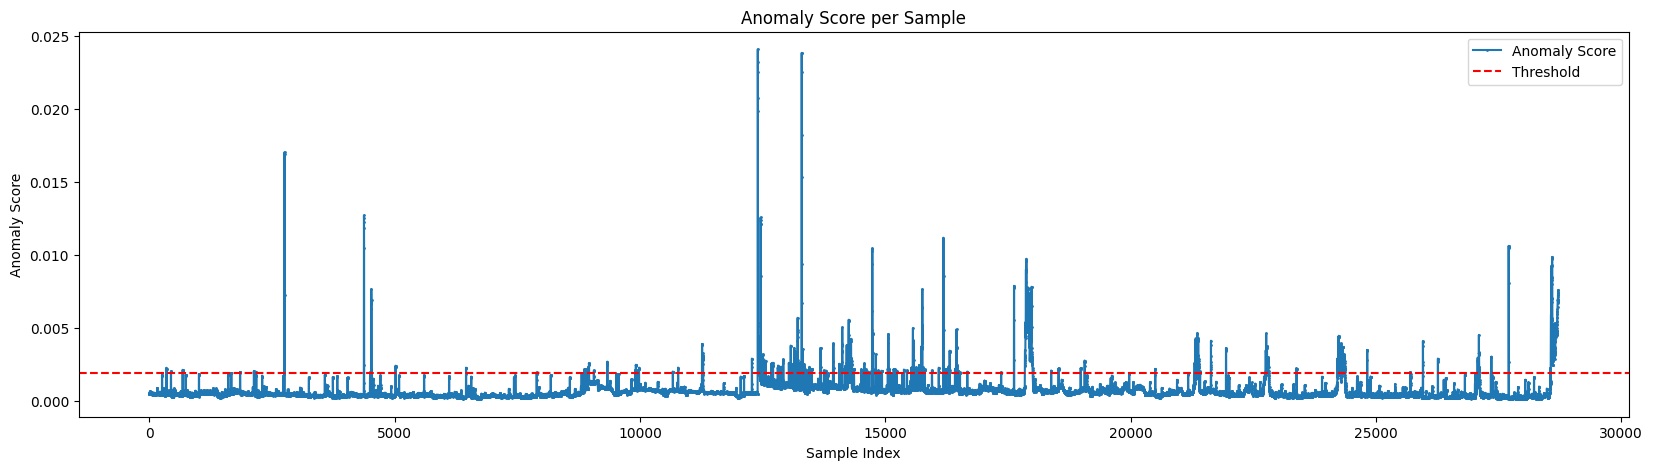

In [202]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

F1: 0.2998, Precision: 0.2175, Recall: 0.4821


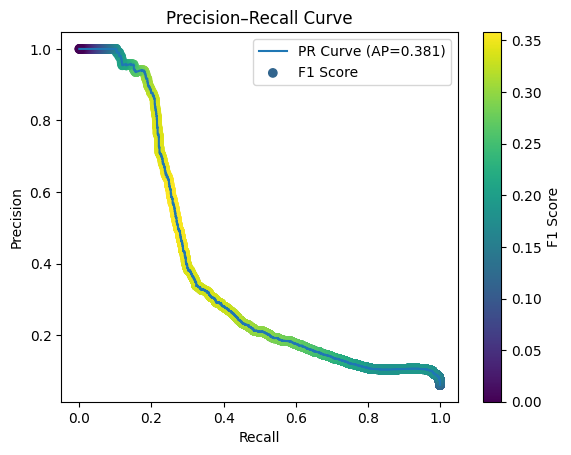

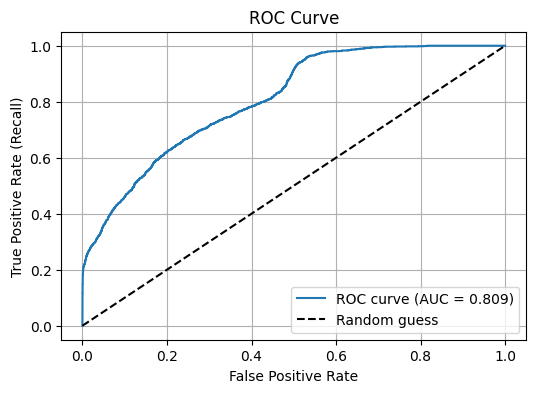

In [203]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.3028, Precision: 0.2064, Recall: 0.5681


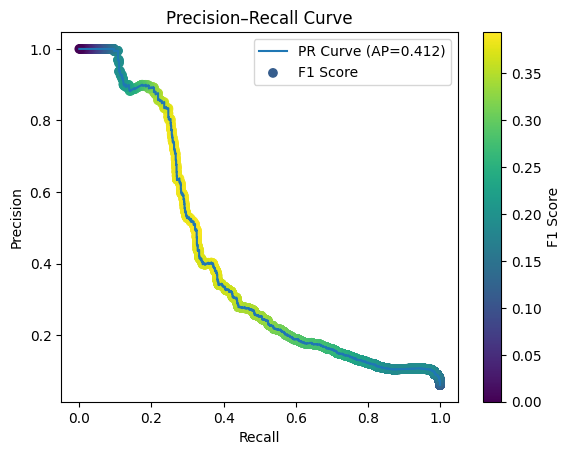

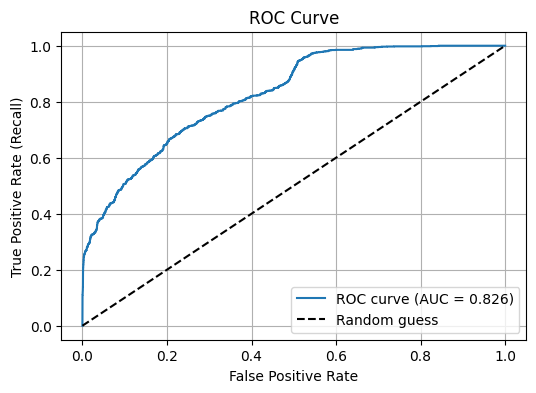

In [204]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [205]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 94), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3324, Precision: 0.3355, Recall: 0.3293


In [206]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 94), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3796, Precision: 0.3833, Recall: 0.3761


Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0176, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0176, Epoch loss: 0.0176, Delta loss: 0.0000
Epoch 3/30
		 Previous Loss 0.0176, Epoch loss: 0.0176, Delta loss: 0.0000
Epoch 4/30
		 Previous Loss 0.0176, Epoch loss: 0.0014, Delta loss: 0.0162
Epoch 5/30
		 Previous Loss 0.0014, Epoch loss: 0.0011, Delta loss: 0.0003
Epoch 6/30
		 Previous Loss 0.0011, Epoch loss: 0.0011, Delta loss: 0.0000
Epoch 7/30
		 Previous Loss 0.0011, Epoch loss: 0.0010, Delta loss: 0.0001
Epoch 8/30
		 Previous Loss 0.0010, Epoch loss: 0.0011, Delta loss: -0.0001

 max_err: 0.024374043568968773, min_err: 0.0001917764893732965


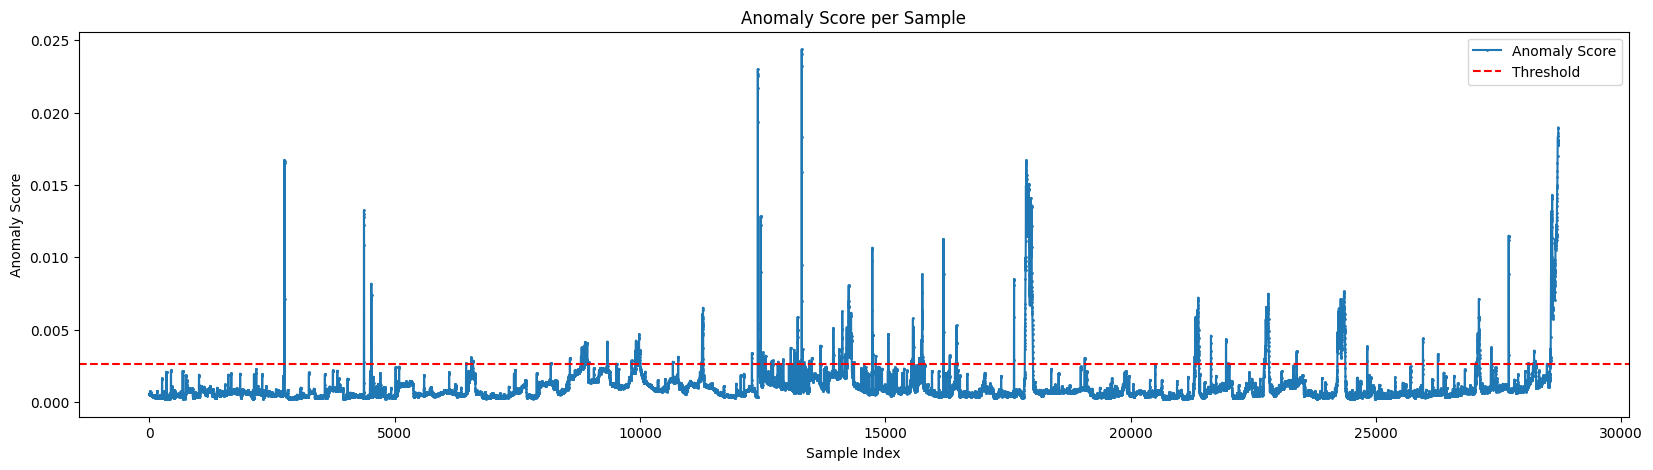

In [207]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

F1: 0.1918, Precision: 0.1129, Recall: 0.6365


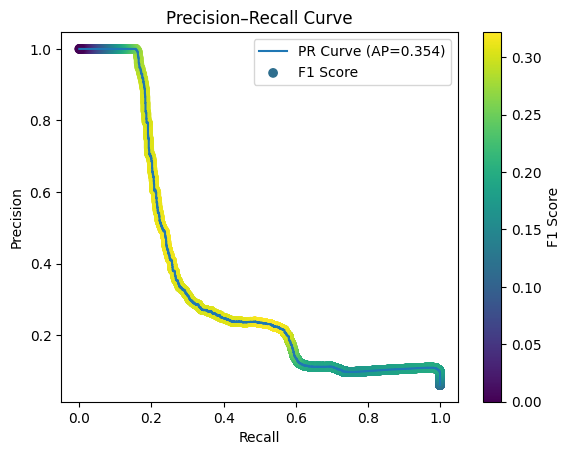

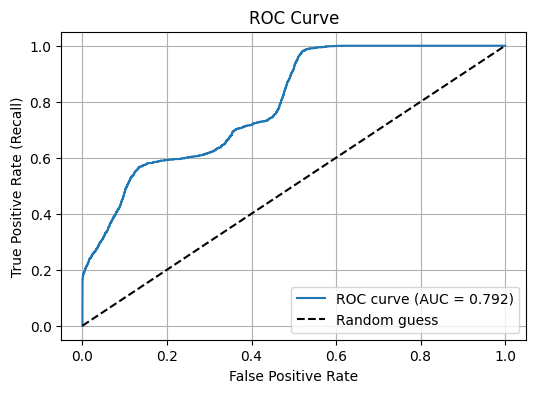

In [208]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

F1: 0.1950, Precision: 0.1140, Recall: 0.6718


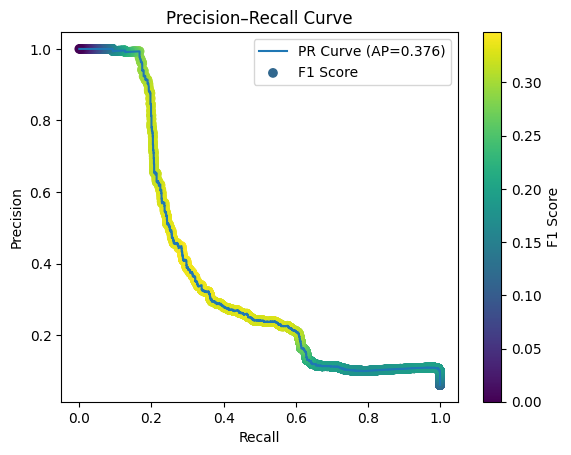

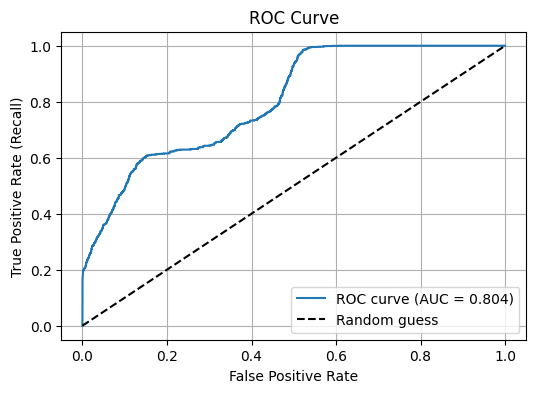

In [209]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [210]:
y_test_full.value_counts()

0
0    26967
1     1755
Name: count, dtype: int64

In [211]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 94), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3059, Precision: 0.3088, Recall: 0.3031


In [212]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 94), tf.int32)
functions.display_metrics(preds, y_test_full)

F1: 0.3335, Precision: 0.3366, Recall: 0.3305


<span style='color:red; font-size:60px'> Machine-3-1 </span>

In [213]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,1)

Epoch 1/30
		 Previous Loss inf, Epoch loss: 0.0052, Delta loss: inf
Epoch 2/30
		 Previous Loss 0.0052, Epoch loss: 0.0050, Delta loss: 0.0001
Epoch 3/30
		 Previous Loss 0.0050, Epoch loss: 0.0048, Delta loss: 0.0002
Epoch 4/30
		 Previous Loss 0.0048, Epoch loss: 0.0045, Delta loss: 0.0003
Epoch 5/30
		 Previous Loss 0.0045, Epoch loss: 0.0040, Delta loss: 0.0005
Epoch 6/30
		 Previous Loss 0.0040, Epoch loss: 0.0035, Delta loss: 0.0005
Epoch 7/30
		 Previous Loss 0.0035, Epoch loss: 0.0032, Delta loss: 0.0003
Epoch 8/30
		 Previous Loss 0.0032, Epoch loss: 0.0030, Delta loss: 0.0002
Epoch 9/30
		 Previous Loss 0.0030, Epoch loss: 0.0026, Delta loss: 0.0005
Epoch 10/30
		 Previous Loss 0.0026, Epoch loss: 0.0024, Delta loss: 0.0001
Epoch 11/30
		 Previous Loss 0.0024, Epoch loss: 0.0023, Delta loss: 0.0001
Epoch 12/30
		 Previous Loss 0.0023, Epoch loss: 0.0021, Delta loss: 0.0002
Epoch 13/30
		 Previous Loss 0.0021, Epoch loss: 0.0019, Delta loss: 0.0002
Epoch 14/30
		 Previous Los

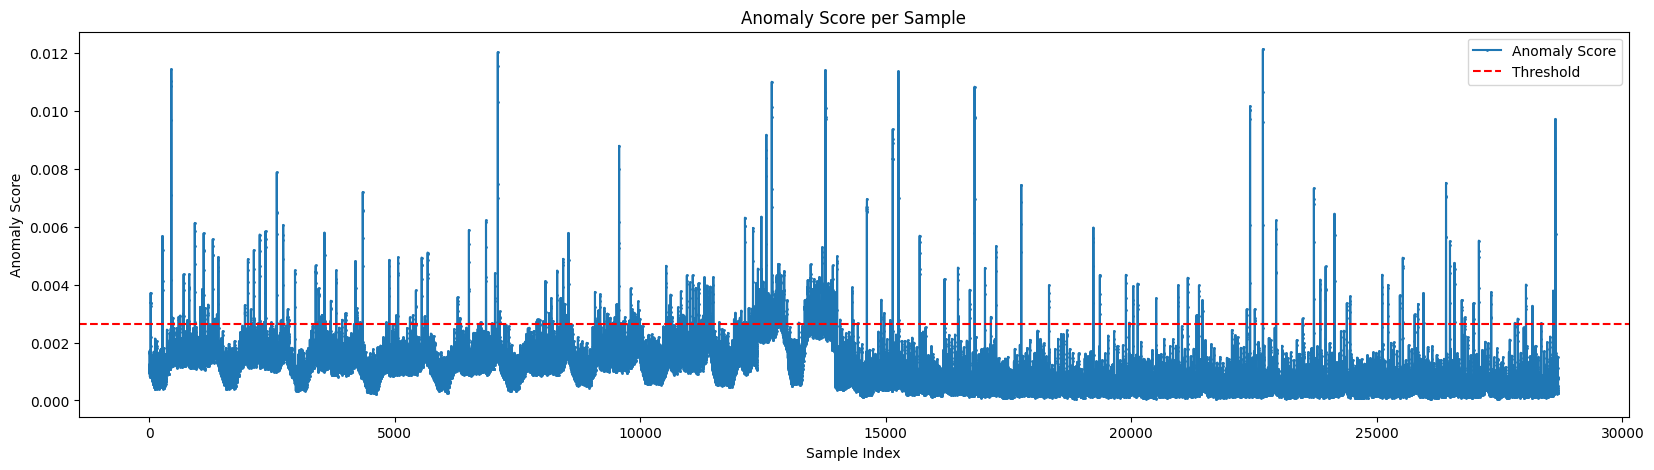

In [214]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-2 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,2)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-3 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,3)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 97.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 97.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 97.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 97.5), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-4 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,4)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 96), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 96), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 96), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 96), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-5 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,5)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-6 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,6)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 96), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 96), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 96), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 96), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-7 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,7)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 98.5), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-8 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,8)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-9 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,9)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-10 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,10)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 95.5), tf.int32)
functions.display_metrics(preds, y_test_full)

<span style='color:red; font-size:60px'> Machine-3-11 </span>

In [ ]:
X_train_full, X_test_full, y_test_full = functions.load_SMD(3,11)

In [ ]:
basic_model = framework(model_weights)
basic_model.build(X_train_full)
basic_model.run_only_ae(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = basic_model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
model = framework(model_weights)
model.build(X_train_full)
model.run(epochs=training_epochs, batch_size=global_batch)

In [ ]:
scores_avg_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=False)

In [ ]:
scores_max_pooled = model.test_using_reconstruction(X_test_full, y_test_full, predict_proba=True, use_maxpooling=True)

In [ ]:
y_test_full.value_counts()

In [ ]:
preds = tf.cast(scores_avg_pooled > tfp.stats.percentile(scores_avg_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)

In [ ]:
preds = tf.cast(scores_max_pooled > tfp.stats.percentile(scores_max_pooled, 99), tf.int32)
functions.display_metrics(preds, y_test_full)